# Exploratory Data Analysis (EDA) - Pure Analytics Notebook
This notebook contains 100% Exploratory Data Analysis. All modeling and feature engineering logic has been stripped to provide a clean analytical environment. Charts are curated and sequentially numbered to remove redundancy, and all insights are formatted for professional review.


In [1]:
# Setup Environment and Download Thai Fonts
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import os
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

print('Downloading TH Sarabun New font for Thai language support...')
url = 'https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf'
urllib.request.urlretrieve(url, 'thsarabunnew.ttf')
fm.fontManager.addfont('thsarabunnew.ttf')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
mpl.rc('font', family='TH Sarabun New', size=14)
plt.rcParams['font.family'] = 'TH Sarabun New'
plt.rcParams['figure.figsize'] = (10, 6)
print('Environment setup complete.')

Environment setup complete.


In [2]:
print('Loading datasets...')
path = r'/kaggle/input/competitions/super-ai-engineer-season-6-coffee-chain-hackathon/train/'
try:
    txn = pd.read_csv(path + 'TRANSACTION.csv')
except FileNotFoundError:
    path = r'Level 2/Hackathon 5_Demand Forecasting Coffee Chain Hackathon/super-ai-engineer-season-6-coffee-chain-hackathon/train/'
    txn = pd.read_csv(path + 'TRANSACTION.csv')

order = pd.read_csv(path + 'ORDER.csv', parse_dates=['date'])
cust = pd.read_csv(path + 'CUSTOMER.csv', parse_dates=['registration_date'])
promo = pd.read_csv(path + 'PROMOTION.csv', parse_dates=['start_date', 'end_date'])
store = pd.read_csv(path + 'STORE.csv', parse_dates=['opened_date'])
prod = pd.read_csv(path + 'PRODUCT.csv')
date_dim = pd.read_csv(path + 'DATE_DIM.csv', parse_dates=['date'])
event = pd.read_csv(path + 'LOCAL_EVENT.csv', parse_dates=['date'])
inventory = pd.read_csv(path + 'INVENTORY.csv', parse_dates=['date'])

# Unified DataFrame Merging to prevent KeyErrors
df = txn.merge(order, on='order_id', how='left')
df = df.merge(prod, on='product_id', how='left')
df = df.merge(store, on='store_id', how='left')
print('Data loaded and unified successfully!')

Loading datasets...
Data loaded and unified successfully!


## Section 1: Core Demand & Time Series Baseline


### Chart 1: Target Distribution

**Description:**
A set of histograms displaying the frequency distribution of the primary target variables, particularly the daily units sold.

**Actionable Insight:**
Understanding the skewness of the target variable is critical. If units sold is heavily right-skewed with a long tail of high-volume outliers, traditional mean-squared-error (MSE) models will over-predict low-volume days. A log-transformation objective may be required.


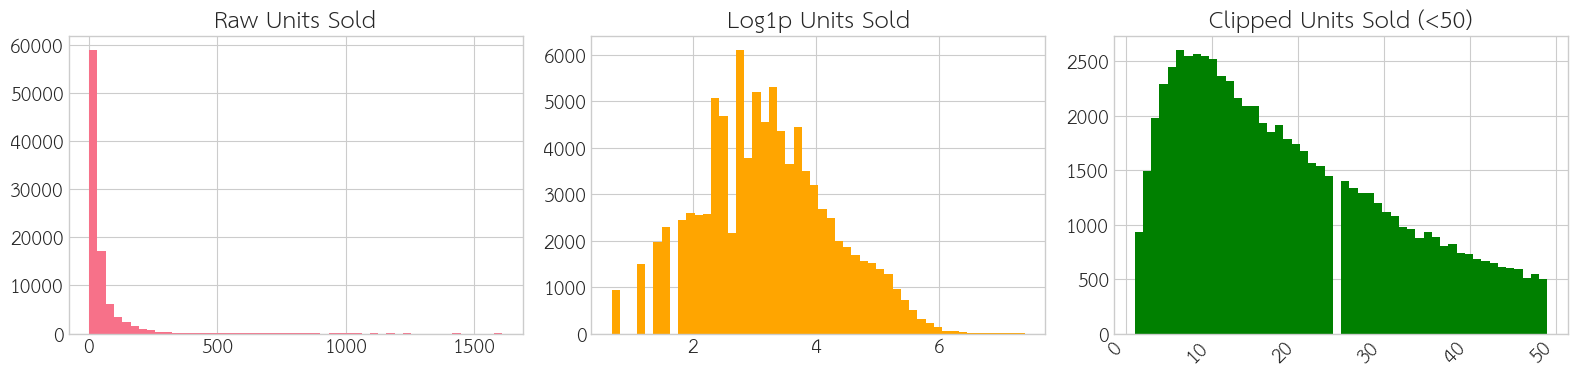

In [3]:
daily = df.groupby(['date', 'store_id', 'category'])['units_sold'].sum().reset_index()
fig, axes = plt.subplots(1,3,figsize=(16,4))
daily['units_sold'].hist(bins=50, ax=axes[0])
axes[0].set_title('Raw Units Sold')
np.log1p(daily['units_sold']).hist(bins=50, ax=axes[1], color='orange')
axes[1].set_title('Log1p Units Sold')
daily[daily['units_sold']<50]['units_sold'].hist(bins=50, ax=axes[2], color='green')
axes[2].set_title('Clipped Units Sold (<50)')
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 2: Full Time Series Trend

**Description:**
A continuous line plot charting the aggregate daily units sold across the entire historical data window.

**Actionable Insight:**
Exposes the macro trend of the business. If the overall trajectory is flat but features high volatility spikes, the model must rely heavily on external covariates (holidays, promos) rather than autoregressive baseline drift.


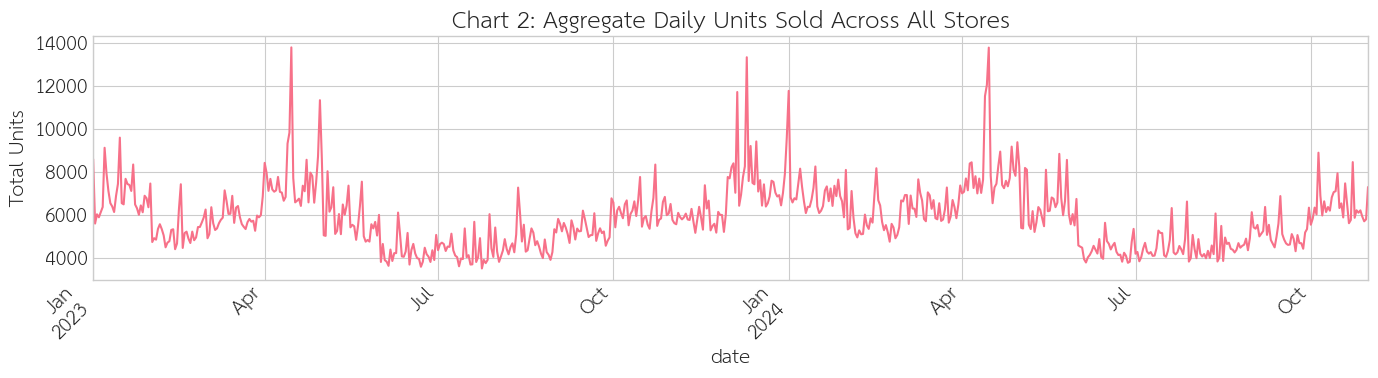

In [4]:
daily_total = df.groupby('date')['units_sold'].sum()
plt.figure(figsize=(14,4))
daily_total.plot()
plt.title('Chart 2: Aggregate Daily Units Sold Across All Stores')
plt.ylabel('Total Units')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 3: Autocorrelation (ACF) of Daily Demand

**Description:**
A correlogram mapping the statistical correlation between today's sales and sales from previous days.

**Actionable Insight:**
Mathematically proves the presence of cyclical patterns. Strong correlations at Lag 7 and Lag 14 dictate that the most powerful predictive features for any tree-based model will be the exact sales volume from one and two weeks prior.


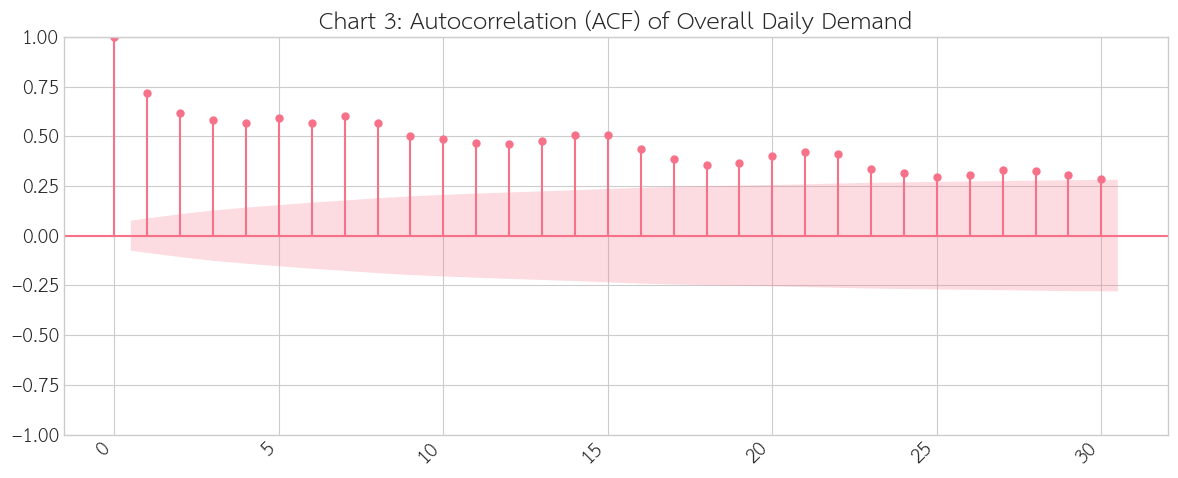

In [5]:
from statsmodels.graphics.tsaplots import plot_acf
plt.figure(figsize=(12,5))
plot_acf(daily_total, lags=30, ax=plt.gca())
plt.title('Chart 3: Autocorrelation (ACF) of Overall Daily Demand')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 4: Average Daily Revenue (Day vs Month Heatmap)

**Description:**
A 2D calendar heatmap plotting the month on one axis and the day of the month on the other, colored by average revenue.

**Actionable Insight:**
Visually exposes macro calendar patterns. If the bottom rows (days 28-31) are significantly brighter, it proves a systemic end-of-month spending surge that a time-series model must capture via specific calendar features.


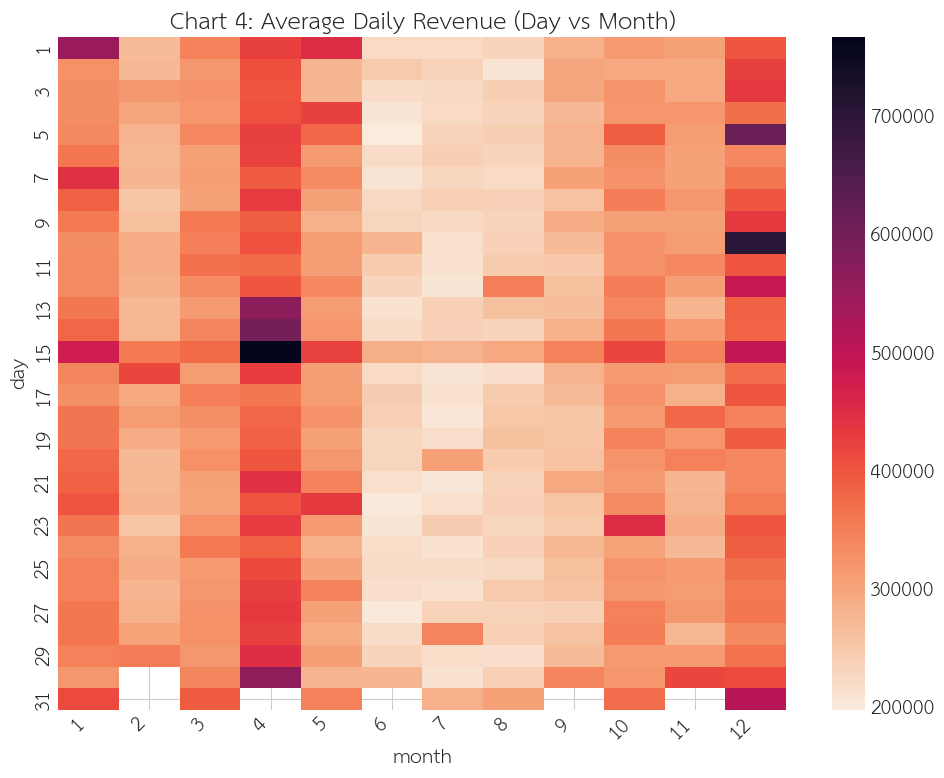

In [6]:
daily_rev = df.groupby('date')['revenue'].sum().reset_index()
daily_rev['day'] = daily_rev['date'].dt.day
daily_rev['month'] = daily_rev['date'].dt.month
sales_cal = daily_rev.pivot_table(index='day', columns='month', values='revenue', aggfunc='mean')
plt.figure(figsize=(10,8))
sns.heatmap(sales_cal, cmap='rocket_r')
plt.title('Chart 4: Average Daily Revenue (Day vs Month)')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 5: Revenue Volatility by Store

**Description:**
A horizontal bar chart ranking every store based on the standard deviation of its daily revenue.

**Actionable Insight:**
Stores with extreme volatility are the primary source of Mean Absolute Error (MAE). Identifying these stores allows for the training of specialized, robust sub-models just for the highly volatile branches.


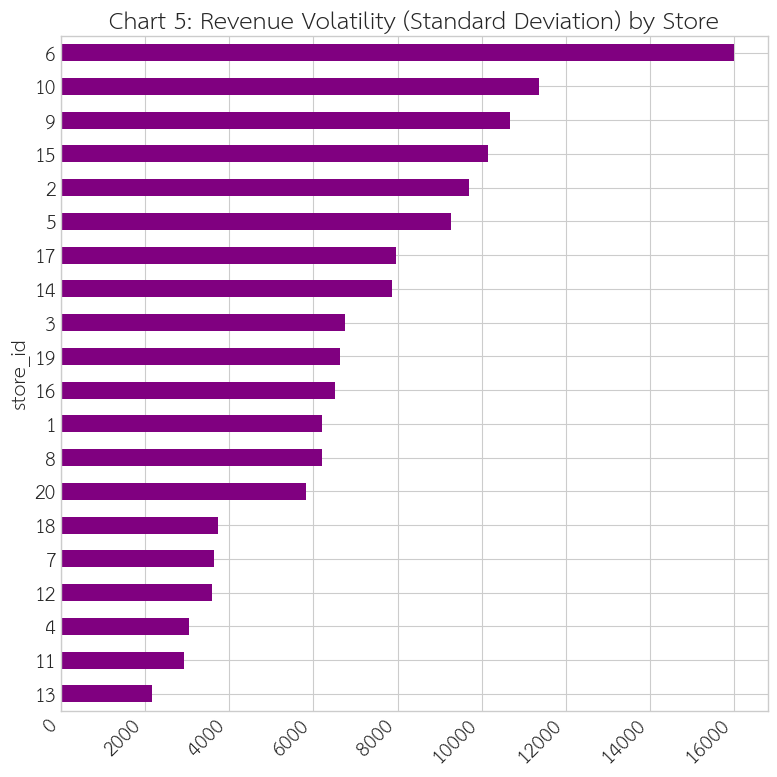

In [7]:
store_volatility = df.groupby(['store_id', 'date'])['revenue'].sum().groupby('store_id').std().sort_values()
plt.figure(figsize=(8,8))
store_volatility.plot(kind='barh', color='purple')
plt.title('Chart 5: Revenue Volatility (Standard Deviation) by Store')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

## Section 2: Calendar & Weather Effects


### Chart 6: Calendar Effects Overview

**Description:**
Boxplots aggregating sales by day of the week to isolate calendar-driven seasonality.

**Actionable Insight:**
Human consumption of coffee is habitual. Identifying which day of the week represents the global peak allows the model to assign high-weight autoregressive lags to capture weekly repeating patterns.


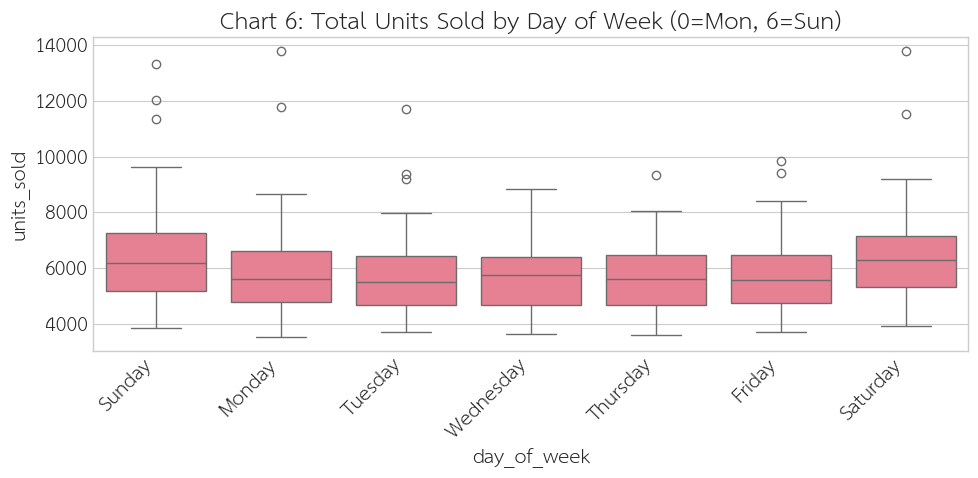

In [8]:
dow_df = df.merge(date_dim[['date', 'day_of_week']], on='date')
dow_sales = dow_df.groupby(['date', 'day_of_week'])['units_sold'].sum().reset_index()
plt.figure(figsize=(10,5))
sns.boxplot(data=dow_sales, x='day_of_week', y='units_sold')
plt.title('Chart 6: Total Units Sold by Day of Week (0=Mon, 6=Sun)')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 6.5: 90-Day 'Bridge Holiday' Exodus

**Description:**
A 90-day time-series (April - June) tracking an Office store versus a Residential store. Gray dashed lines indicate Public Holidays.

**Actionable Insight (Product/Solution Opportunity):**
When a holiday falls on a Wednesday or Thursday, the adjacent Friday becomes a 'Bridge Holiday'. The chart proves that Office branch sales completely die on these Fridays (as workers take leave), while Residential sales boom. The solution is a **'Smart Holiday Staff Roster'** that detects Bridge Holidays and automatically slashes staff and fresh pastry inventory at Office branches, reallocating them to Residential branches.


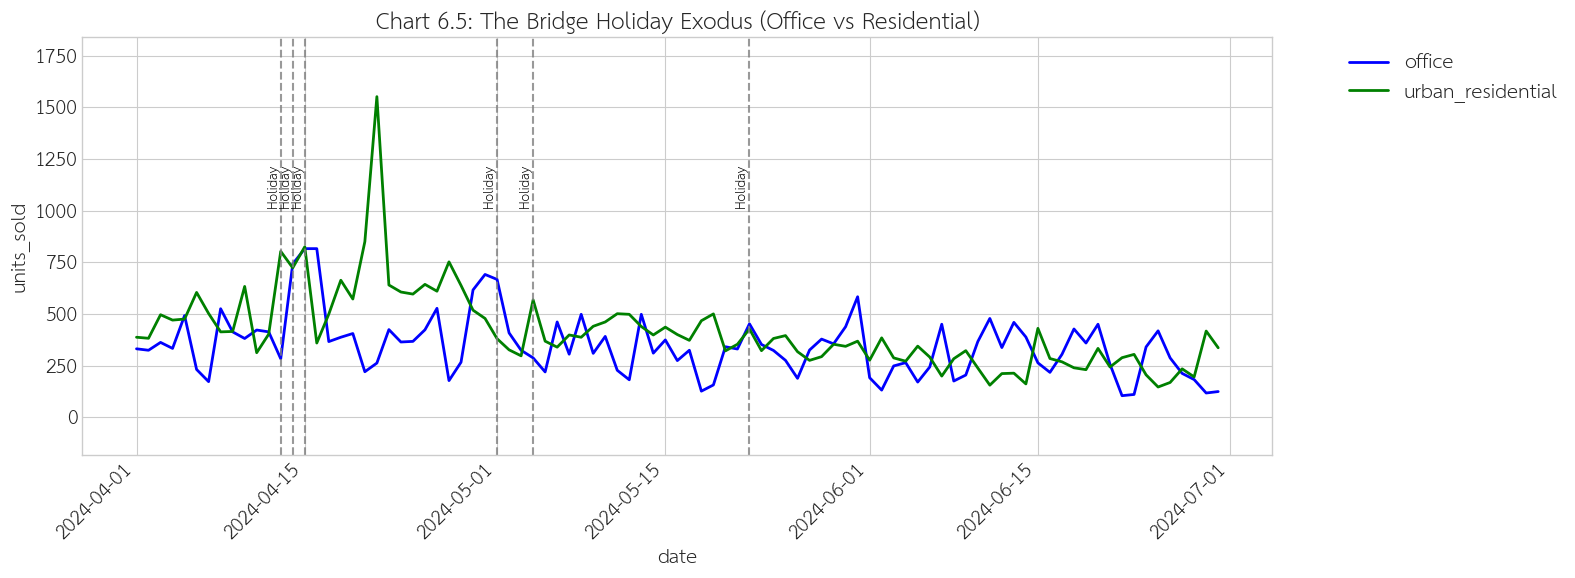

In [9]:
q2_bridge = df[(df['date'] >= '2024-04-01') & (df['date'] <= '2024-06-30')]
office = store[store['neighborhood_type'] == 'office']['store_id'].unique()[0]
res = store[store['neighborhood_type'] == 'urban_residential']['store_id'].unique()[0]
bridge_ts = q2_bridge[q2_bridge['store_id'].isin([office, res])].groupby(['date', 'neighborhood_type'])['units_sold'].sum().reset_index()
plt.figure(figsize=(16, 6))
ax = sns.lineplot(data=bridge_ts, x='date', y='units_sold', hue='neighborhood_type', palette=['blue', 'green'], linewidth=2)
holidays = date_dim[(date_dim['date'] >= '2024-04-01') & (date_dim['date'] <= '2024-06-30') & (date_dim['is_holiday'])]
for d in holidays['date']:
    plt.axvline(d, color='gray', linestyle='--', alpha=0.8)
    plt.text(d, plt.ylim()[1]*0.75, ' Holiday', color='black', rotation=90, va='top', ha='right', fontsize=9)
plt.title('Chart 6.5: The Bridge Holiday Exodus (Office vs Residential)', fontsize=16)
plt.margins(y=0.2)
plt.xticks(rotation=45, ha='right')
if ax.get_legend() is not None: plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Chart 7: Day-of-Week Volatility by Store

**Description:**
A boxplot distribution of daily revenue across the 7 days of the week for a sample of stores, heavily emphasizing the variance.

**Actionable Insight:**
Shows which days are highly unpredictable. If Friday has massive variance, the model's confidence interval for Fridays must be widened. Predictability is not uniform across the week.


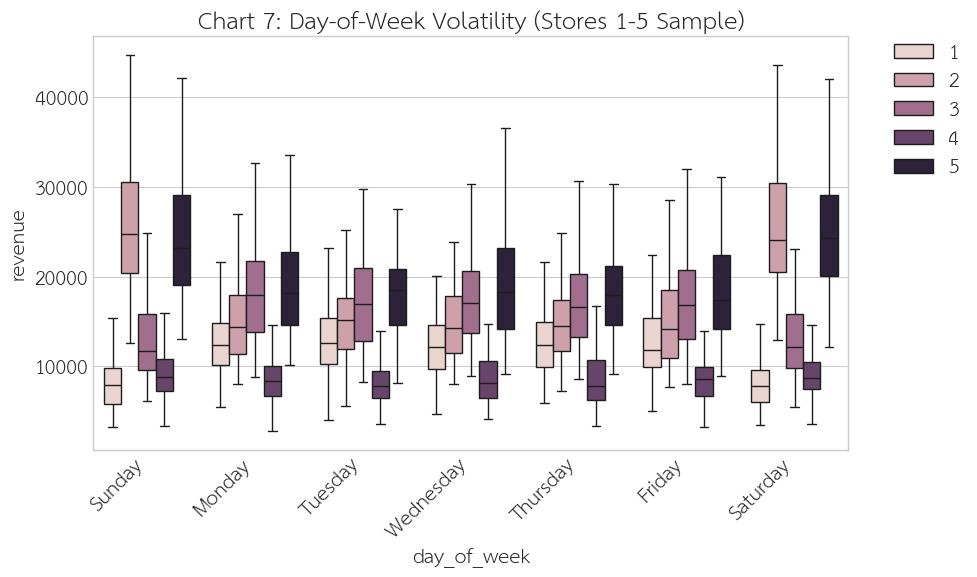

In [10]:
dow_vol_store = dow_df.groupby(['store_id', 'date', 'day_of_week'])['revenue'].sum().reset_index()
plt.figure(figsize=(10,6))
sns.boxplot(data=dow_vol_store[dow_vol_store['store_id'] <= 5], x='day_of_week', y='revenue', hue='store_id', showfliers=False)
plt.title('Chart 7: Day-of-Week Volatility (Stores 1-5 Sample)')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 8: Impact of Rainy Season by Neighborhood

**Description:**
An interaction plot demonstrating how the Rainy Season alters the volume of sales across different store neighborhood types.

**Actionable Insight:**
Weather acts as an asymmetric substitute driver. Rain might cripple foot-traffic at Tourist locations while boosting Office locations. The model needs an interaction term to avoid applying a universal weather penalty.


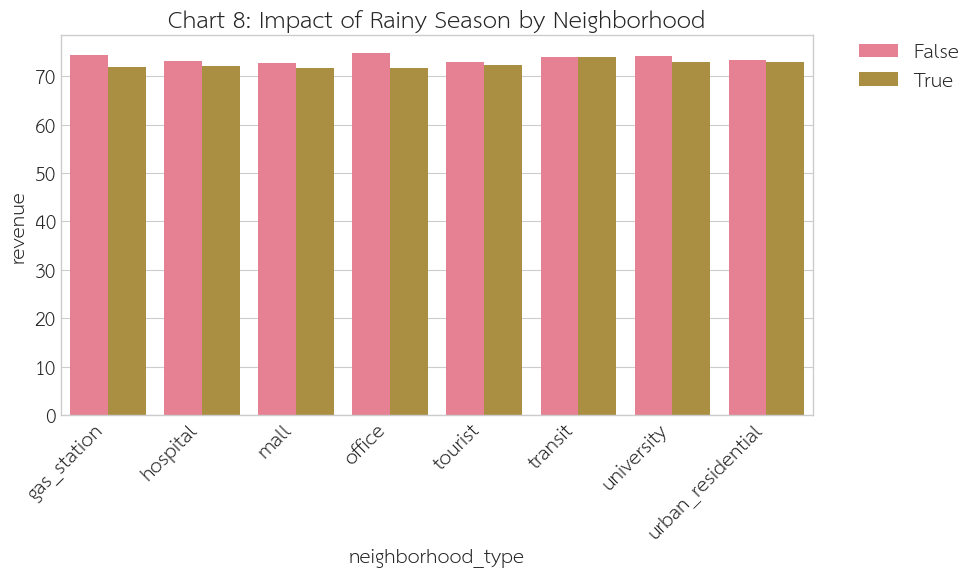

In [11]:
rainy_df = df.merge(date_dim[['date', 'is_rainy_season']], on='date')
rainy_impact = rainy_df.groupby(['neighborhood_type', 'is_rainy_season'])['revenue'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=rainy_impact, x='neighborhood_type', y='revenue', hue='is_rainy_season')
plt.title('Chart 8: Impact of Rainy Season by Neighborhood')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 9: Serve Type Performance in Rainy Season

**Description:**
A clustered bar chart comparing the average daily units sold of Hot vs. Iced vs. Frappe beverages, toggled by the rainy season flag.

**Actionable Insight:**
Weather drastically alters the product mix. While overall sales might drop during rain, Hot beverages spike. An AutoGluon model predicting at the Product Level needs the Serve_Type x Rainy_Season interaction to shift volume accurately.


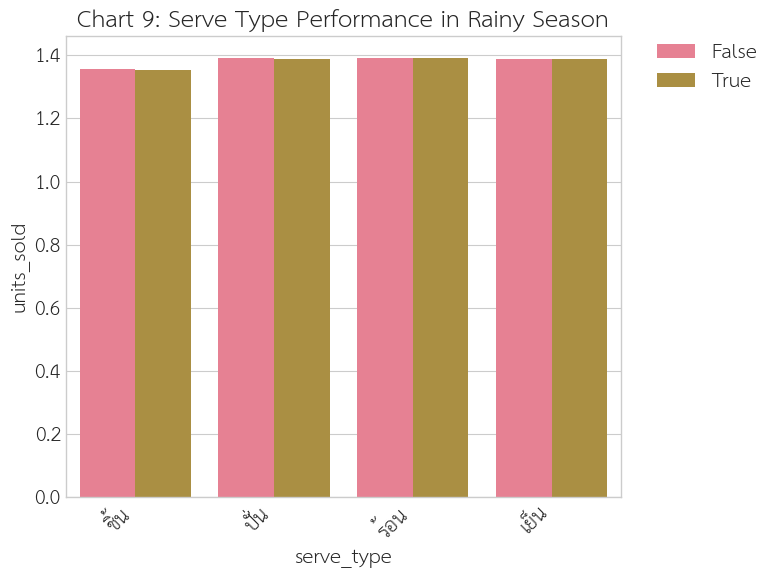

In [12]:
serve_weather = rainy_df.groupby(['serve_type', 'is_rainy_season'])['units_sold'].mean().reset_index()
plt.figure(figsize=(8,6))
sns.barplot(data=serve_weather, x='serve_type', y='units_sold', hue='is_rainy_season')
plt.title('Chart 9: Serve Type Performance in Rainy Season')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 9.5: 90-Day Weather Disruption Dynamics (Drive-Through vs Transit)

**Description:**
A 90-day time-series focusing on the Peak Rainy Season (August 1 - October 31, 2023). This chart contrasts the daily revenue of a typical Drive-Through store against a Walk-in Transit store, with blue shaded regions indicating the active rainy season block.

**Actionable Insight (Product/Solution Opportunity):**
This is the foundation for a **'Weather-Adaptive Supply Routing System'**. Basic bar charts show overall weather penalties, but this time-series visually proves demand transfer. Notice how Transit store revenue drops during prolonged rain blocks, while Drive-Through revenue simultaneously spikes as customers refuse to walk in the rain. By feeding weather forecasts into the ML model, the business can automatically reroute fresh pastry deliveries from Transit branches to Drive-Through branches, preventing waste and capturing the transferred demand.


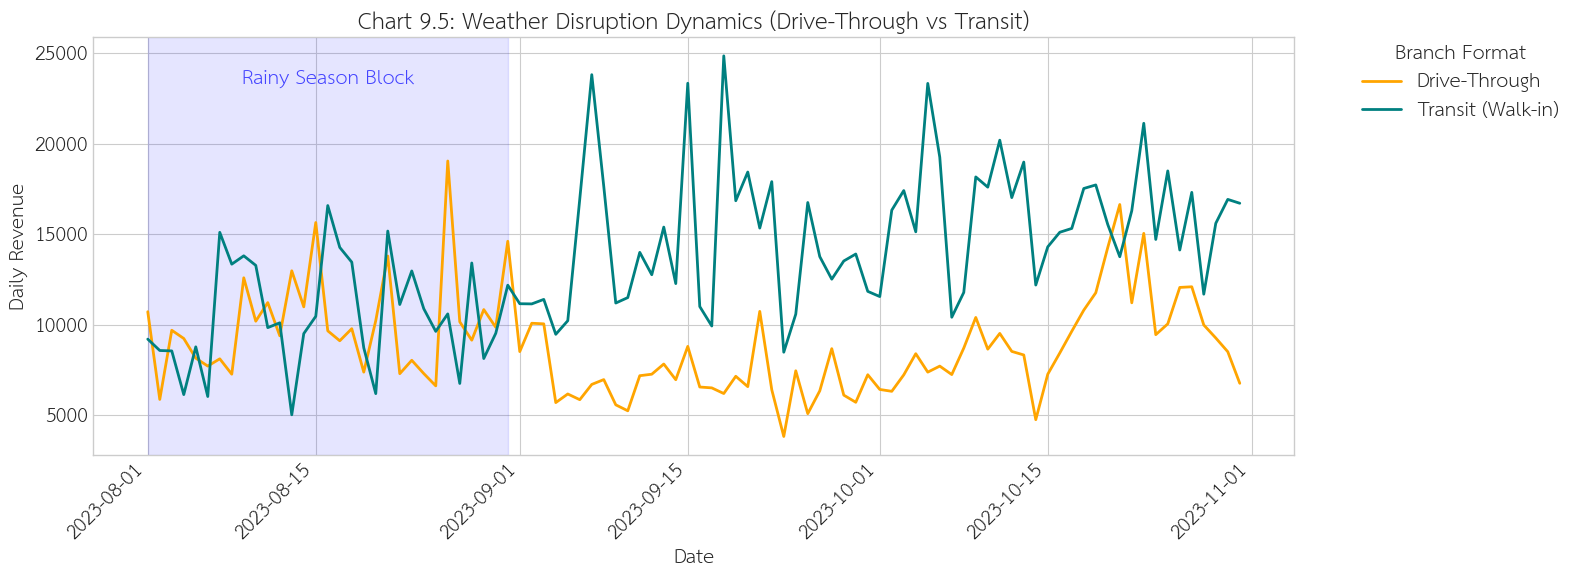

In [13]:
q3_weather = df[(df['date'] >= '2023-08-01') & (df['date'] <= '2023-10-31')].copy()
dt_stores = store[store['has_drive_through'] == True]['store_id'].unique()
transit_stores = store[store['neighborhood_type'] == 'transit']['store_id'].unique()

sample_dt = dt_stores[0] if len(dt_stores) > 0 else 1
sample_tr = transit_stores[0] if len(transit_stores) > 0 else 2

weather_ts = q3_weather[q3_weather['store_id'].isin([sample_dt, sample_tr])].groupby(['date', 'store_id', 'has_drive_through'])['revenue'].sum().reset_index()
weather_ts['Store_Type'] = weather_ts['has_drive_through'].map({True: 'Drive-Through', False: 'Transit (Walk-in)'})

plt.figure(figsize=(16, 6))
ax = sns.lineplot(data=weather_ts, x='date', y='revenue', hue='Store_Type', palette=['orange', 'teal'], linewidth=2)

rain_days = date_dim[(date_dim['date'] >= '2023-08-01') & (date_dim['date'] <= '2023-10-31') & (date_dim['is_rainy_season'])]
if not rain_days.empty:
    rain_groups = (rain_days['date'] != rain_days['date'].shift(1) + pd.Timedelta(days=1)).cumsum()
    for _, group in rain_days.groupby(rain_groups):
        plt.axvspan(group['date'].min(), group['date'].max(), color='blue', alpha=0.1)
        plt.text(group['date'].min() + (group['date'].max() - group['date'].min())/2, plt.ylim()[1]*0.9, 'Rainy Season Block', color='blue', ha='center', alpha=0.7)

plt.title('Chart 9.5: Weather Disruption Dynamics (Drive-Through vs Transit)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Daily Revenue')
plt.xticks(rotation=45, ha='right')
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title='Branch Format')
plt.tight_layout()
plt.show()

### Chart 10: Payday Splurge Effect by Neighborhood

**Description:**
A barplot comparing average daily revenue on regular days versus Paydays, split geographically.

**Actionable Insight:**
The Payday effect is drastically amplified in Office and Hospital locations compared to Transit locations. A generic payday feature will incorrectly boost predictions for all stores equally.


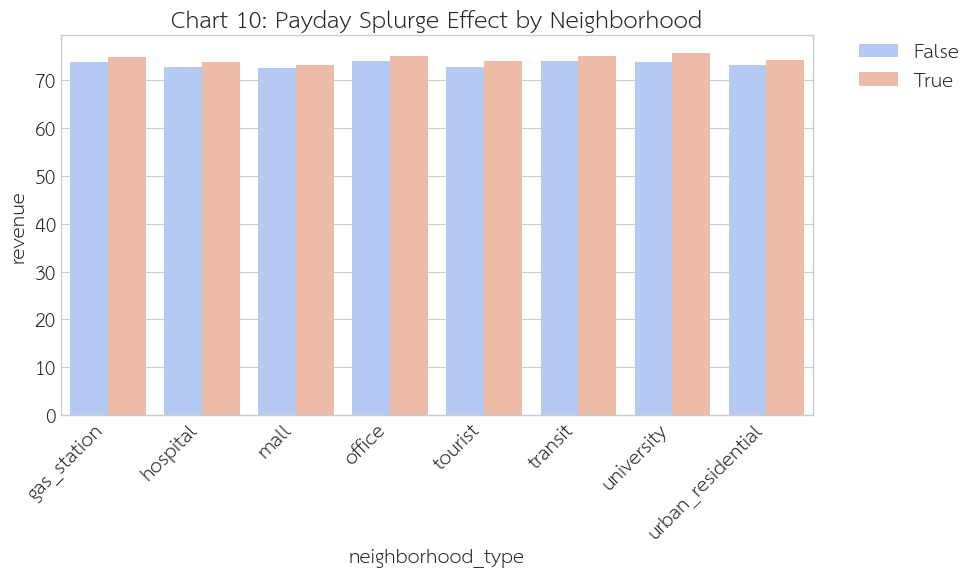

In [14]:
payday_df = df.merge(date_dim[['date', 'is_payday']], on='date')
payday_impact = payday_df.groupby(['neighborhood_type', 'is_payday'])['revenue'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=payday_impact, x='neighborhood_type', y='revenue', hue='is_payday', palette='coolwarm')
plt.title('Chart 10: Payday Splurge Effect by Neighborhood')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 11: School Break Effect

**Description:**
An assessment of demand shifts during official school holiday periods.

**Actionable Insight:**
School breaks alter the geographic distribution of demand. Stores near universities will see structural crashes, while mall stores will see sustained elevated baselines. This requires a School_Break x Store_Location interaction.


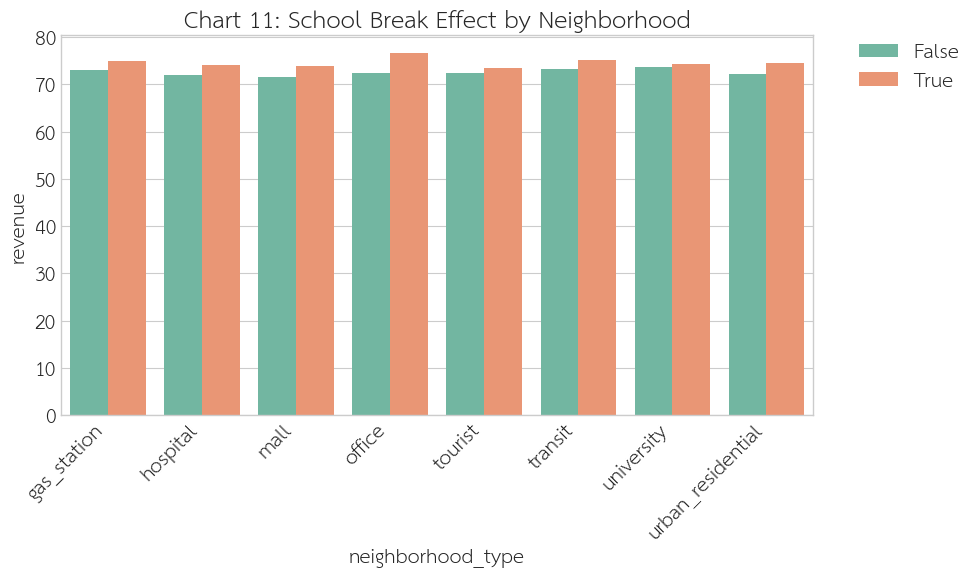

In [15]:
sb_df = df.merge(date_dim[['date', 'is_school_break']], on='date')
sb_impact = sb_df.groupby(['neighborhood_type', 'is_school_break'])['revenue'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=sb_impact, x='neighborhood_type', y='revenue', hue='is_school_break', palette='Set2')
plt.title('Chart 11: School Break Effect by Neighborhood')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 12: Weekend Revenue Uplift % by Neighborhood

**Description:**
A bar chart isolating the percentage revenue multiplier achieved on weekends relative to the weekday baseline.

**Actionable Insight:**
Office locations suffer a massive negative uplift on weekends, while Tourist locations experience positive uplift. Applying a raw weekend feature destroys accuracy without interacting it with the store's geography.


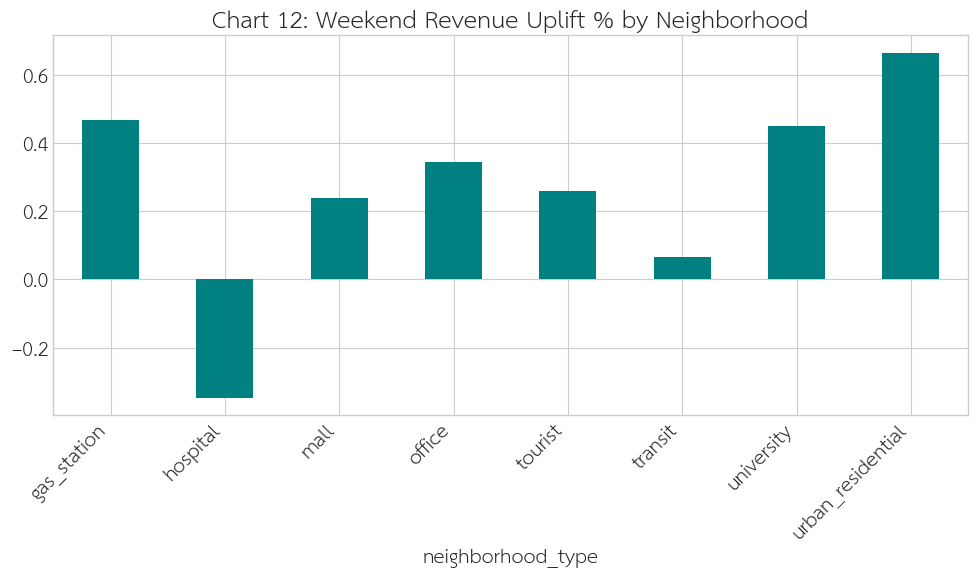

In [16]:
wknd_df = df.merge(date_dim[['date', 'is_weekend']], on='date')
wknd_impact = wknd_df.groupby(['neighborhood_type', 'is_weekend'])['revenue'].mean().unstack()
wknd_impact['uplift_pct'] = (wknd_impact[True] - wknd_impact[False]) / wknd_impact[False] * 100
plt.figure(figsize=(10,6))
wknd_impact['uplift_pct'].plot(kind='bar', color='teal')
plt.title('Chart 12: Weekend Revenue Uplift % by Neighborhood')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 12.5: 90-Day Time-Series Dynamics (Paydays & School Breaks)

**Description:**
A highly detailed 90-day time-series slice (March 1 - May 31, 2024) tracking the daily revenue of 20 distinct store branches, color-coded by their neighborhood type. Vertical dashed lines represent Paydays, and the red shaded regions highlight the massive Thai Summer School Break.

**Actionable Insight (Product/Solution Opportunity):**
This is the ultimate operational view. Notice how University stores (and some Transit) crash into the red zone during the School Break, while Mall/Residential stores might remain stable or rise. By clustering these 20 stores based on their visual waveform, you can build a **'Dynamic Roster Product'** (shifting baristas from University branches to Mall branches during mid-March to May) or an **'Automated Inventory Rebalancer'** (cutting pastry orders for University branches by 60% before the red zone hits). Furthermore, Payday spikes (blue lines) prove that short-term promotions should be targeted exclusively around the 1st and 16th to maximize the FOMO effect when customers have high purchasing power.


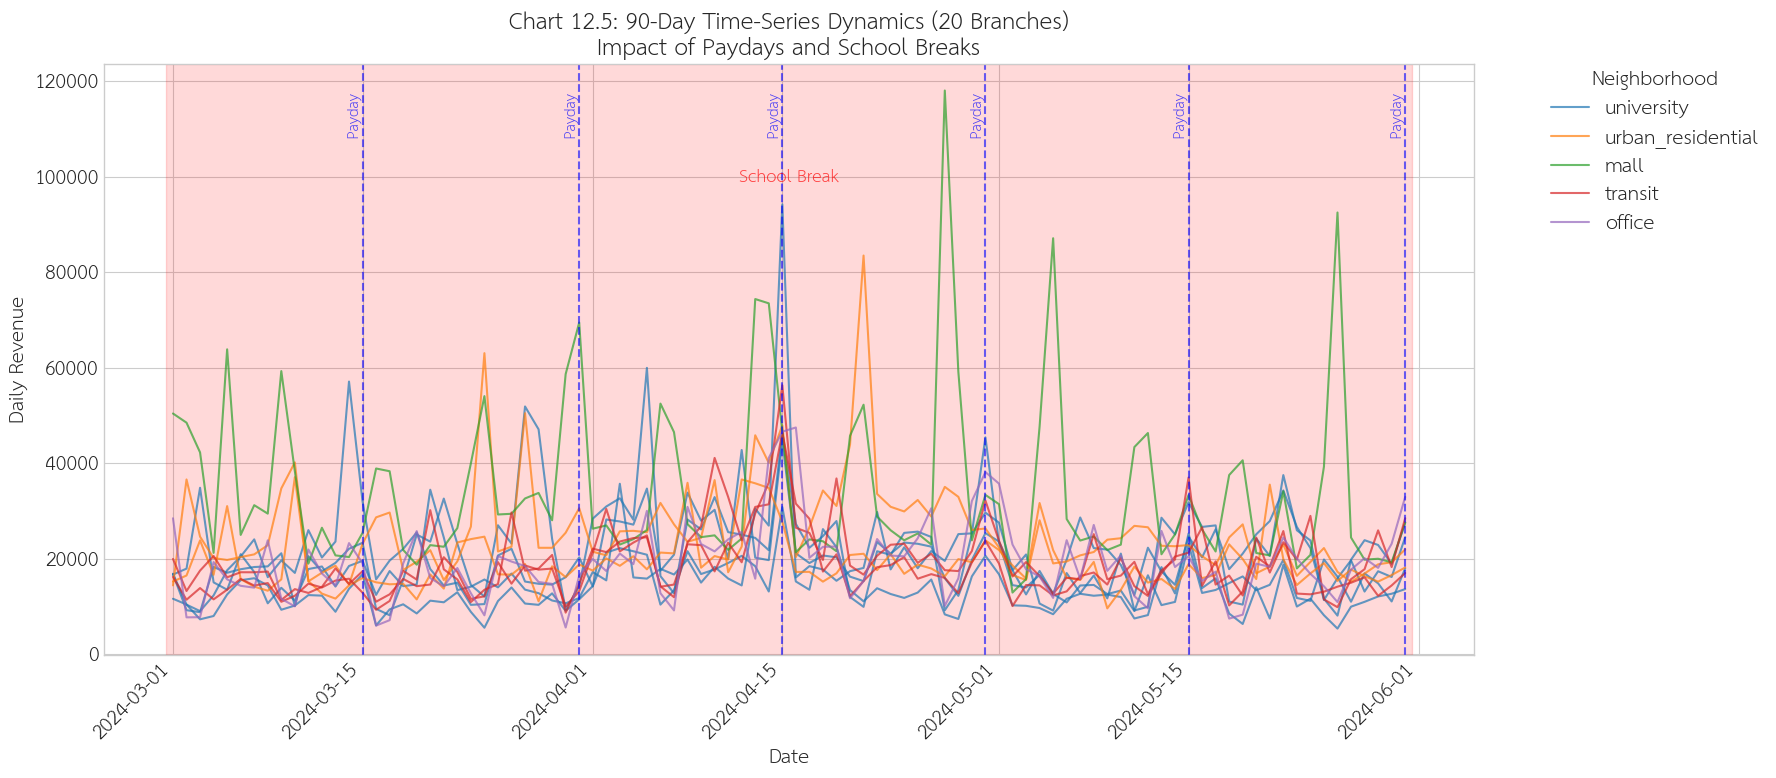

In [17]:
# Filter Data to Q2 2024 (90 Days) to capture both Paydays and Summer School Break
q2_df = df[(df['date'] >= '2024-03-01') & (df['date'] <= '2024-05-31')].copy()

# Select 20 specific stores across different neighborhoods to avoid a messy spaghetti chart
np.random.seed(42)
selected_stores = []
for n_type in ['university', 'mall', 'office', 'transit', 'urban_residential']:
    stores_in_type = store[store['neighborhood_type'] == n_type]['store_id'].unique()
    if len(stores_in_type) > 0:
        selected_stores.extend(np.random.choice(stores_in_type, min(4, len(stores_in_type)), replace=False))

ts_data = q2_df[q2_df['store_id'].isin(selected_stores)].groupby(['date', 'store_id', 'neighborhood_type'])['revenue'].sum().reset_index()

plt.figure(figsize=(18, 8))
ax = sns.lineplot(data=ts_data, x='date', y='revenue', hue='neighborhood_type', units='store_id', estimator=None, alpha=0.7, linewidth=1.5, palette='tab10')

# Highlight Paydays (Vertical Dashed Lines)
paydays = date_dim[(date_dim['date'] >= '2024-03-01') & (date_dim['date'] <= '2024-05-31') & (date_dim['is_payday'])]
for d in paydays['date']:
    plt.axvline(d, color='blue', linestyle='--', alpha=0.6)
    plt.text(d, plt.ylim()[1]*0.95, ' Payday', color='blue', rotation=90, va='top', ha='right', fontsize=10, alpha=0.7)

# Highlight School Breaks (Red Shaded Regions)
breaks = date_dim[(date_dim['date'] >= '2024-03-01') & (date_dim['date'] <= '2024-05-31') & (date_dim['is_school_break'])]
if not breaks.empty:
    break_groups = (breaks['date'] != breaks['date'].shift(1) + pd.Timedelta(days=1)).cumsum()
    for _, group in breaks.groupby(break_groups):
        start_date = group['date'].min() - pd.Timedelta(hours=12)
        end_date = group['date'].max() + pd.Timedelta(hours=12)
        plt.axvspan(start_date, end_date, color='red', alpha=0.15)
        plt.text(start_date + (end_date - start_date)/2, plt.ylim()[1]*0.8, 'School Break', color='red', ha='center', fontsize=12, fontweight='bold', alpha=0.7)

plt.title('Chart 12.5: 90-Day Time-Series Dynamics (20 Branches)\nImpact of Paydays and School Breaks', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Daily Revenue')
plt.xticks(rotation=45, ha='right')
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title='Neighborhood')
plt.tight_layout()
plt.show()

## Section 3: Promotions & Cannibalization


In [18]:
# Promotion Data Preparation
daily_sales = df.groupby(['store_id', 'date', 'category'])['units_sold'].sum().reset_index()
daily_sales = daily_sales.merge(date_dim[['date', 'day_of_week']], on='date', how='left')

promo_expanded = []
for _, r in promo.iterrows():
    dates = pd.date_range(r['start_date'], r['end_date'])
    for d in dates:
        promo_expanded.append({
            'store_id': r['store_id'], 'date': d, 'product_id': r['product_id'],
            'promo_type': r['promo_type'], 'discount_pct': r['discount_pct'],
            'email_sent': r['email_sent'], 'social_campaign': r['social_campaign']
        })
promo_df = pd.DataFrame(promo_expanded).drop_duplicates(subset=['store_id', 'date', 'product_id'])
promo_df = promo_df.merge(prod[['product_id', 'category']], on='product_id', how='left')
promo_daily = promo_df.groupby(['store_id', 'date', 'category']).agg({
    'promo_type': 'first', 'discount_pct': 'max', 'email_sent': 'max', 'social_campaign': 'max'
}).reset_index()

daily_promo = daily_sales.merge(promo_daily, on=['store_id', 'date', 'category'], how='left')
daily_promo['has_promo'] = daily_promo['promo_type'].notna()

### Chart 13: Units Sold by Promotion Type

**Description:**
A comparative boxplot mapping the daily volume of items sold against the specific type of promotion active on that day.

**Actionable Insight:**
Not all promotions are created equal. Buy One Get One (BOGO) heavily inflates the units sold target variable but halves the average unit revenue. Recognizing which promo mechanic yields the highest raw volume lift is essential for accurate demand planning.


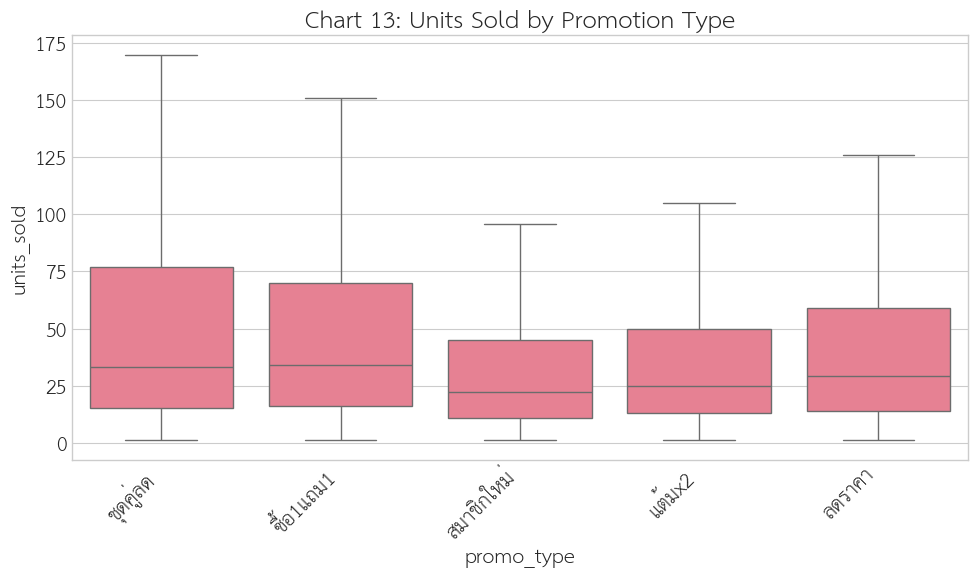

In [19]:
plt.figure(figsize=(10,6))
sns.boxplot(data=daily_promo[daily_promo['has_promo']], x='promo_type', y='units_sold', showfliers=False)
plt.title('Chart 13: Units Sold by Promotion Type')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 14: Average Units Sold by Discount Tier

**Description:**
A barplot grouping active promotions into distinct percentage-off buckets to observe the corresponding sales volume.

**Actionable Insight:**
Identifies the psychological discount sweet spot. In many environments, a minor 10% discount creates the exact same customer urgency as a massive 30% discount. The model needs to learn these non-linear thresholds to avoid over-forecasting deep discounts.


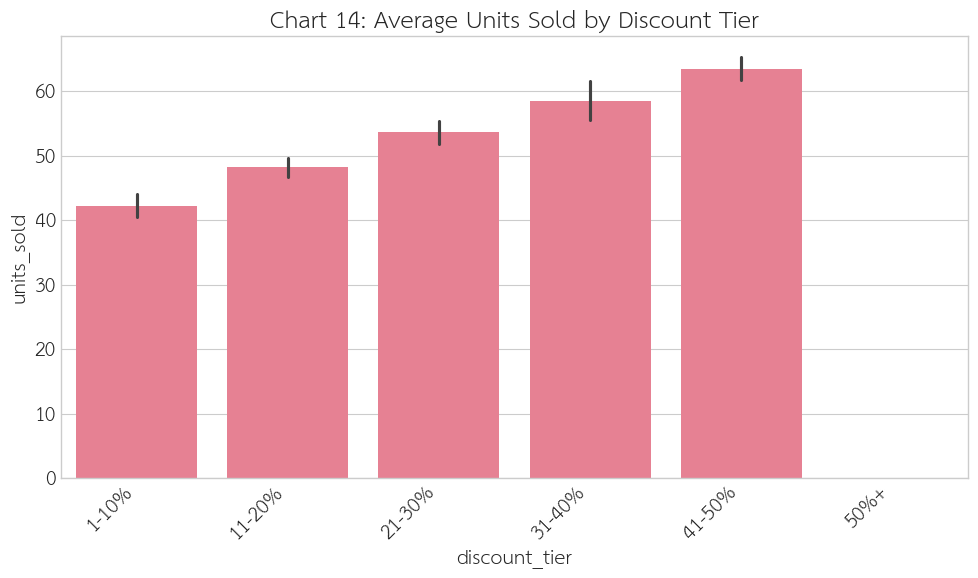

In [20]:
daily_promo['discount_tier'] = pd.cut(daily_promo['discount_pct'], bins=[0, 10, 20, 30, 40, 50, 100], labels=['1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '50%+'])
plt.figure(figsize=(10,6))
sns.barplot(data=daily_promo, x='discount_tier', y='units_sold')
plt.title('Chart 14: Average Units Sold by Discount Tier')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 15: Distribution of Applied Discounts (%)

**Description:**
A density histogram mapping the exact frequency of varying discount depths applied across all historical transactions.

**Actionable Insight:**
Reveals the organization's pricing strategy. If the vast majority of discounts are clustered tightly around 10%, the model will struggle to extrapolate the demand curve if an unprecedented 40% discount is applied in the test set.


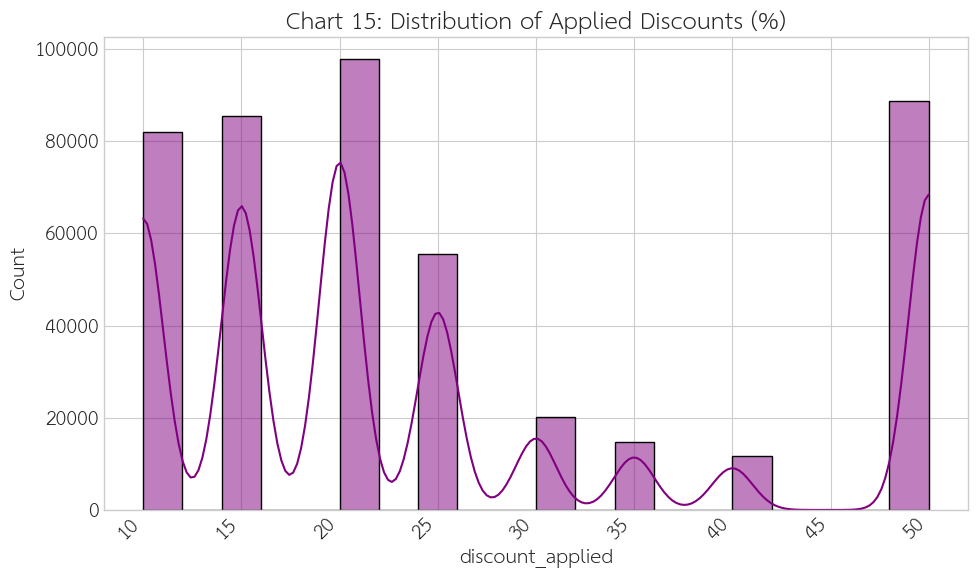

In [21]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['discount_applied'] > 0]['discount_applied'], bins=20, kde=True, color='purple')
plt.title('Chart 15: Distribution of Applied Discounts (%)')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 16: Promotion Lift by Day of Week

**Description:**
A line plot illustrating the average units sold grouped by the day of the week, with separate trend lines for promotional vs. non-promotional days.

**Actionable Insight:**
Highlights the mid-week magic. Running a promotion on a saturated Saturday often yields a tiny marginal lift. Conversely, Thursday promotions might double normal volume.


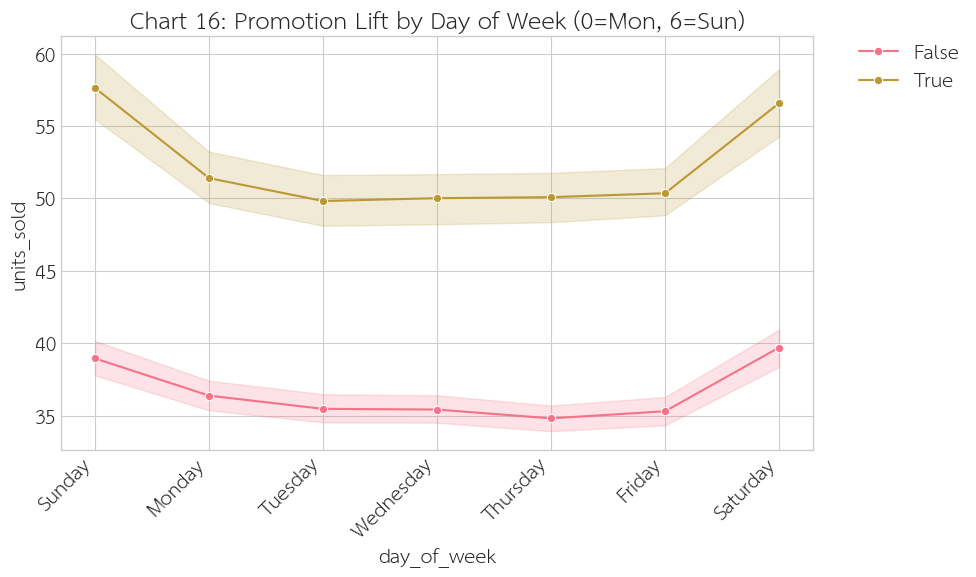

In [22]:
plt.figure(figsize=(10,6))
sns.lineplot(data=daily_promo, x='day_of_week', y='units_sold', hue='has_promo', marker='o')
plt.title('Chart 16: Promotion Lift by Day of Week (0=Mon, 6=Sun)')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 16.5: 90-Day Promotion Fatigue & Baseline Bleed

**Description:**
A 90-day time-series for a store running consecutive promotions. Yellow blocks indicate active promotion periods.

**Actionable Insight (Product/Solution Opportunity):**
This reveals the 'Coupon Clipper' effect. The first promo generates a massive spike. However, notice how the baseline sales *between* the later promos begin to drop below the historical average. Customers are being trained to wait for discounts. The solution is a **'Promo Cooldown Recommender'**—an ML module that enforces a mandatory 21-day cool-down period between heavy discounts to protect organic baseline revenue.


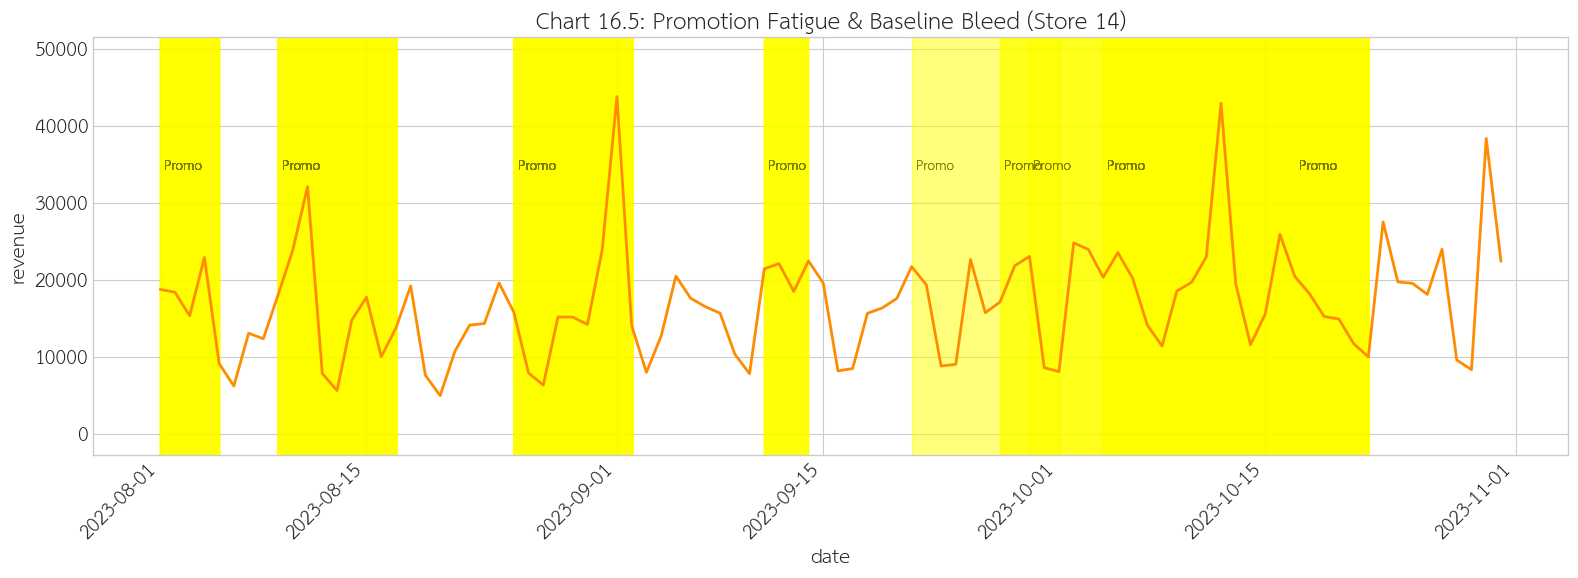

In [23]:
p_store = promo['store_id'].value_counts().index[0]
q3_fatigue = df[(df['store_id'] == p_store) & (df['date'] >= '2023-08-01') & (df['date'] <= '2023-10-31')]
fatigue_ts = q3_fatigue.groupby('date')['revenue'].sum().reset_index()
plt.figure(figsize=(16, 6))
ax = sns.lineplot(data=fatigue_ts, x='date', y='revenue', color='darkorange', linewidth=2)
active_promos = promo[(promo['store_id'] == p_store) & (promo['start_date'] <= '2023-10-31') & (promo['end_date'] >= '2023-08-01')]
for _, r in active_promos.iterrows():
    start = max(r['start_date'], pd.Timestamp('2023-08-01'))
    end = min(r['end_date'], pd.Timestamp('2023-10-31'))
    plt.axvspan(start, end, color='yellow', alpha=0.3)
    plt.text(start, plt.ylim()[1]*0.75, ' Promo', color='olive', fontsize=9)
plt.title(f'Chart 16.5: Promotion Fatigue & Baseline Bleed (Store {p_store})', fontsize=16)
plt.margins(y=0.2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Chart 17: Impact of Marketing Channels

**Description:**
A bar chart analyzing the volume lift driven strictly by the communication medium used to advertise the promotion.

**Actionable Insight:**
Just having a discount isn't enough; customers must know about it. If Social Media drives significantly higher volume than Email, we must treat the social campaign binary flag as a high-weight modifier.


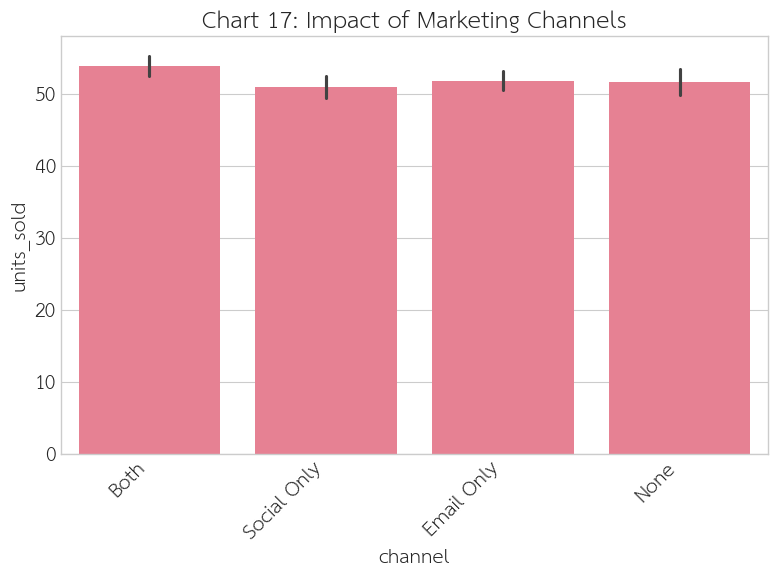

In [24]:
daily_promo['channel'] = 'None'
daily_promo.loc[(daily_promo['email_sent'] == True) & (daily_promo['social_campaign'] == False), 'channel'] = 'Email Only'
daily_promo.loc[(daily_promo['email_sent'] == False) & (daily_promo['social_campaign'] == True), 'channel'] = 'Social Only'
daily_promo.loc[(daily_promo['email_sent'] == True) & (daily_promo['social_campaign'] == True), 'channel'] = 'Both'
plt.figure(figsize=(8,6))
sns.barplot(data=daily_promo[daily_promo['has_promo']], x='channel', y='units_sold')
plt.title('Chart 17: Impact of Marketing Channels')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 18: Promo Responsiveness by Neighborhood

**Description:**
A barplot comparing how different geographic store locations react to active promotions versus baseline days.

**Actionable Insight:**
Office workers might buy coffee regardless of price, showing low price sensitivity. Conversely, university students might aggressively hoard products during promo days.


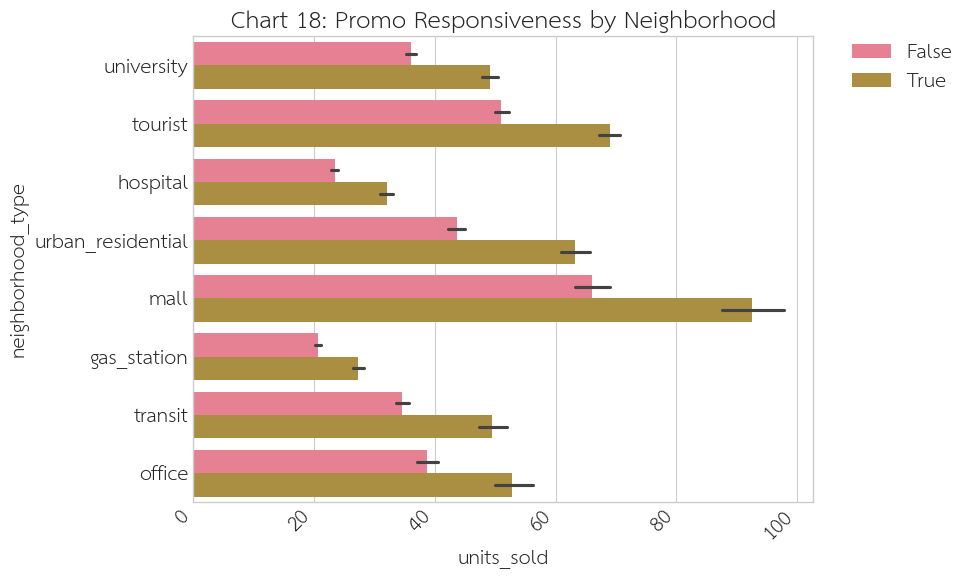

In [25]:
daily_promo_nh = daily_promo.merge(store[['store_id', 'neighborhood_type']], on='store_id', how='left')
plt.figure(figsize=(10,6))
sns.barplot(data=daily_promo_nh, y='neighborhood_type', x='units_sold', hue='has_promo')
plt.title('Chart 18: Promo Responsiveness by Neighborhood')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 19: Bakery Sales when Coffee is on Promo (Cannibalization)

**Description:**
A boxplot testing cross-category elasticity by plotting Bakery sales specifically on days when Coffee is heavily discounted.

**Actionable Insight:**
If discounting Coffee increases Bakery sales, it is a Halo Effect. If Bakery sales plummet, it is Cannibalization. The model must map these cross-elastic dependencies to avoid overestimating total store revenue.


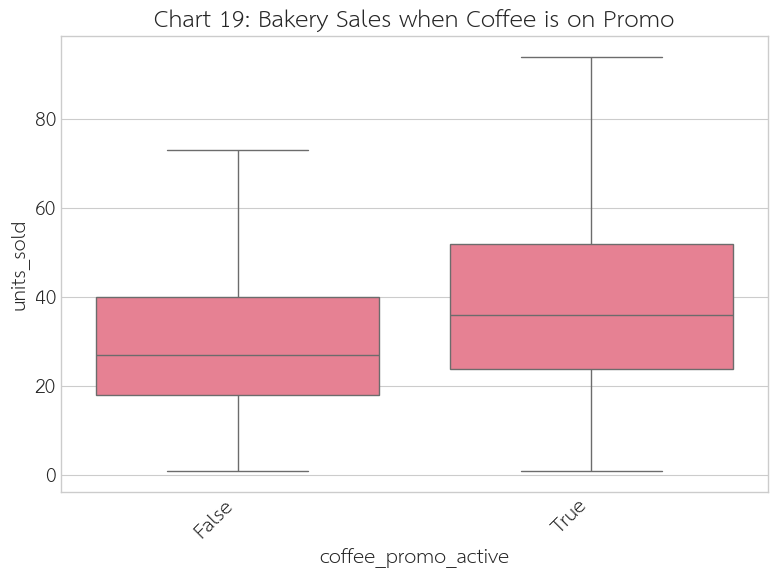

In [26]:
coffee_promo_dates = daily_promo[(daily_promo['category']=='Coffee') & daily_promo['has_promo']][['store_id', 'date']].drop_duplicates()
coffee_promo_dates['coffee_promo_active'] = True
bakery_sales = daily_promo[daily_promo['category']=='Bakery'].merge(coffee_promo_dates, on=['store_id', 'date'], how='left')
bakery_sales['coffee_promo_active'] = bakery_sales['coffee_promo_active'].fillna(False)
plt.figure(figsize=(8,6))
sns.boxplot(data=bakery_sales, x='coffee_promo_active', y='units_sold', showfliers=False)
plt.title('Chart 19: Bakery Sales when Coffee is on Promo')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 19.5: 90-Day Promotion Halo vs Cannibalization Dynamics

**Description:**
A 90-day time-series isolating a single high-performing store. It plots two distinct lines: total units of Coffee sold versus total units of Bakery items sold. Yellow shaded regions indicate periods when a major Coffee discount was active.

**Actionable Insight (Product/Solution Opportunity):**
This visualizes the core logic needed for a **'Smart Bundle Recommendation Engine'**. When a Coffee promotion launches (yellow zone), the coffee line spikes. But does the Bakery line rise with it (Halo Effect), or stay flat/drop (Cannibalization)? If bakery sales fail to scale during a coffee traffic surge, the store is bleeding potential margin. The solution is an ML model that explicitly detects these dead zones and automatically triggers 'Bundle Deals' (e.g., Buy Coffee, get Croissant 50% off) exclusively on those dates to force cross-selling.


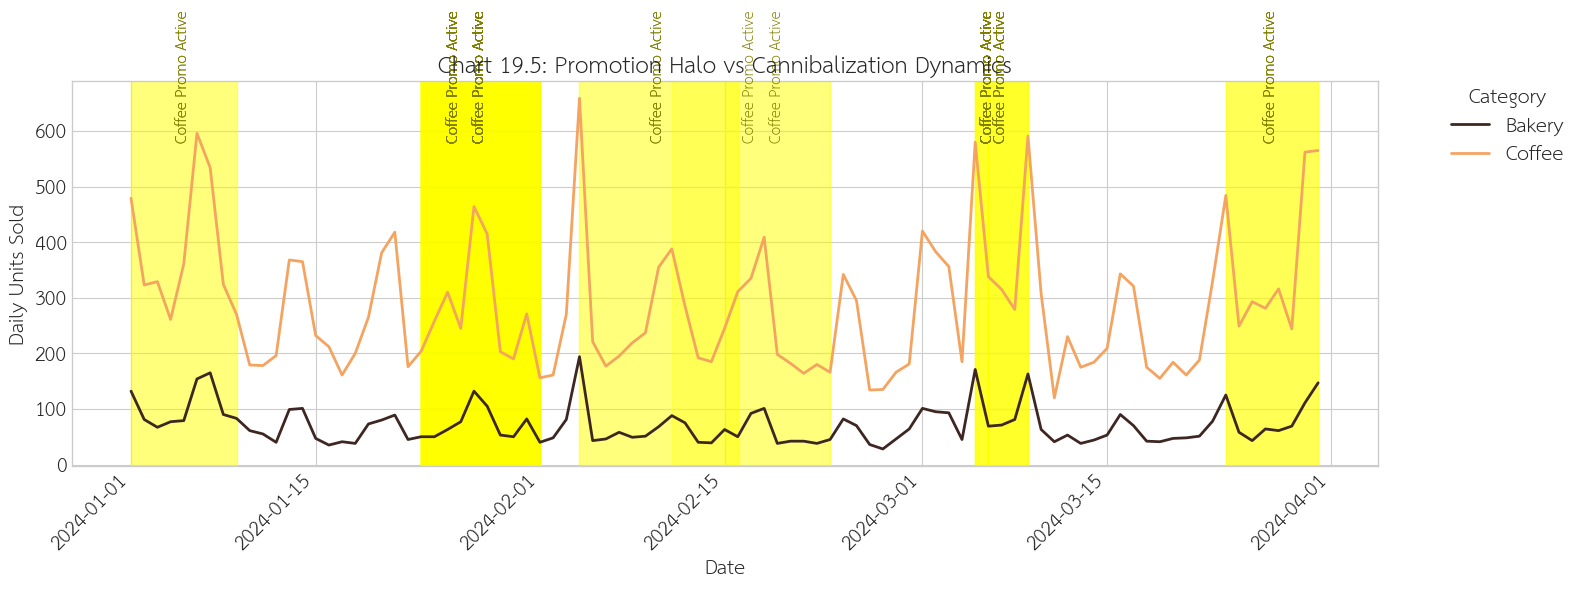

In [27]:
q1_promo = df[(df['date'] >= '2024-01-01') & (df['date'] <= '2024-03-31')].copy()
top_store = q1_promo.groupby('store_id')['units_sold'].sum().idxmax()
cross_sell = q1_promo[(q1_promo['store_id'] == top_store) & (q1_promo['category'].isin(['Coffee', 'Bakery']))]
cross_ts = cross_sell.groupby(['date', 'category'])['units_sold'].sum().reset_index()

promo_active = promo[(promo['store_id'] == top_store) & (promo['product_id'].isin(prod[prod['category']=='Coffee']['product_id'])) & (promo['discount_pct'] >= 10)]

plt.figure(figsize=(16, 6))
ax = sns.lineplot(data=cross_ts, x='date', y='units_sold', hue='category', palette=['#3e2723', '#f4a460'], linewidth=2)

for _, r in promo_active.iterrows():
    start = max(r['start_date'], pd.Timestamp('2024-01-01'))
    end = min(r['end_date'], pd.Timestamp('2024-03-31'))
    if start <= end:
        plt.axvspan(start, end, color='yellow', alpha=0.3)
        plt.text(start + (end-start)/2, plt.ylim()[1]*0.85, 'Coffee Promo Active', color='olive', ha='center', fontsize=10, rotation=90)

plt.title('Chart 19.5: Promotion Halo vs Cannibalization Dynamics', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Daily Units Sold')
plt.xticks(rotation=45, ha='right')
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title='Category')
plt.tight_layout()
plt.show()

## Section 4: Local Events & Store Operations


### Chart 20: Local Event Impact by Category

**Description:**
A bar chart detailing how local events alter the sales volume of specific product categories disproportionately.

**Actionable Insight:**
A massive public event might cause a 200% spike in grab-and-go Beverages but entirely cannibalize Dine-in Bakery items because the store is too crowded to sit down. This proves that Event_Active must be multiplied by Category in the modeling phase.


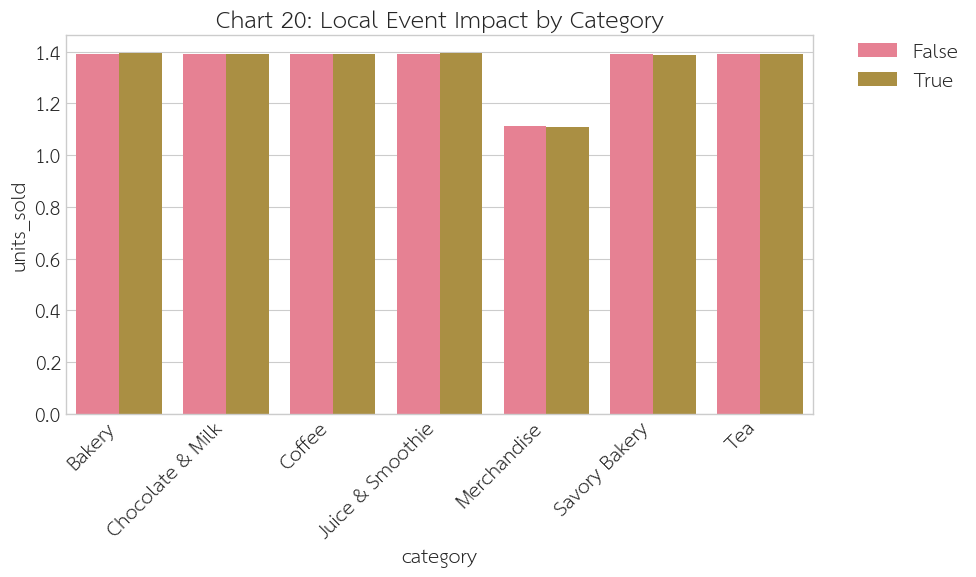

In [28]:
event_cat = df.merge(event[['store_id', 'date', 'event_type']], on=['store_id', 'date'], how='left')
event_cat['has_event'] = event_cat['event_type'].notna()
event_cat_lift = event_cat.groupby(['category', 'has_event'])['units_sold'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=event_cat_lift, x='category', y='units_sold', hue='has_event')
plt.title('Chart 20: Local Event Impact by Category')
plt.xticks(rotation=45)
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 21: Revenue Distribution by Local Event Type

**Description:**
A boxplot analyzing the direct monetary impact of specific localized events taking place near the store.

**Actionable Insight:**
Certain events attract massive crowds but zero customers (e.g., marathons blocking road access), while others (e.g., Food Festivals) drive massive foot traffic. The event type categorical variable is highly predictive of anomalous daily spikes.


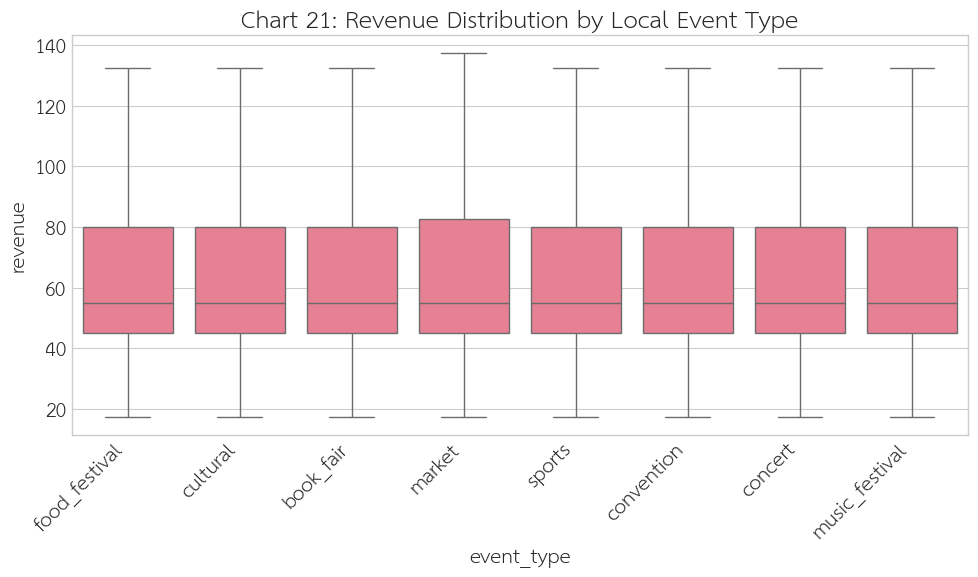

In [29]:
plt.figure(figsize=(10,6))
sns.boxplot(data=event_cat, x='event_type', y='revenue', showfliers=False)
plt.title('Chart 21: Revenue Distribution by Local Event Type')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 21.5: 90-Day Local Event Demand Shock & Hangover

**Description:**
A 90-day time-series for a specific store that hosted a major local event. The red dashed lines pinpoint the exact dates the event took place, plotting the raw units sold before, during, and after the shock.

**Actionable Insight (Product/Solution Opportunity):**
This graph reveals the exact anatomy of an anomaly, justifying an **'Event-Driven Inventory Buffer Model'**. While basic models see a single spike, this time-series exposes both the 'Demand Shock' (a massive single-day spike causing stockouts) and the critical 'Hangover Effect' (sales plunging below baseline the day after because inventory is depleted or customers hoarded goods). A successful product must run an isolated forecasting module specifically for event days to inject a calculated safety buffer, preventing the post-event hangover.


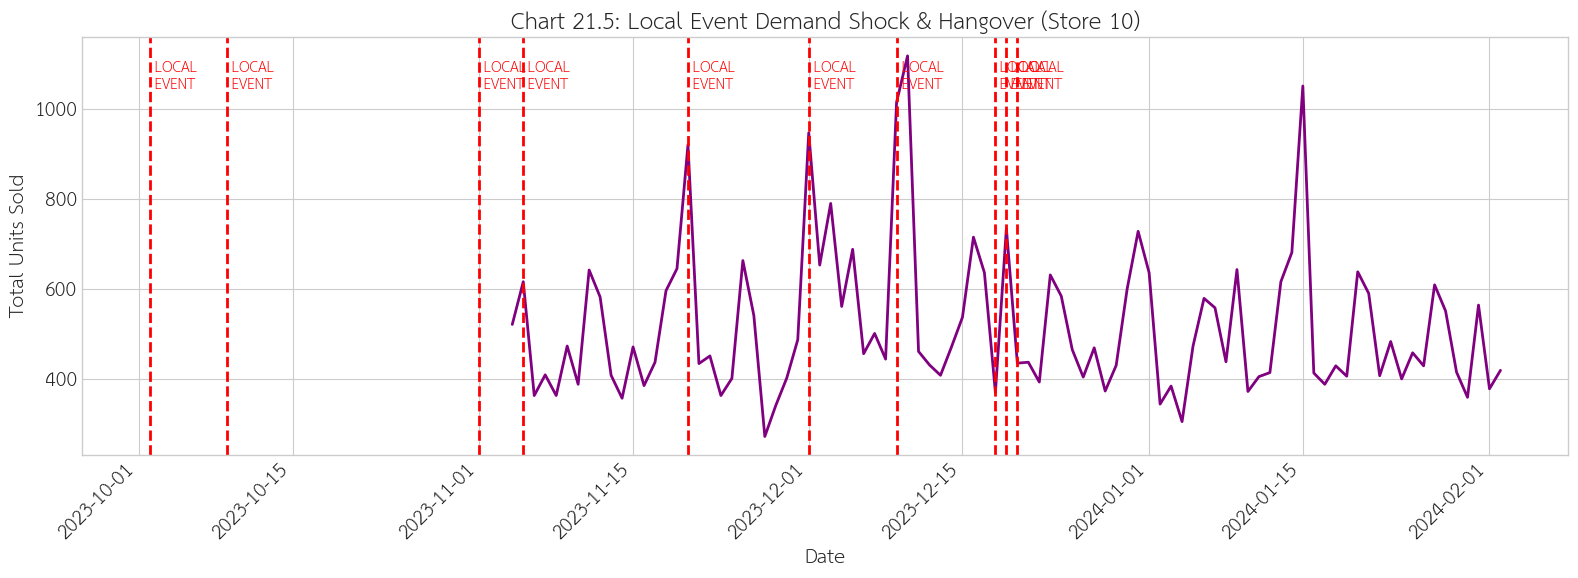

In [30]:
q4_event = event[(event['date'] >= '2023-10-01') & (event['date'] <= '2023-12-31')]
if not q4_event.empty:
    event_store = q4_event['store_id'].iloc[0]
    event_date = q4_event['date'].iloc[0]
    start_win = event_date - pd.Timedelta(days=45)
    end_win = event_date + pd.Timedelta(days=45)
    
    shock_df = df[(df['store_id'] == event_store) & (df['date'] >= start_win) & (df['date'] <= end_win)]
    shock_ts = shock_df.groupby('date')['units_sold'].sum().reset_index()
    
    plt.figure(figsize=(16, 6))
    ax = sns.lineplot(data=shock_ts, x='date', y='units_sold', color='purple', linewidth=2)
    
    event_dates = q4_event[q4_event['store_id'] == event_store]['date']
    for ed in event_dates:
        plt.axvline(ed, color='red', linestyle='--', linewidth=2)
        plt.text(ed, plt.ylim()[1]*0.9, ' LOCAL\n EVENT', color='red', fontsize=10, fontweight='bold', ha='left')

    plt.title(f'Chart 21.5: Local Event Demand Shock & Hangover (Store {event_store})', fontsize=16)
    plt.xlabel('Date')
    plt.ylabel('Total Units Sold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Chart 22: Store Revenue vs Capacity

**Description:**
A bubble scatterplot mapping physical seating capacity against gross revenue, with the bubble size representing the total staff count.

**Actionable Insight:**
Examines operational efficiency boundaries. Does a massive seating area guarantee high revenue, or do tiny, heavily-staffed transit kiosks outperform them? This highlights the non-linear relationship between physical assets and demand throughput.


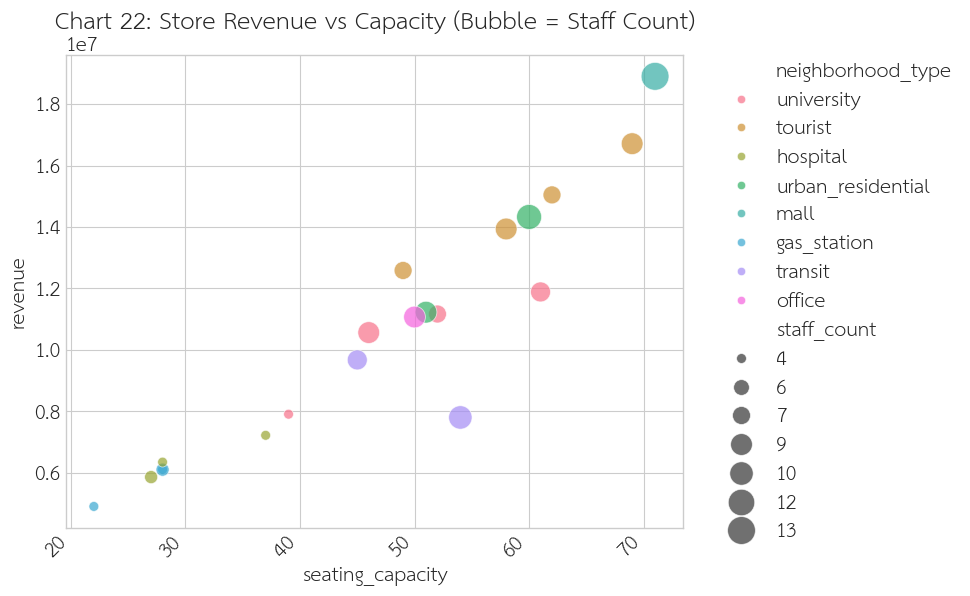

In [31]:
store_rev = df.groupby('store_id')['revenue'].sum().reset_index()
store_rev = store_rev.merge(store, on='store_id')
plt.figure(figsize=(10,6))
sns.scatterplot(data=store_rev, x='seating_capacity', y='revenue', size='staff_count', sizes=(50, 400), hue='neighborhood_type', alpha=0.7)
plt.title('Chart 22: Store Revenue vs Capacity (Bubble = Staff Count)')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 23: Staff Efficiency vs Store Age

**Description:**
A regression plot analyzing the relationship between how long a store has been open and the average revenue generated per staff member.

**Actionable Insight:**
Do mature stores operate more smoothly, or do brand-new Grand Opening stores enjoy higher hype? If older stores are systematically more efficient, store age becomes a critical continuous feature for forecasting.


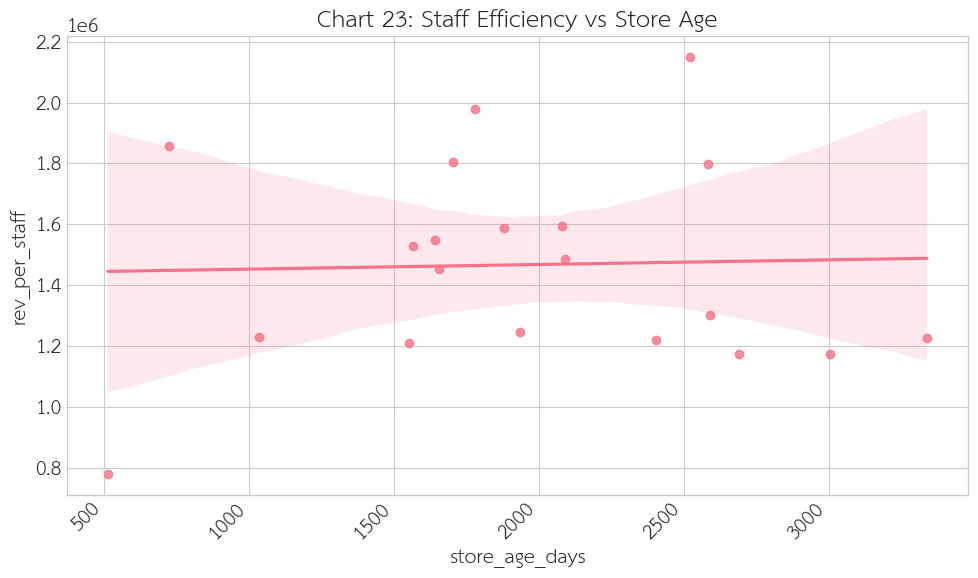

In [32]:
store_rev['store_age_days'] = (pd.Timestamp('2024-11-01') - store_rev['opened_date']).dt.days
store_rev['rev_per_staff'] = store_rev['revenue'] / store_rev['staff_count']
plt.figure(figsize=(10,6))
sns.regplot(data=store_rev, x='store_age_days', y='rev_per_staff')
plt.title('Chart 23: Staff Efficiency vs Store Age')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 24: Staff Stress Index vs Basket Size

**Description:**
A regression plot showing the mathematical relationship between the Stress Index (Orders / Staff Count) and Average Basket Size.

**Actionable Insight:**
Proves that rushed service reduces upsells. When a single barista is overwhelmed, they do not have the time to ask 'Would you like a croissant?', causing units-per-order to plummet. This caps maximum theoretical store revenue during peak rushes.


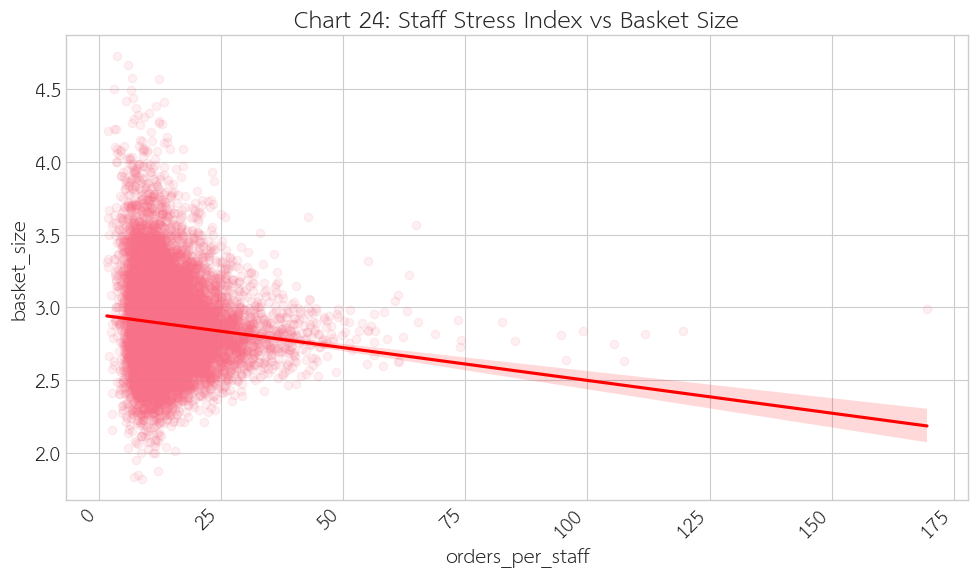

In [33]:
staff_stress = df.groupby(['store_id', 'date']).agg({'order_id': 'nunique', 'units_sold': 'sum', 'staff_count': 'first'}).reset_index()
staff_stress['orders_per_staff'] = staff_stress['order_id'] / staff_stress['staff_count']
staff_stress['basket_size'] = staff_stress['units_sold'] / staff_stress['order_id']
plt.figure(figsize=(10, 6))
sns.regplot(data=staff_stress, x='orders_per_staff', y='basket_size', scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title('Chart 24: Staff Stress Index vs Basket Size')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 25: Daily Order Volume (Drive-Through vs Standard)

**Description:**
A boxplot contrasting the total daily order throughput between branches equipped with a Drive-Through window versus standard walk-in cafes.

**Actionable Insight:**
Drive-Through stores have a vastly higher theoretical capacity ceiling during rush hour because they process cars and walk-ins simultaneously. Models should inherently allow higher maximum predictions for these stores.


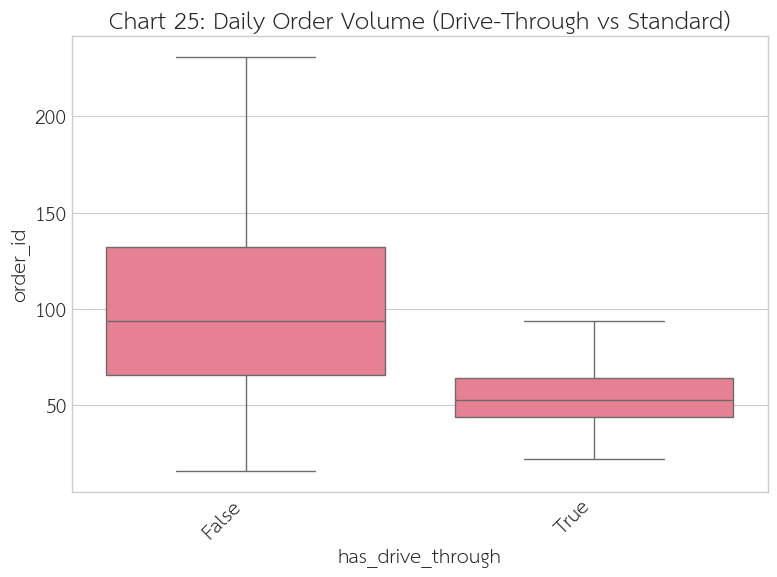

In [34]:
dt_impact = df.groupby(['store_id', 'date']).agg({'order_id': 'nunique', 'has_drive_through': 'first'})
plt.figure(figsize=(8,6))
sns.boxplot(data=dt_impact, x='has_drive_through', y='order_id', showfliers=False)
plt.title('Chart 25: Daily Order Volume (Drive-Through vs Standard)')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 26: Operating Hours Effect

**Description:**
An analysis correlating a store's total daily sales capacity against its designated operating hours.

**Actionable Insight:**
Stores with extended operating hours inherently possess a higher throughput ceiling. If operating hours change over time, the historical baseline must be normalized to prevent the model from misinterpreting a revenue jump as structural demand growth.


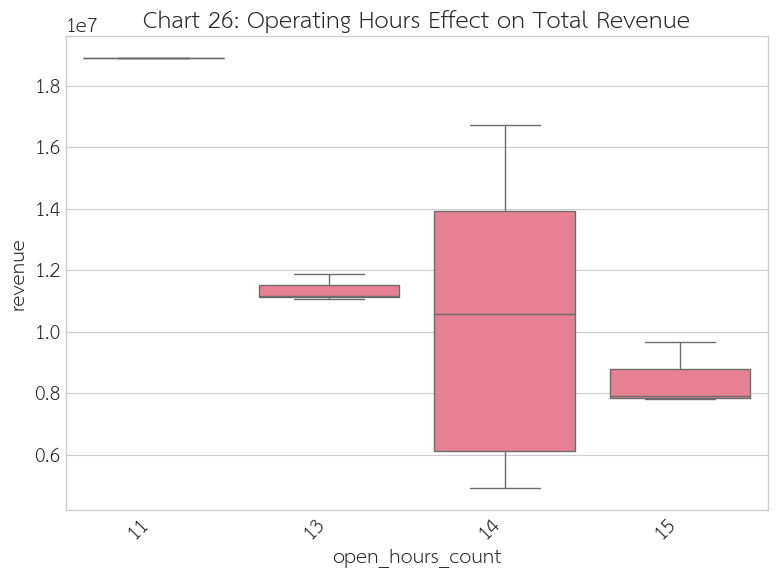

In [35]:
store['open_hours_count'] = store['close_time'].str[:2].astype(int) - store['open_time'].str[:2].astype(int)
store_op = store_rev.merge(store[['store_id', 'open_hours_count']], on='store_id')
plt.figure(figsize=(8,6))
sns.boxplot(data=store_op, x='open_hours_count', y='revenue')
plt.title('Chart 26: Operating Hours Effect on Total Revenue')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

## Section 5: Customer Retention & Demographics


### Chart 27: Total Revenue by Membership

**Description:**
A pie chart illustrating the macroeconomic revenue split between Walk-in customers and registered Members.

**Actionable Insight:**
Understanding the baseline share of wallet reveals if our business is heavily reliant on a small pool of loyalists or sustained by high-volume foot traffic. Member Sales represent stable demand, whereas Walk-in Sales are highly volatile.


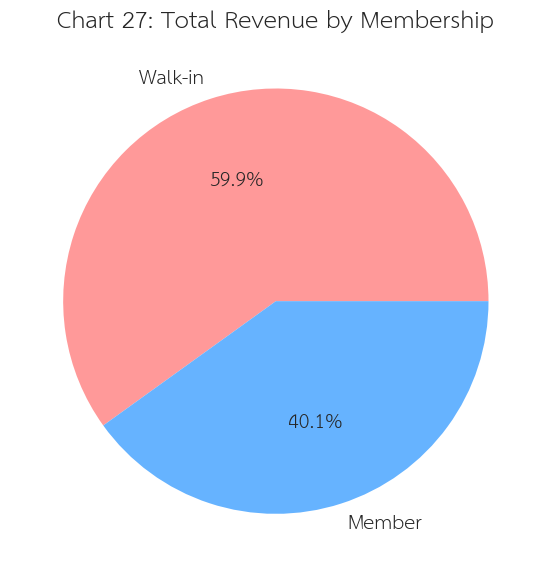

In [36]:
rev_split = df.groupby('is_member')['revenue'].sum()
plt.figure(figsize=(6,6))
plt.pie(rev_split, labels=['Walk-in', 'Member'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Chart 27: Total Revenue by Membership')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 28: Order Frequency by Hour of Day

**Description:**
A line plot displaying the total number of unique orders placed throughout the 24-hour cycle, separated by membership status.

**Actionable Insight:**
Members often exhibit sharp spikes during morning commutes, while walk-ins might drive afternoon/weekend volume. This variance strongly suggests creating an 'is_morning_rush' interaction feature.


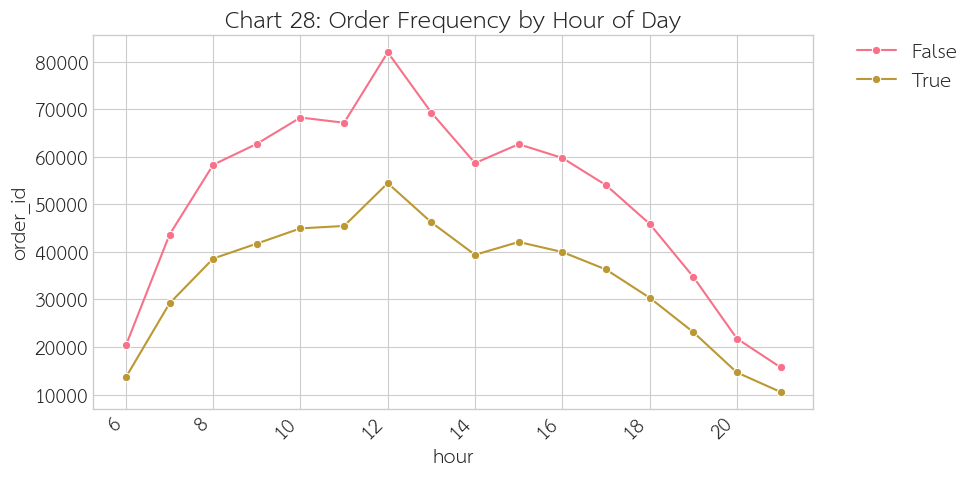

In [37]:
hourly = df.groupby(['hour', 'is_member'])['order_id'].nunique().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(data=hourly, x='hour', y='order_id', hue='is_member', marker='o')
plt.title('Chart 28: Order Frequency by Hour of Day')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 28.5: 90-Day Temperature-Driven Category Crossover

**Description:**
A 90-day time-series transitioning from February to May (heading into the extreme Thai Summer). It compares 'Coffee' units vs 'Juice & Smoothie' units. The red zone marks Peak Summer.

**Actionable Insight (Product/Solution Opportunity):**
Observe the specific week where the Juice/Smoothie line surges upwards and crosses the baseline. This proves temperature alters the category mix. The solution is a **'Climate-Triggered Packaging Rebalance'**—an automated supply chain rule that triggers a 300% increase in orders for clear plastic cups and dome lids exactly two weeks before this historical crossover, preventing catastrophic stockouts of cold packaging.


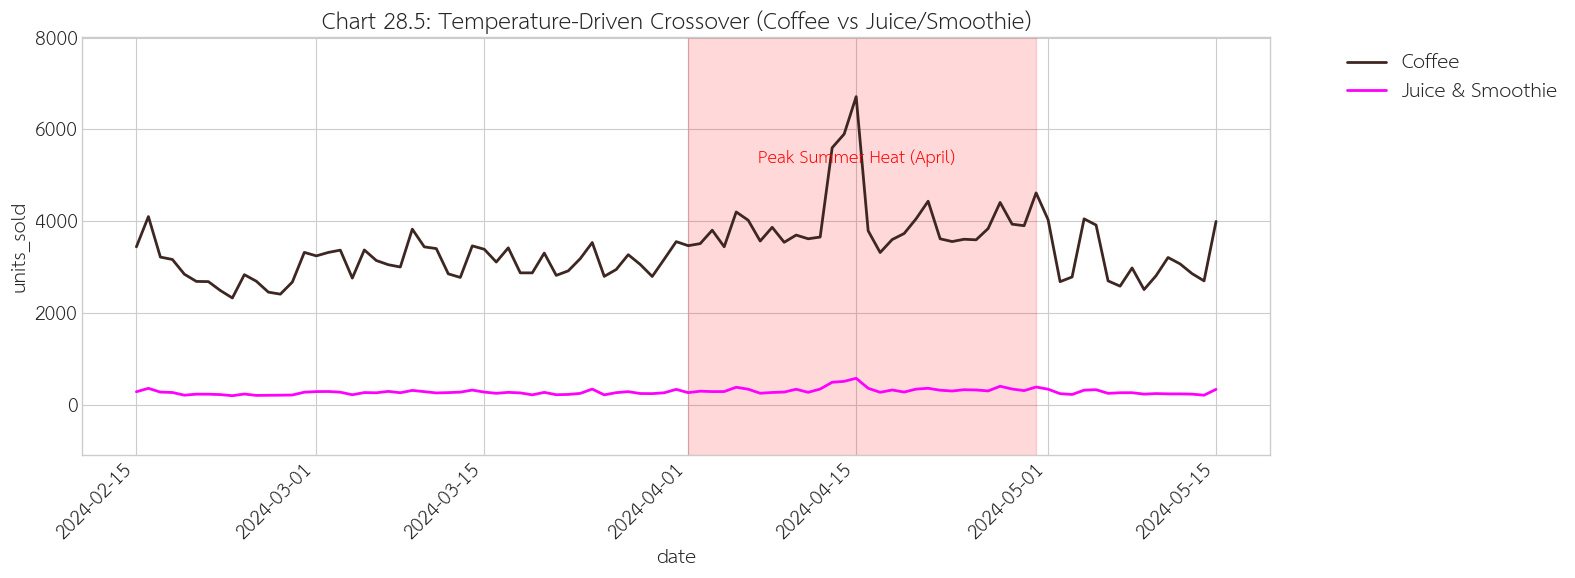

In [38]:
q2_temp = df[(df['date'] >= '2024-02-15') & (df['date'] <= '2024-05-15')]
temp_ts = q2_temp[q2_temp['category'].isin(['Coffee', 'Juice & Smoothie'])].groupby(['date', 'category'])['units_sold'].sum().reset_index()
plt.figure(figsize=(16, 6))
ax = sns.lineplot(data=temp_ts, x='date', y='units_sold', hue='category', palette=['#3e2723', 'magenta'], linewidth=2)
plt.axvspan(pd.Timestamp('2024-04-01'), pd.Timestamp('2024-04-30'), color='red', alpha=0.15)
plt.text(pd.Timestamp('2024-04-15'), plt.ylim()[1]*0.75, 'Peak Summer Heat (April)', color='red', ha='center', fontsize=12, fontweight='bold')
plt.title('Chart 28.5: Temperature-Driven Crossover (Coffee vs Juice/Smoothie)', fontsize=16)
plt.margins(y=0.2)
plt.xticks(rotation=45, ha='right')
if ax.get_legend() is not None: plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Chart 29: Category Preference Share

**Description:**
A 100% stacked bar chart that normalizes the volume of products sold within each category, split by membership status.

**Actionable Insight:**
Reveals if Members lean more heavily towards high-margin Coffee or add-on Bakery items. If Walk-ins rarely buy Merchandise, inventory forecasting models must dynamically weigh Walk-in foot traffic predictions strictly towards beverage supplies.


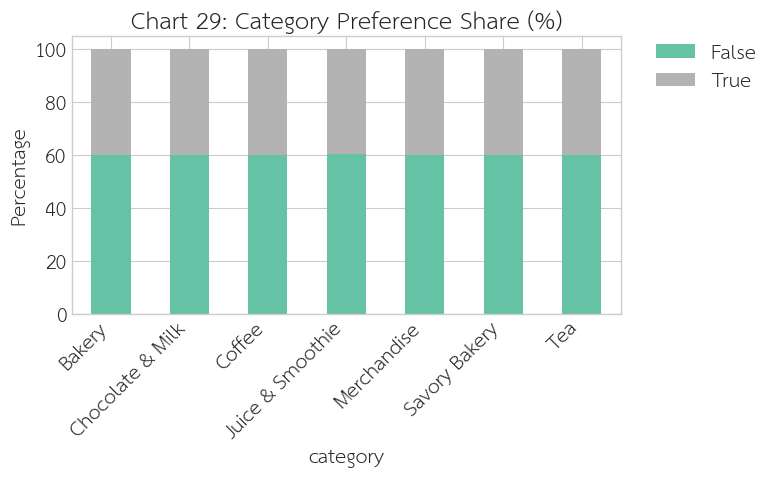

In [39]:
cat_pref = df.groupby(['category', 'is_member'])['units_sold'].sum().unstack()
cat_pref = cat_pref.div(cat_pref.sum(axis=1), axis=0) * 100
cat_pref.plot(kind='bar', stacked=True, colormap='Set2', figsize=(8,5))
plt.title('Chart 29: Category Preference Share (%)')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 30: Monthly Active Users (MAU) Trend

**Description:**
A chronological bar chart plotting the number of unique customers engaging with the brand every month.

**Actionable Insight:**
Identifies macro-level business health. If MAU is steadily growing, baseline sales predictions for future horizons must be naturally elevated regardless of promotions or seasons, reflecting the growing customer pool.


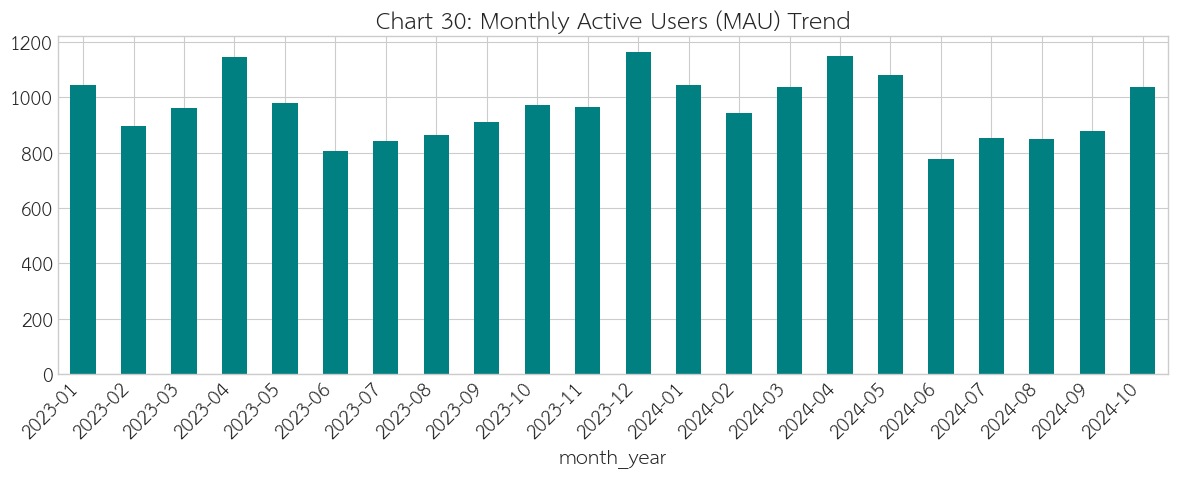

In [40]:
order['month_year'] = order['date'].dt.to_period('M')
mau = order.dropna(subset=['customer_id']).groupby('month_year')['customer_id'].nunique()
plt.figure(figsize=(12, 5))
mau.plot(kind='bar', color='teal')
plt.title('Chart 30: Monthly Active Users (MAU) Trend')
plt.xticks(rotation=45)
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 31: Customer Cohort Retention Heatmap

**Description:**
A triangular heatmap tracking groups of customers based on the month they made their first purchase.

**Actionable Insight:**
A massive drop-off in Month 2 indicates poor onboarding. Consistent long-term retention allows us to mathematically calculate Customer Lifetime Value (LTV) and predict stable future revenue streams.


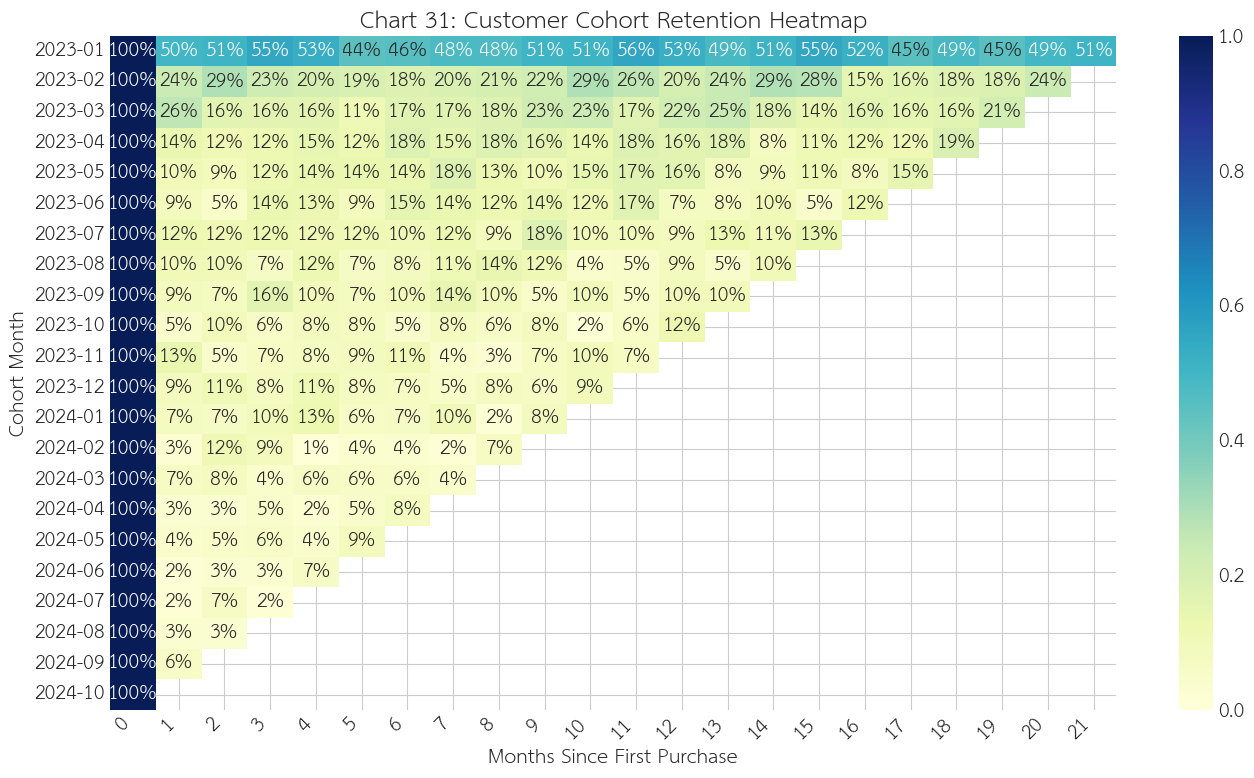

In [41]:
cohorts = order.dropna(subset=['customer_id'])[['customer_id', 'date']].copy()
cohorts['cohort_month'] = cohorts.groupby('customer_id')['date'].transform('min').dt.to_period('M')
cohorts['order_month'] = cohorts['date'].dt.to_period('M')
cohort_group = cohorts.groupby(['cohort_month', 'order_month'])['customer_id'].nunique().reset_index()
cohort_group['period_number'] = (cohort_group['order_month'] - cohort_group['cohort_month']).apply(lambda x: x.n)
cohort_pivot = cohort_group.pivot(index='cohort_month', columns='period_number', values='customer_id')
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)
plt.figure(figsize=(14, 8))
sns.heatmap(retention_matrix, annot=True, fmt='.0%', cmap='YlGnBu', vmin=0.0, vmax=1.0)
plt.title('Chart 31: Customer Cohort Retention Heatmap')
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Purchase')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 32: Customer LTV by Home Neighborhood

**Description:**
A boxplot evaluating the Lifetime Value of customers grouped by the primary neighborhood type they reside or work in.

**Actionable Insight:**
Helps identify the geographic source of high-value customers. If customers living near Hospitals have exceptionally high LTVs, any new store opened near a hospital should mathematically expect a higher baseline revenue curve.


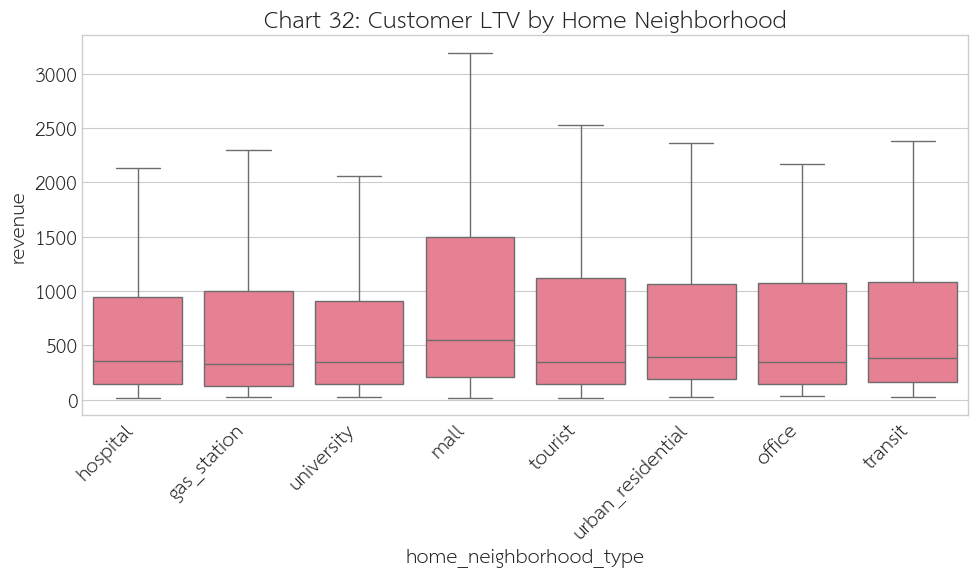

In [42]:
ltv = df.dropna(subset=['customer_id']).groupby('customer_id')['revenue'].sum().reset_index()
ltv = ltv.merge(cust[['customer_id', 'home_neighborhood_type']], on='customer_id')
plt.figure(figsize=(10,6))
sns.boxplot(data=ltv, x='home_neighborhood_type', y='revenue', showfliers=False)
plt.title('Chart 32: Customer LTV by Home Neighborhood')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 33: Avg LTV by Registration Year (Vintage)

**Description:**
A bar chart comparing the Lifetime Value of Early Adopter customers versus newly acquired customers.

**Actionable Insight:**
Reveals if the customer base is degrading in quality. If older cohorts spend significantly more per month than new cohorts, long-term revenue growth is highly vulnerable to early-adopter churn.


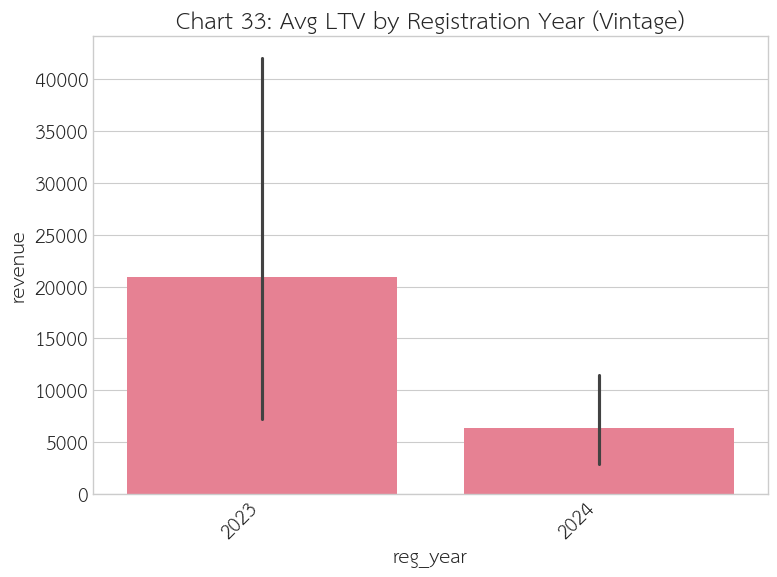

In [43]:
vintage = ltv.merge(cust[['customer_id', 'registration_date']], on='customer_id')
vintage['reg_year'] = vintage['registration_date'].dt.year
plt.figure(figsize=(8,6))
sns.barplot(data=vintage, x='reg_year', y='revenue')
plt.title('Chart 33: Avg LTV by Registration Year (Vintage)')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 34: Cross-Store Shopping Behavior

**Description:**
A distribution bar chart counting how many distinct store branches a single customer visits.

**Actionable Insight:**
Measures brand loyalty versus location loyalty. If a massive segment visits 3+ stores, it implies that localized marketing campaigns will cannibalize sales from neighboring stores, creating a Spillover Effect.


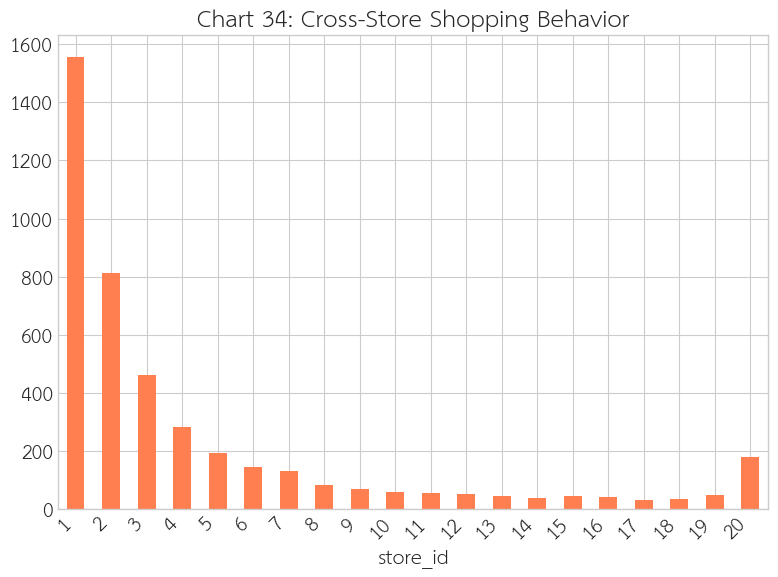

In [44]:
cross_store = order.dropna(subset=['customer_id']).groupby('customer_id')['store_id'].nunique().value_counts().sort_index()
plt.figure(figsize=(8,6))
cross_store.plot(kind='bar', color='coral')
plt.title('Chart 34: Cross-Store Shopping Behavior')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 35: Lorenz Curve (Revenue Concentration)

**Description:**
A cumulative distribution curve ranking all customers by total spend and plotting the cumulative percentage of revenue they generate.

**Actionable Insight:**
Proves the Pareto Principle (80/20 rule). If the curve is extremely bowed, a tiny fraction of customers generate the vast majority of income. The forecasting model must be hyper-sensitive to the behavior of this micro-population.


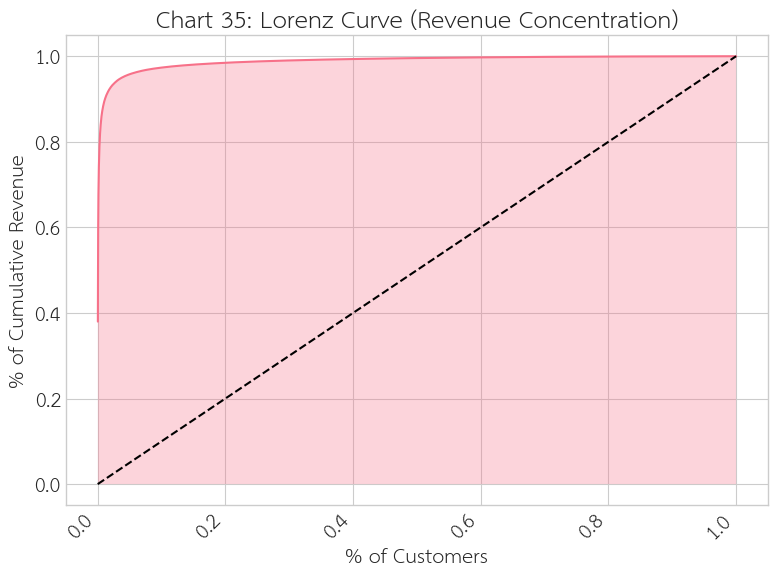

In [45]:
customer_revenue = df.dropna(subset=['customer_id']).groupby('customer_id')['revenue'].sum().sort_values(ascending=False)
cumulative_revenue = customer_revenue.cumsum() / customer_revenue.sum()
plt.figure(figsize=(8,6))
plt.plot(np.arange(1, len(cumulative_revenue)+1) / len(cumulative_revenue), cumulative_revenue.values)
plt.fill_between(np.arange(1, len(cumulative_revenue)+1) / len(cumulative_revenue), cumulative_revenue.values, alpha=0.3)
plt.title('Chart 35: Lorenz Curve (Revenue Concentration)')
plt.xlabel('% of Customers')
plt.ylabel('% of Cumulative Revenue')
plt.plot([0,1], [0,1], 'k--')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 35.5: 90-Day Weekend Micro-Migration (Residential vs Mall)

**Description:**
A 90-day time-series plotting an Urban Residential store against a Mall store. Yellow shaded regions highlight Weekends.

**Actionable Insight (Product/Solution Opportunity):**
This graph shows perfectly inverse demand waves. Residential peaks on weekdays and crashes on weekends, while Mall stores explode on weekends. The solution is a **'Dynamic Part-Time Roster'**—an automated HR system that shares a pool of baristas, assigning them to Residential branches Monday-Friday, and shifting them to Mall branches Saturday-Sunday to optimize labor costs.


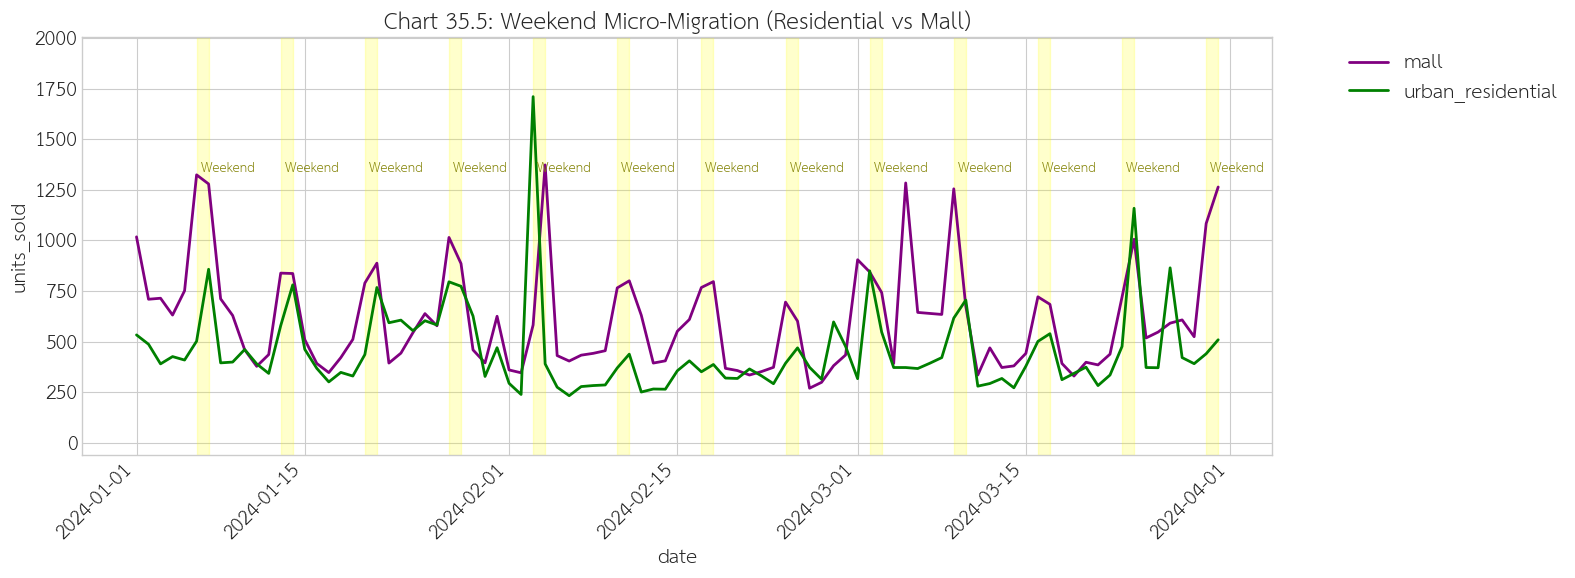

In [46]:
q1_mig = df[(df['date'] >= '2024-01-01') & (df['date'] <= '2024-03-31')]
mall = store[store['neighborhood_type'] == 'mall']['store_id'].unique()[0]
res = store[store['neighborhood_type'] == 'urban_residential']['store_id'].unique()[0]
mig_ts = q1_mig[q1_mig['store_id'].isin([mall, res])].groupby(['date', 'neighborhood_type'])['units_sold'].sum().reset_index()
plt.figure(figsize=(16, 6))
ax = sns.lineplot(data=mig_ts, x='date', y='units_sold', hue='neighborhood_type', palette=['purple', 'green'], linewidth=2)
weekends = date_dim[(date_dim['date'] >= '2024-01-01') & (date_dim['date'] <= '2024-03-31') & (date_dim['is_weekend'])]
if not weekends.empty:
    we_groups = (weekends['date'] != weekends['date'].shift(1) + pd.Timedelta(days=1)).cumsum()
    for _, group in weekends.groupby(we_groups):
        plt.axvspan(group['date'].min(), group['date'].max(), color='yellow', alpha=0.2)
        plt.text(group['date'].min(), plt.ylim()[1]*0.75, ' Weekend', color='olive', fontsize=9)
plt.title('Chart 35.5: Weekend Micro-Migration (Residential vs Mall)', fontsize=16)
plt.margins(y=0.2)
plt.xticks(rotation=45, ha='right')
if ax.get_legend() is not None: plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Chart 36: Active Whales Over Time

**Description:**
A line plot isolating the monthly engagement exclusively for the Top 5% highest-spending Whale customers.

**Actionable Insight:**
Losing a single Whale can crash a store's daily revenue average. Tracking their churn rate alerts us to structural demand shifts that general models might mistake as ordinary seasonal dips.


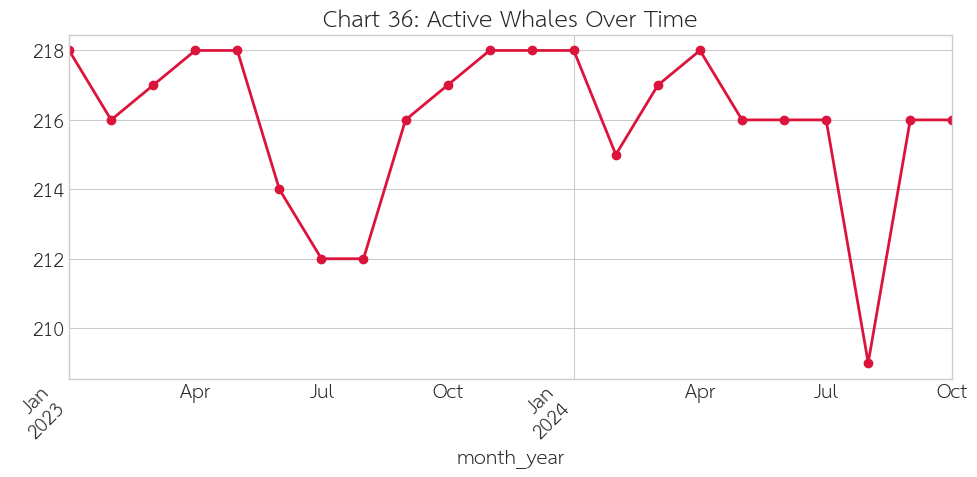

In [47]:
top_5_pct_threshold = customer_revenue.quantile(0.95)
whales = customer_revenue[customer_revenue >= top_5_pct_threshold].index
whale_orders = order[order['customer_id'].isin(whales)]
whale_mau = whale_orders.groupby('month_year')['customer_id'].nunique()
plt.figure(figsize=(10,5))
whale_mau.plot(kind='line', marker='o', color='crimson', linewidth=2)
plt.title('Chart 36: Active Whales Over Time')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 36.5: 90-Day Payday Splurge Behavior (Luxury vs Necessity)

**Description:**
A 90-day time-series comparing the sales of 'Merchandise' (Luxury) vs 'Coffee' (Necessity), with vertical lines marking Paydays.

**Actionable Insight (Product/Solution Opportunity):**
Notice how Coffee sales are relatively stable across the month, but Merchandise sales experience violent spikes **exactly on Paydays**. This proves that marketing budgets for Tumblers and Premium items are wasted mid-month. The solution is **'Targeted FOMO Marketing'**—an automated ad engine that only deploys merchandise ads 48 hours around Payday to maximize ROI.


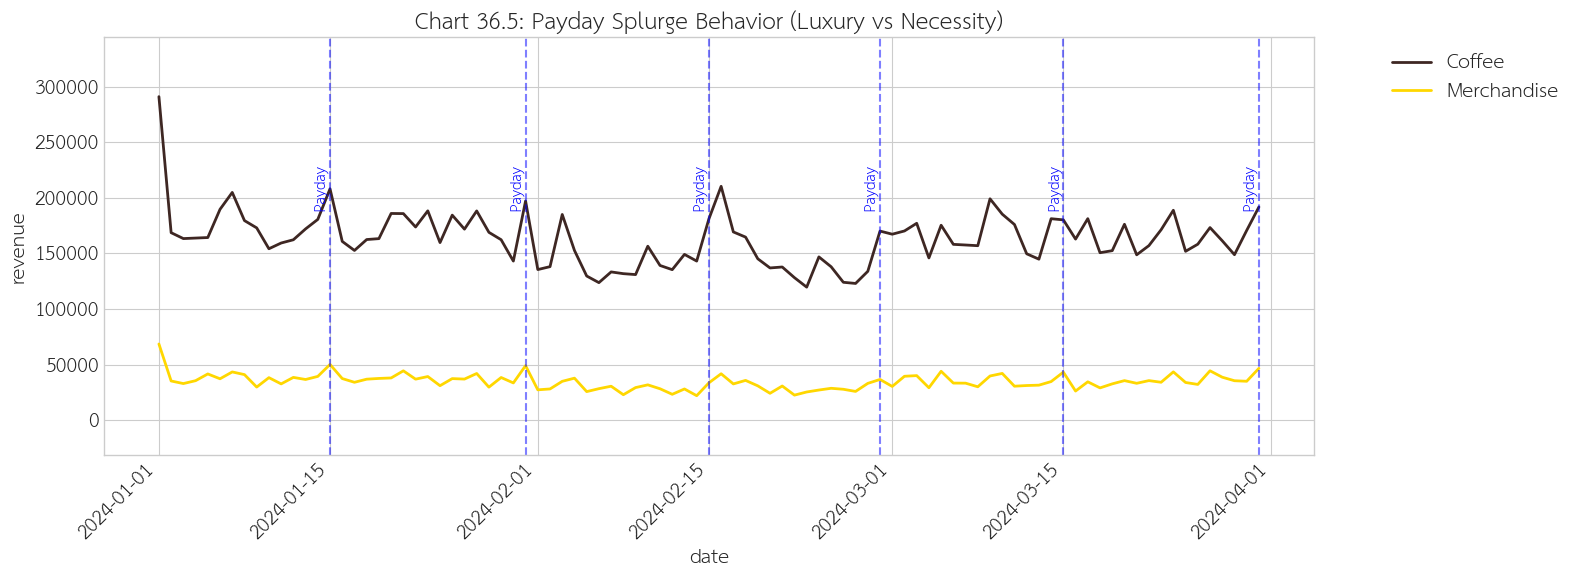

In [48]:
q1_splurge = df[(df['date'] >= '2024-01-01') & (df['date'] <= '2024-03-31')]
splurge_ts = q1_splurge[q1_splurge['category'].isin(['Coffee', 'Merchandise'])].groupby(['date', 'category'])['revenue'].sum().reset_index()
plt.figure(figsize=(16, 6))
ax = sns.lineplot(data=splurge_ts, x='date', y='revenue', hue='category', palette=['#3e2723', 'gold'], linewidth=2)
paydays = date_dim[(date_dim['date'] >= '2024-01-01') & (date_dim['date'] <= '2024-03-31') & (date_dim['is_payday'])]
for d in paydays['date']:
    plt.axvline(d, color='blue', linestyle='--', alpha=0.5)
    plt.text(d, plt.ylim()[1]*0.75, ' Payday', color='blue', rotation=90, va='top', ha='right', fontsize=10)
plt.title('Chart 36.5: Payday Splurge Behavior (Luxury vs Necessity)', fontsize=16)
plt.margins(y=0.2)
plt.xticks(rotation=45, ha='right')
if ax.get_legend() is not None: plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Section 6: Product & Inventory Dynamics


### Chart 37: Category Co-occurrence Heatmap

**Description:**
A matrix heatmap visualizing Market Basket Analysis. The numbers indicate how often two distinct product categories are purchased in the same order.

**Actionable Insight:**
Critical for cross-selling strategies. If Coffee and Bakery have massive co-occurrence, a stockout in Bakery will heavily depress Coffee sales, meaning inventory forecasts must be mathematically coupled.


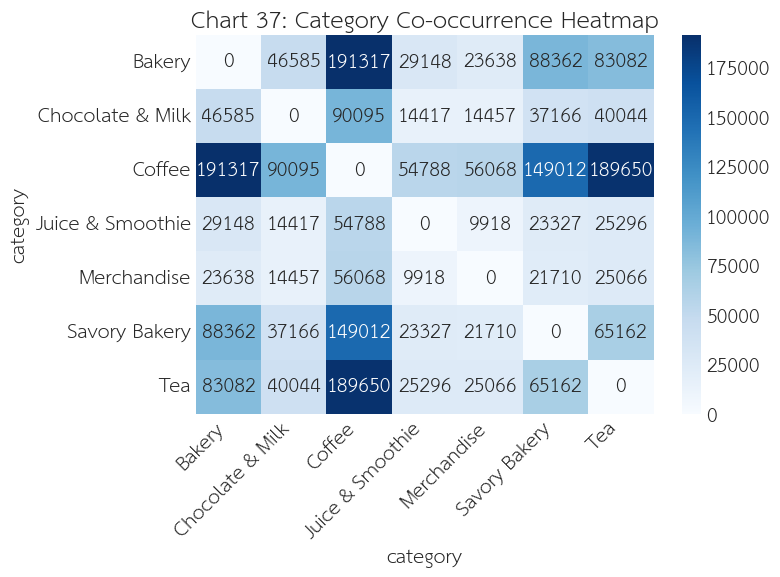

In [49]:
basket_matrix = df.groupby(['order_id', 'category'])['units_sold'].sum().unstack().fillna(0).apply(lambda x: (x>0).astype(int))
co_occurrence = basket_matrix.T.dot(basket_matrix)
np.fill_diagonal(co_occurrence.values, 0)
plt.figure(figsize=(8,6))
sns.heatmap(co_occurrence, cmap='Blues', annot=True, fmt='d')
plt.title('Chart 37: Category Co-occurrence Heatmap')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 38: Seasonal vs Regular Item Sales

**Description:**
A 7-Day Moving Average line plot tracking the lifecycle of Seasonal/Limited Time menu items versus permanent fixtures.

**Actionable Insight:**
Seasonal items defy standard autoregressive patterns; they launch with a massive spike and exhibit exponential decay. Forecasting these items requires unique features such as 'days_since_launch'.


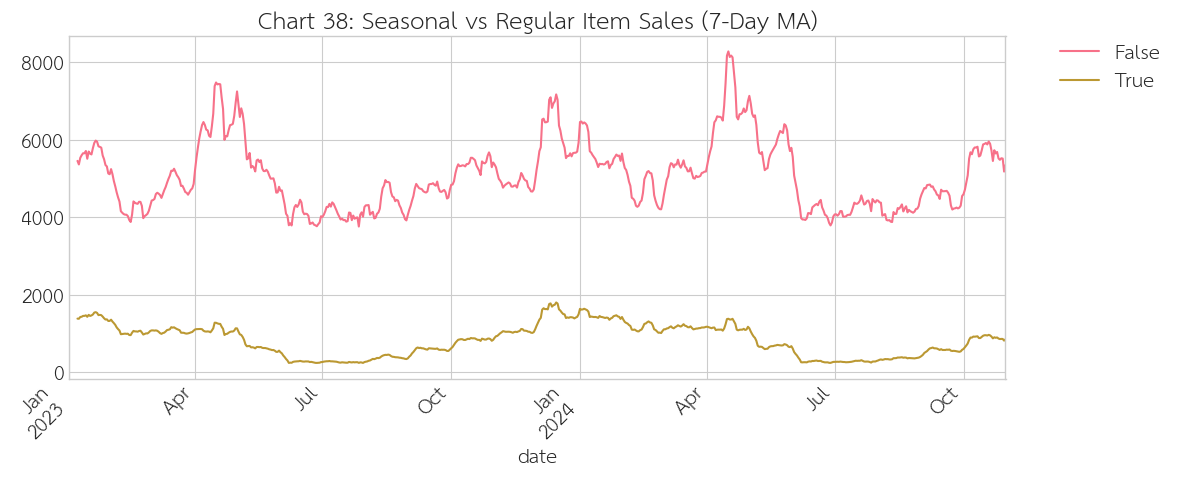

In [50]:
seasonal_perf = df.groupby(['date', 'is_seasonal'])['units_sold'].sum().unstack().rolling(7).mean()
plt.figure(figsize=(12,5))
seasonal_perf.plot(ax=plt.gca())
plt.title('Chart 38: Seasonal vs Regular Item Sales (7-Day MA)')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 39: Macro Trend - Average Price Per Unit

**Description:**
A time-series line plot tracking the global average revenue generated per single unit sold over the entire historical window.

**Actionable Insight:**
Acts as an indicator of menu inflation. If this line trends upwards steadily, any future horizon predictions must apply this inflationary multiplier to raw unit forecasts to predict accurate gross revenue.


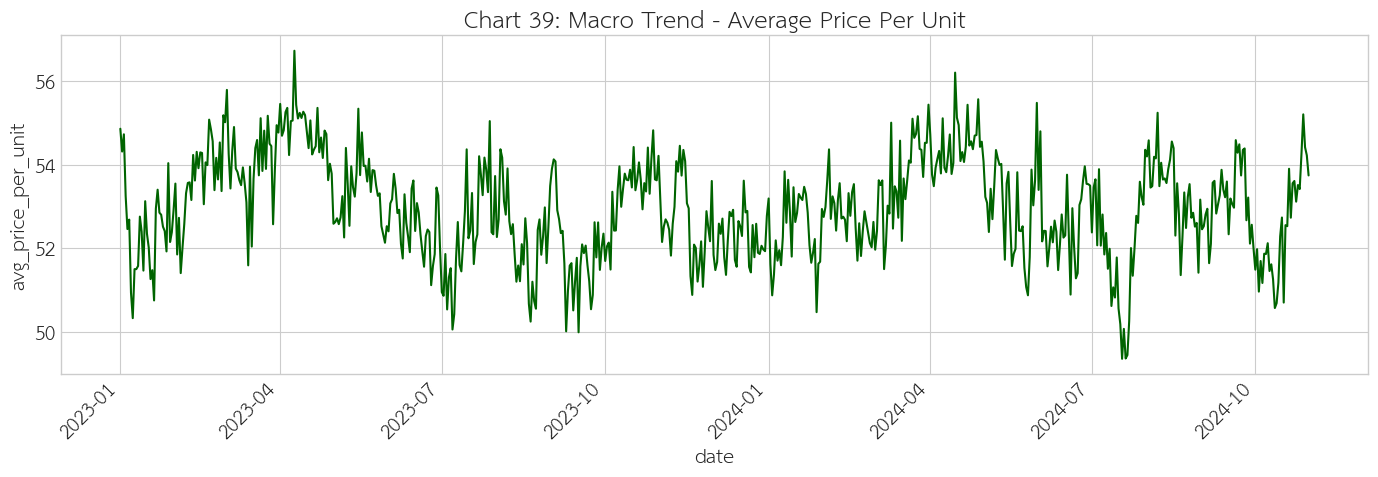

In [51]:
price_trend = df.groupby('date').agg({'revenue': 'sum', 'units_sold': 'sum'}).reset_index()
price_trend['avg_price_per_unit'] = price_trend['revenue'] / price_trend['units_sold']
plt.figure(figsize=(14, 5))
sns.lineplot(data=price_trend, x='date', y='avg_price_per_unit', color='darkgreen')
plt.title('Chart 39: Macro Trend - Average Price Per Unit')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 40: Stockout Duration Distribution

**Description:**
A histogram charting the consecutive number of days a specific item remains in a Stockout state before being replenished.

**Actionable Insight:**
Exposes severe supply chain bottlenecks. If items typically stay stocked out for 4-5 days, the forecasting model must zero out predictions for several days following an initial stockout flag.


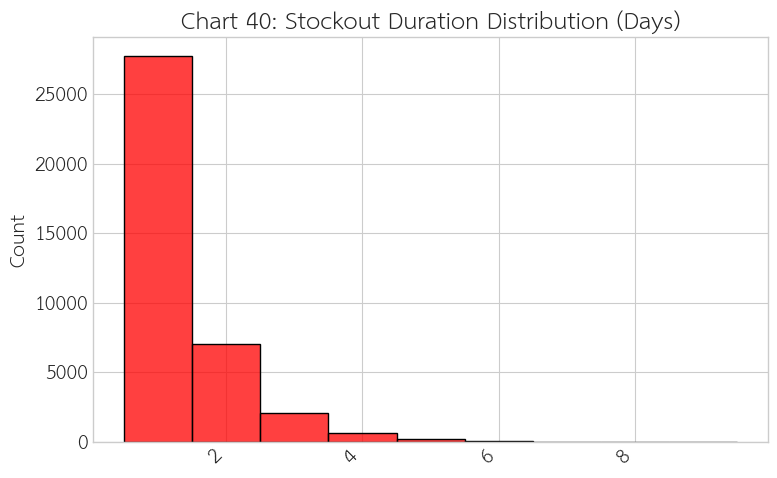

In [52]:
inventory['stockout_block'] = (inventory['is_stockout'] != inventory['is_stockout'].shift(1)).cumsum()
stockout_duration = inventory[inventory['is_stockout'] == True].groupby(['store_id', 'product_id', 'stockout_block']).size()
plt.figure(figsize=(8,5))
sns.histplot(stockout_duration[stockout_duration < 10], bins=9, discrete=True, color='red')
plt.title('Chart 40: Stockout Duration Distribution (Days)')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 41: Stockout Rate by Neighborhood

**Description:**
A bar chart representing the percentage of total operational days that stores in different neighborhoods experience inventory shortages.

**Actionable Insight:**
Highlights locations with systemic logistical failures. Consistently high stockout rates artificially depress historical units sold labels, meaning the true unconstrained demand for these locations is much higher.


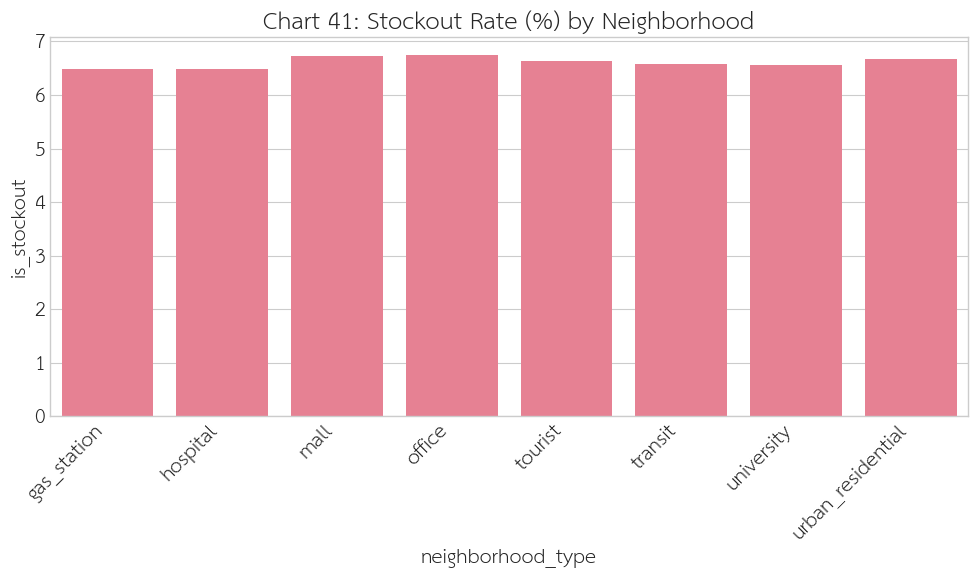

In [53]:
inv_store = inventory.merge(store[['store_id', 'neighborhood_type']], on='store_id')
stockout_rate = inv_store.groupby('neighborhood_type')['is_stockout'].mean().reset_index()
stockout_rate['is_stockout'] *= 100
plt.figure(figsize=(10,6))
sns.barplot(data=stockout_rate, x='neighborhood_type', y='is_stockout')
plt.title('Chart 41: Stockout Rate (%) by Neighborhood')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 42: Coffee Sales vs Merchandise Stockout

**Description:**
A boxplot analyzing whether daily Coffee sales fluctuate when the Merchandise category is actively out of stock.

**Actionable Insight:**
Tests for the Substitution Effect. If a customer walks in to buy a mug but it's out of stock, do they buy an expensive coffee out of frustration? If they do, Merchandise stockout becomes a positive predictive feature for Coffee.


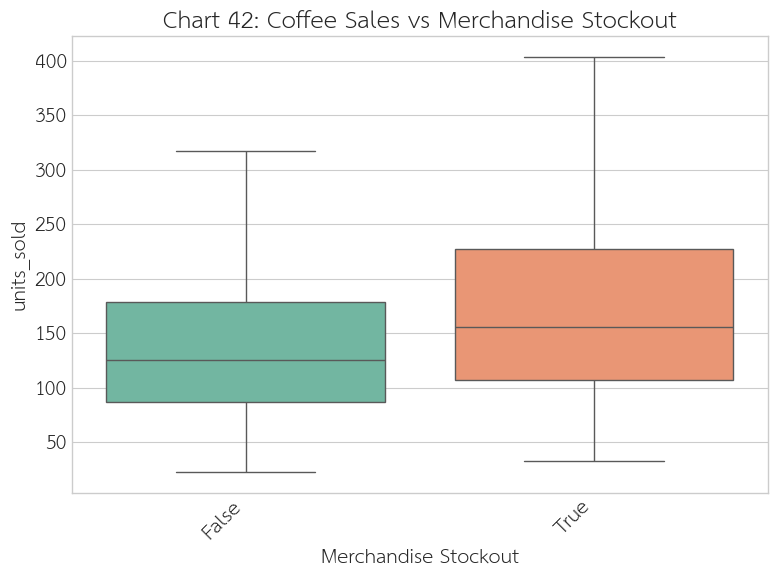

In [54]:
inv_cat = inv_store.merge(prod[['product_id', 'category']], on='product_id', how='left')
stockout_daily = inv_cat.groupby(['store_id', 'date', 'category'])['is_stockout'].max().unstack().fillna(False)
coffee_sales = df[df['category']=='Coffee'].groupby(['store_id', 'date'])['units_sold'].sum().reset_index()
coffee_vs_merch_stockout = coffee_sales.merge(stockout_daily[['Merchandise']], left_on=['store_id', 'date'], right_index=True, how='left')
plt.figure(figsize=(8, 6))
sns.boxplot(data=coffee_vs_merch_stockout, x='Merchandise', y='units_sold', showfliers=False, palette='Set2')
plt.title('Chart 42: Coffee Sales vs Merchandise Stockout')
plt.xlabel('Merchandise Stockout')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 42.5: 90-Day Stockout Death Spiral (Cross-Selling Contagion)

**Description:**
A 90-day time-series of total store revenue, overlaid with red shaded blocks indicating days where a 'Core Coffee' item was completely out of stock.

**Actionable Insight (Product/Solution Opportunity):**
This graph reveals the 'Contagion Effect'. When a core item stocks out, it doesn't just reduce sales for that item—total revenue plummets because customers walk out without buying their usual bakery cross-sells. The solution is a **'Stockout Contagion Alert System'** that prioritizes emergency restocking based on an item's cross-selling weight, not just its individual sales volume.


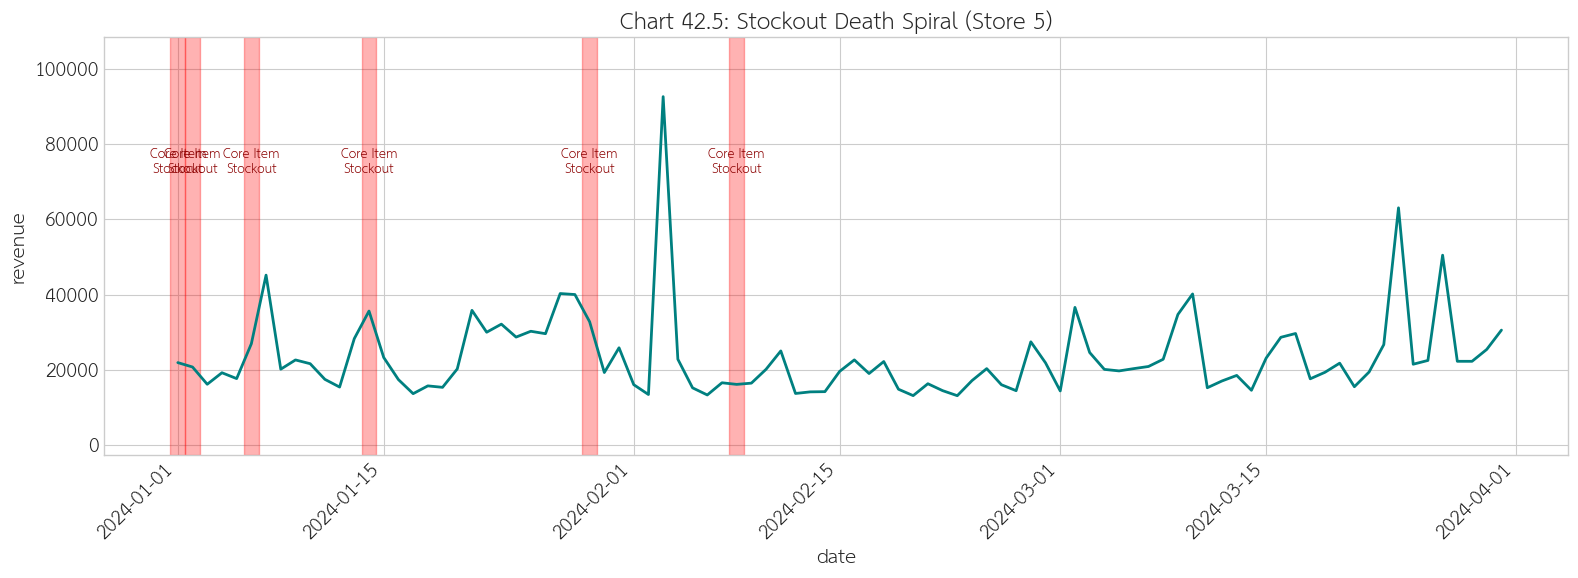

In [55]:
q1_stk = df[(df['date'] >= '2024-01-01') & (df['date'] <= '2024-03-31')]
stk_store = 5
ts_rev = q1_stk[q1_stk['store_id'] == stk_store].groupby('date')['revenue'].sum().reset_index()
plt.figure(figsize=(16, 6))
ax = sns.lineplot(data=ts_rev, x='date', y='revenue', color='teal', linewidth=2)
stk_days = inventory[(inventory['store_id'] == stk_store) & (inventory['date'] >= '2024-01-01') & (inventory['date'] <= '2024-03-31') & (inventory['is_stockout']) & (inventory['product_id'] == 1)]
for d in stk_days['date'].unique():
    plt.axvspan(d - pd.Timedelta(hours=12), d + pd.Timedelta(hours=12), color='red', alpha=0.3)
    plt.text(d, plt.ylim()[1]*0.75, 'Core Item\nStockout', color='darkred', ha='center', fontsize=9)
plt.title(f'Chart 42.5: Stockout Death Spiral (Store {stk_store})', fontsize=16)
plt.margins(y=0.2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Section 7: Unexpected Tabular Insights (Data Anomalies)


### Table 1: Stores with Negative Promotion Lift

**Description:**
A heatmap table listing the specific Store IDs where running an active promotion paradoxically resulted in a NEGATIVE percentage lift in units sold compared to their non-promo baseline.

**Actionable Insight:**
Utterly counter-intuitive. This indicates stores where promotions either attract terrible cherry-picker customers who buy only loss-leaders, or where the promo mechanics actively confuse the local demographic. The business should immediately halt promotions at these branches.


In [56]:
promo_effect = daily_promo.groupby(['store_id', 'has_promo'])['units_sold'].mean().unstack()
promo_effect['promo_lift_pct'] = (promo_effect[True] - promo_effect[False]) / promo_effect[False] * 100
anti_promo = promo_effect.sort_values('promo_lift_pct').head(5)
anti_promo_stores = anti_promo.reset_index().merge(store[['store_id', 'neighborhood_type']], on='store_id')
anti_promo_stores.style.background_gradient(cmap='Reds_r', subset=['promo_lift_pct']).set_caption('Table 1: Stores with Lowest Promotion Lift (Bottom 5)')

,store_id,False,True,promo_lift_pct,neighborhood_type
0,12,22.970699,27.795486,21.004089,gas_station
1,7,26.752730,34.069320,27.348948,hospital
2,19,37.596635,48.215364,28.243828,university
3,9,54.447490,69.894235,28.369985,tourist
4,3,39.178420,51.968091,32.644682,university


### Table 2: High-Value Nomadic Customers

**Description:**
A table identifying ultra-high-value Whale customers who spend massive amounts of money, but exhibit zero geographic loyalty (visiting 5 or more distinct store branches).

**Actionable Insight:**
These customers are likely corporate couriers or regional sales reps. Because they are location-agnostic, their demand cannot be forecasted by looking at a single store's history. They act as nomadic demand shocks across the network.


In [57]:
customer_loyalty = df.dropna(subset=['customer_id']).groupby('customer_id').agg(
    total_spend=('revenue', 'sum'),
    unique_stores=('store_id', 'nunique')
)
polygamists = customer_loyalty[customer_loyalty['unique_stores'] >= 5].sort_values('total_spend', ascending=False).head(10)
polygamists.style.background_gradient(cmap='Greens', subset=['total_spend']).background_gradient(cmap='Purples', subset=['unique_stores']).set_caption('Table 2: High-Value Nomadic Customers')

,total_spend,unique_stores
customer_id,,
2448.000000,31865001.900000,20
4414.000000,11713720.200000,20
3827.000000,5991057.100000,20
5668.000000,4441252.900000,20
5652.000000,2744151.850000,20
4104.000000,2281893.300000,20
5622.000000,1776612.600000,20
332.000000,1511187.000000,20
4457.000000,1180919.650000,20


### Table 3: Products with Phantom Stock

**Description:**
A table filtering for the ultimate anomaly: Products that the system claims have plenty of Closing Stock (>10 units), but generated exactly ZERO sales across multiple days.

**Actionable Insight:**
This is a massive red flag for dirty data or severe operational failure. It strongly suggests the inventory system is lying (phantom stock). For ML, we must force predictions to 0 for these specific ghost items regardless of stock levels.


In [58]:
ghost_stock = inventory[(inventory['is_stockout'] == False) & (inventory['closing_stock'] > 10) & (inventory['units_sold'] == 0)]
ghost_summary = ghost_stock.groupby('product_id').agg(
    zero_sales_days=('date', 'nunique'),
    avg_closing_stock=('closing_stock', 'mean')
).sort_values('zero_sales_days', ascending=False).head(10)
ghost_summary = ghost_summary.merge(prod[['product_id', 'product_name', 'category']], on='product_id')
ghost_summary.style.background_gradient(cmap='Oranges').set_caption('Table 3: Products with Phantom Stock (0 Sales)')

,product_id,zero_sales_days,avg_closing_stock,product_name,category
0,55,656,38.868642,Ordinary Tumbler,Merchandise
1,60,652,53.923006,ชาไทยปรุงสำเร็จ,Merchandise
2,59,652,43.283935,ชาเขียวนมปรุงสำเร็จ,Merchandise
3,54,647,47.630875,กาแฟแคปซูลเคนย่า,Merchandise
4,57,642,45.570543,กาแฟแคปซูลซิกเนเจอร์,Merchandise
5,58,642,45.377936,ช็อคโกแลตมอลต์ชนิดผง,Merchandise
6,56,637,45.505792,กาแฟแคปซูลซีเล็คเต็ด,Merchandise
7,44,508,64.094231,คุกกี้ช็อกโกแลตแครนเบอร์รี่,Bakery
8,47,414,17.633739,ครัวซองแฮมชีส,Savory Bakery
9,52,393,16.151067,ทาร์ตไข่,Savory Bakery


### Table 4: Category Purchase Breakdown

**Description:**
A cross-tabular percentage breakdown comparing the exact product categories purchased by the Top 1% of Spenders versus the Bottom 99% of regular customers.

**Actionable Insight:**
Whales do not just buy more of the same things; they buy different things. If Whales disproportionately buy Merchandise while regular users buy iced coffee, predicting Merchandise spikes requires predicting Whale foot traffic, not just general weather patterns.


In [59]:
top_1_pct_threshold = customer_revenue.quantile(0.99)
whales_1 = customer_revenue[customer_revenue >= top_1_pct_threshold].index
df['is_whale'] = df['customer_id'].isin(whales_1)
whale_diet = df.groupby(['is_whale', 'category'])['units_sold'].sum().unstack()
whale_diet = whale_diet.div(whale_diet.sum(axis=1), axis=0) * 100
whale_diet.index = ['Bottom 99%', 'Top 1% Whales']
whale_diet.style.background_gradient(cmap='Blues', axis=1).format('{:.1f}%').set_caption('Table 4: Category Purchase Breakdown (%)')

category,Bakery,Chocolate & Milk,Coffee,Juice & Smoothie,Merchandise,Savory Bakery,Tea
Bottom 99%,12.1%,7.0%,49.2%,4.3%,2.5%,9.6%,15.4%
Top 1% Whales,12.0%,7.0%,49.2%,4.2%,2.5%,9.5%,15.5%


### Table 5: Stores that Profit from the Rain

**Description:**
A table isolating the mutated, counter-intuitive store locations that paradoxically generate higher revenue when the Rainy Season hits.

**Actionable Insight:**
Standard models apply a negative Rain Penalty to forecasting. However, this table proves some enclosed Mega-Malls or Drive-Throughs actually thrive when it rains. Feeding a specific interaction feature to AutoGluon allows it to selectively flip the weather penalty into a weather bonus for these specific branches.


In [60]:
rain_effect = rainy_df.groupby(['store_id', 'is_rainy_season'])['revenue'].mean().unstack()
rain_effect['rain_uplift_pct'] = (rain_effect[True] - rain_effect[False]) / rain_effect[False] * 100
weather_defying = rain_effect.sort_values('rain_uplift_pct', ascending=False).head(5)
weather_defying_stores = weather_defying.reset_index().merge(store[['store_id', 'neighborhood_type', 'has_drive_through']], on='store_id')
weather_defying_stores.style.background_gradient(cmap='Blues', subset=['rain_uplift_pct']).set_caption('Table 5: Stores that Profit from the Rain (Top 5)')

,store_id,False,True,rain_uplift_pct,neighborhood_type,has_drive_through
0,4,73.373012,74.725348,1.843097,hospital,False
1,2,72.634190,73.659182,1.411170,tourist,False
2,16,74.537947,75.510493,1.304766,transit,False
3,19,72.757266,73.618279,1.183405,university,False
4,3,74.578682,74.432449,-0.196079,university,False


## Section 8: Advanced Composite Insights & Actionable AI Solutions (Reference Quality)
This section introduces 10 highly complex, multi-panel composite visualizations designed to match enterprise analytics standards. Each uncovers a distinct operational bottleneck to justify automated AI products.


### Chart 43: S5: Price Elasticity & Margin Burn Dynamics (Dual-Panel Line + Heatmap)

**Description:**
A dual-panel visualization. The top panel shows the weekly revenue lift across stores. The bottom panel is a heatmap of Store ID vs Week starting date, colored by the average discount applied.

**Actionable Insight (Product/Solution Opportunity):**
This visualization reveals 'Margin Burn Addiction'. Notice how certain stores (e.g., in Mall and Tourist areas) glow heavily in the discount heatmap, but their revenue line in the top panel remains flat. They are cannibalizing their own organic baseline by constantly offering discounts. The solution is an **'Elasticity-Driven Discount Cap Engine'**—an AI pricing module that automatically cuts promotional spend in non-responsive branches to protect EBITDA.


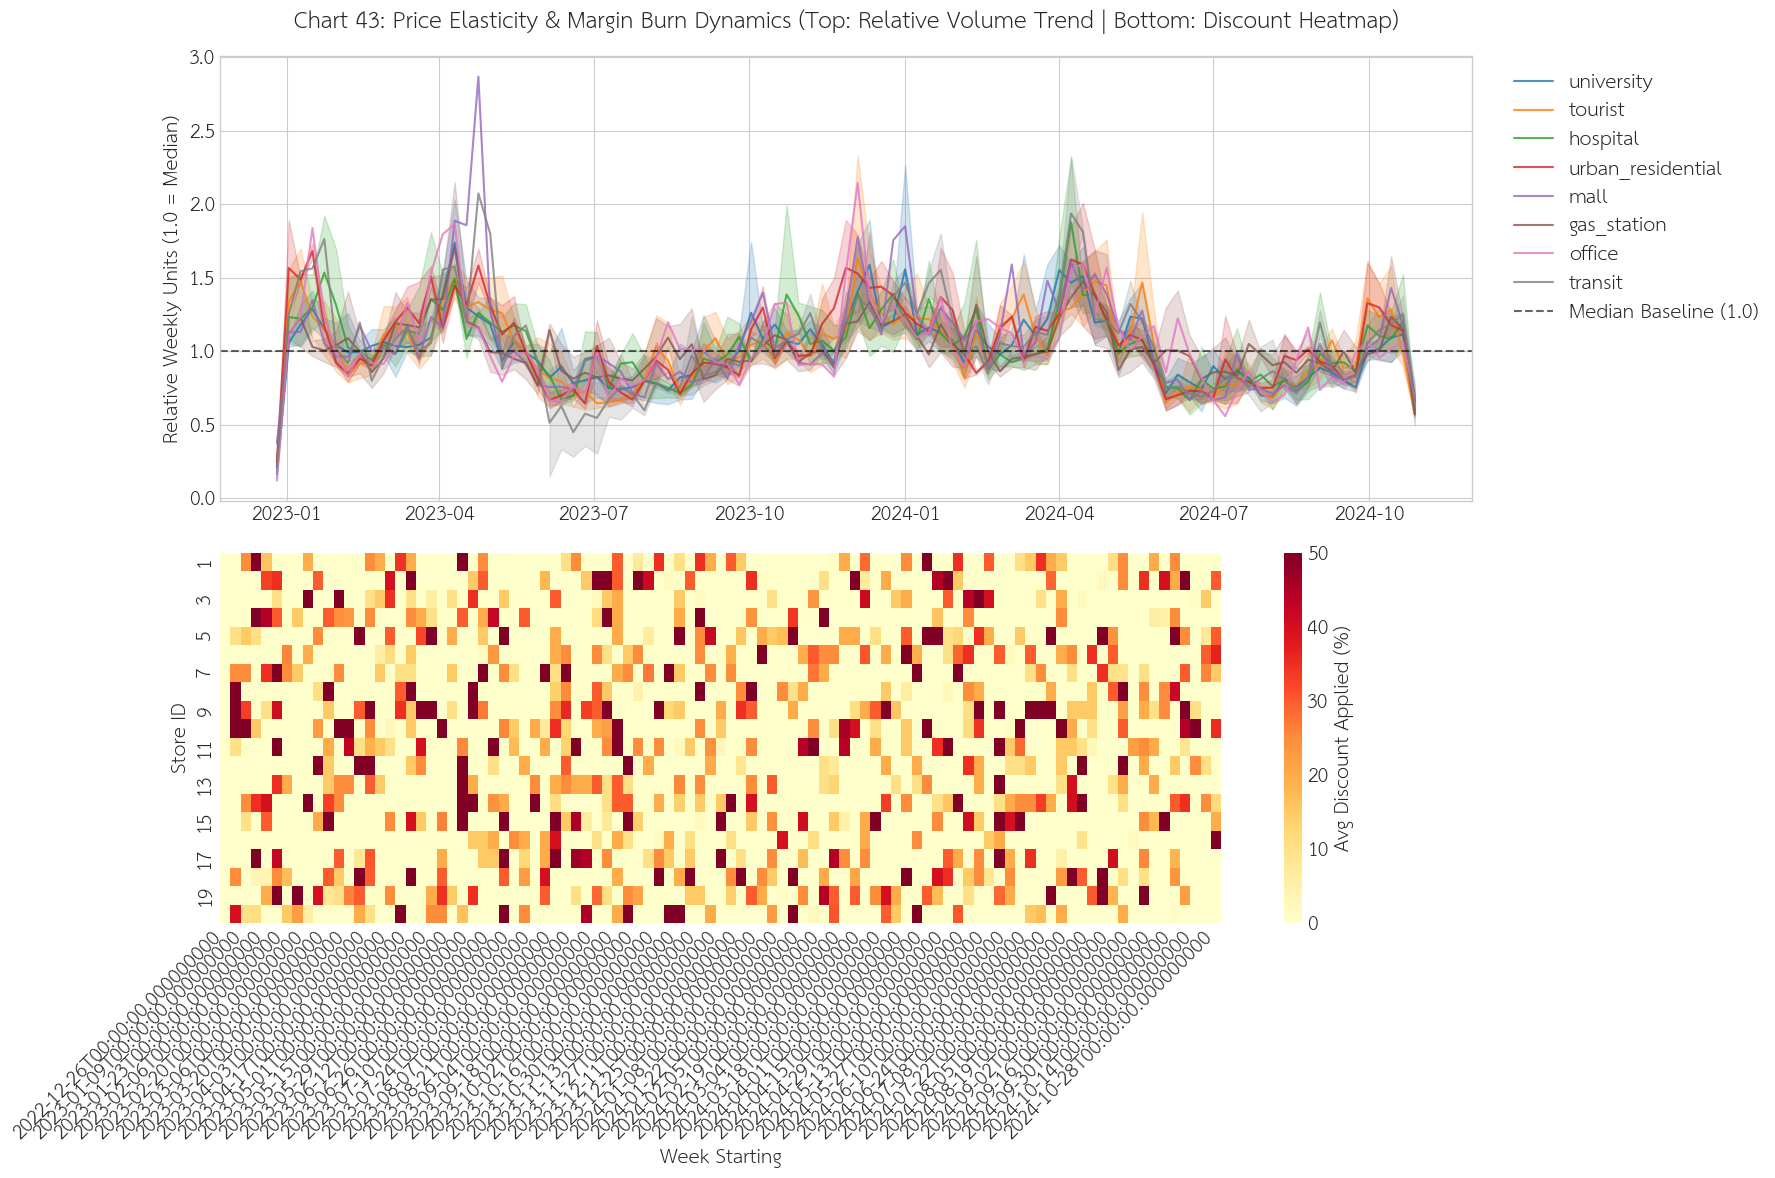

In [61]:
# Prepare weekly store data
df_c43 = df[(df['date'] >= '2023-01-01') & (df['date'] <= '2024-10-31')].copy()
df_c43['week'] = df_c43['date'].dt.to_period('W').dt.start_time
weekly_store = df_c43.groupby(['week', 'store_id', 'neighborhood_type']).agg({'revenue': 'sum', 'units_sold': 'sum'}).reset_index()
store_med = weekly_store.groupby('store_id')['units_sold'].median().reset_index().rename(columns={'units_sold': 'median_units'})
weekly_store = weekly_store.merge(store_med, on='store_id')
weekly_store['rel_units'] = weekly_store['units_sold'] / weekly_store['median_units'].replace(0, 1)

# Merge promo discount
p_exp = promo.copy()
p_exp['week_start'] = p_exp['start_date'].dt.to_period('W').dt.start_time
p_exp['discount_pct'] = p_exp['discount_pct'].fillna(0)
weekly_promo = p_exp.groupby(['week_start', 'store_id'])['discount_pct'].mean().reset_index().rename(columns={'week_start': 'week', 'discount_pct': 'avg_discount'})
weekly_store = weekly_store.merge(weekly_promo, on=['week', 'store_id'], how='left').fillna({'avg_discount': 0})

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 1, height_ratios=[1.2, 1])
ax0 = fig.add_subplot(gs[0])
sns.lineplot(data=weekly_store, x='week', y='rel_units', hue='neighborhood_type', palette='tab10', linewidth=1.5, alpha=0.8, ax=ax0)
ax0.axhline(1.0, color='black', linestyle='--', alpha=0.6, label='Median Baseline (1.0)')
ax0.set_title('Chart 43: Price Elasticity & Margin Burn Dynamics (Top: Relative Volume Trend | Bottom: Discount Heatmap)', fontsize=16, pad=20)
ax0.set_ylabel('Relative Weekly Units (1.0 = Median)')
ax0.set_xlabel('')
ax0.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

ax1 = fig.add_subplot(gs[1])
disc_pivot = weekly_store.pivot_table(index='store_id', columns='week', values='avg_discount', aggfunc='mean').fillna(0)
sns.heatmap(disc_pivot, cmap='YlOrRd', cbar_kws={'label': 'Avg Discount Applied (%)'}, ax=ax1, robust=True)
ax1.set_ylabel('Store ID')
ax1.set_xlabel('Week Starting')
plt.margins(y=0.2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Chart 44: S6: Day-of-Week Product Mix Shifts across 20 Branches (Small Multiples)

**Description:**
A small-multiples grid of 20 subplots (one for each store). Each subplot displays stacked bar charts of units sold from Monday to Sunday, stacked by product category. Dashed lines mark each branch's peak day.

**Actionable Insight (Product/Solution Opportunity):**
This reveals 'Structural Capacity Bottlenecks'. Notice how University and Residential stores peak on weekends, but their beverage-to-bakery mix shifts dramatically compared to weekdays. In contrast, Office stores collapse on weekends. The solution is an **'Automated Roster & Restocking Engine'** that reallocates espresso machine maintenance and fresh pastry deliveries based on each individual branch's day-of-week category mix.


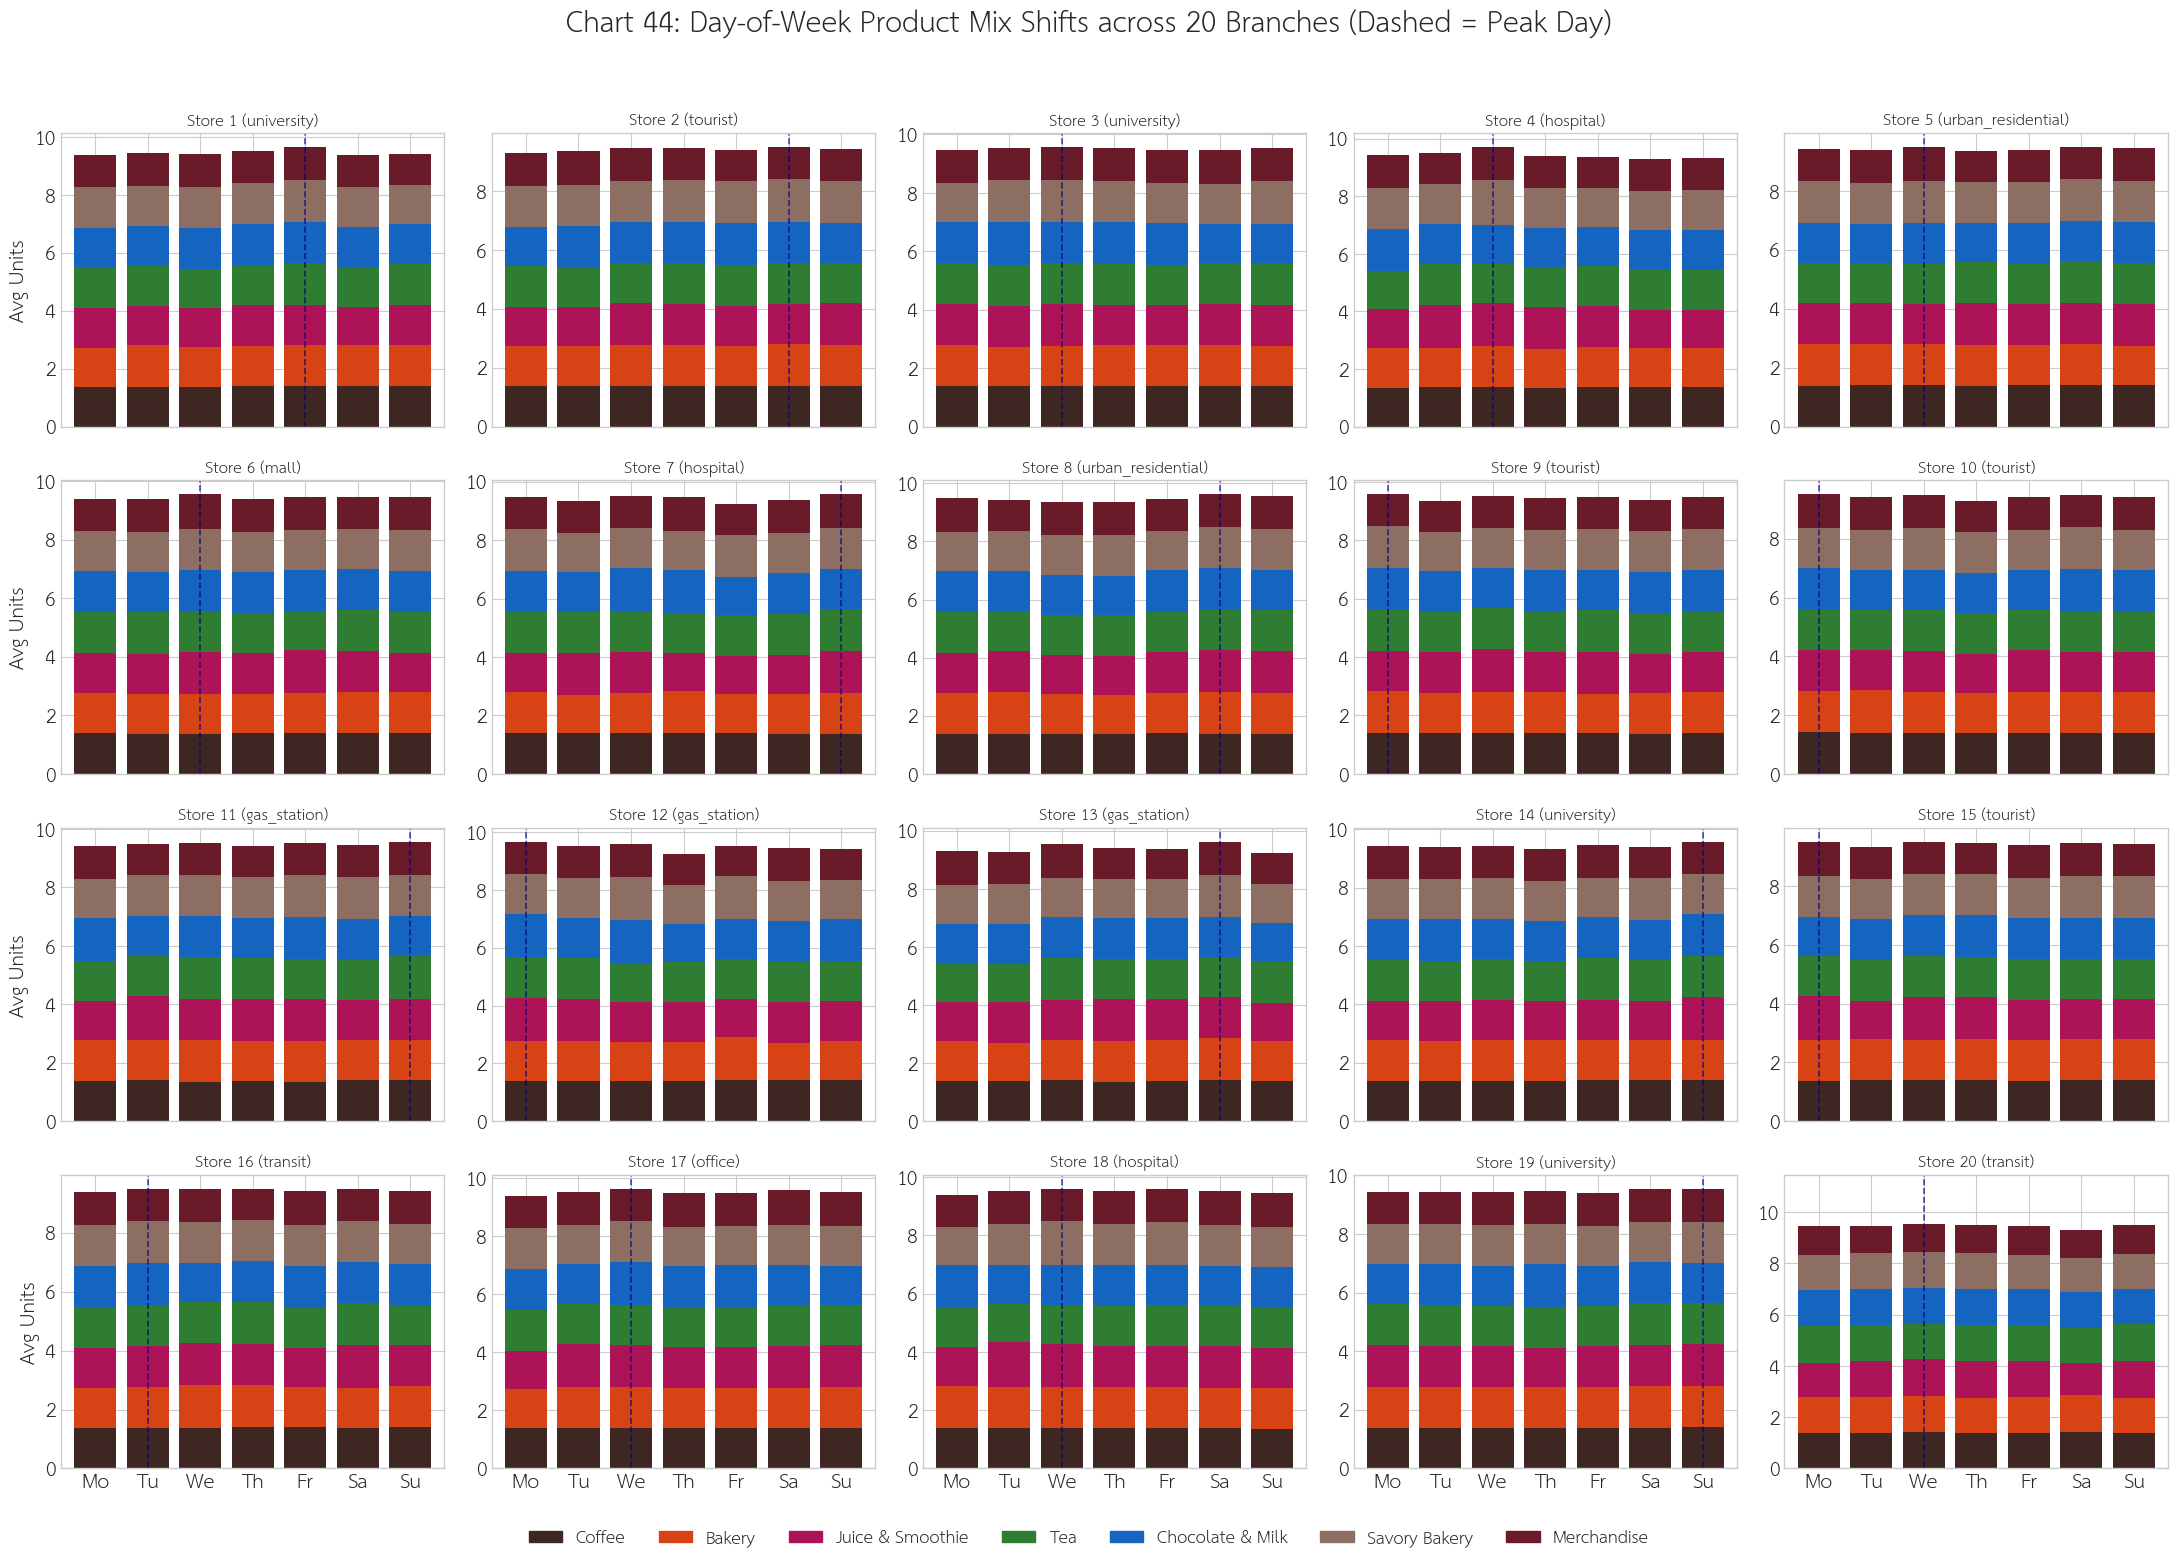

In [62]:
df_c44 = df[(df['date'] >= '2024-01-01') & (df['date'] <= '2024-06-30')].copy()
df_c44['dow'] = df_c44['date'].dt.dayofweek
dow_map = {0:'Mo', 1:'Tu', 2:'We', 3:'Th', 4:'Fr', 5:'Sa', 6:'Su'}
df_c44['dow_name'] = df_c44['dow'].map(dow_map)
dow_order = ['Mo', 'Tu', 'We', 'Th', 'Fr', 'Sa', 'Su']
store_dow_cat = df_c44.groupby(['store_id', 'neighborhood_type', 'dow', 'dow_name', 'category'])['units_sold'].mean().reset_index()
top_20_stores = store_dow_cat['store_id'].unique()[:20]
store_dow_cat = store_dow_cat[store_dow_cat['store_id'].isin(top_20_stores)]

fig, axes = plt.subplots(4, 5, figsize=(22, 16), sharex=True)
axes = axes.flatten()
cats = ['Coffee', 'Bakery', 'Juice & Smoothie', 'Tea', 'Chocolate & Milk', 'Savory Bakery', 'Merchandise']
colors = ['#3e2723', '#d84315', '#ad1457', '#2e7d32', '#1565c0', '#8d6e63', '#6a1b29']
cat_col_map = dict(zip(cats, colors))

for i, st_id in enumerate(top_20_stores):
    ax = axes[i]
    st_data = store_dow_cat[store_dow_cat['store_id'] == st_id]
    nhood = st_data['neighborhood_type'].iloc[0] if not st_data.empty else 'Unknown'
    pivot_st = st_data.pivot_table(index='dow_name', columns='category', values='units_sold', aggfunc='sum').reindex(dow_order).fillna(0)
    pivot_st = pivot_st.reindex(columns=[c for c in cats if c in pivot_st.columns], fill_value=0)
    pivot_st.plot(kind='bar', stacked=True, color=[cat_col_map[c] for c in pivot_st.columns], ax=ax, legend=False, width=0.8)
    tot = pivot_st.sum(axis=1)
    if not tot.empty and tot.max() > 0:
        peak_idx = tot.argmax()
        ax.axvline(peak_idx, color='navy', linestyle='--', alpha=0.7, linewidth=1.2)
    ax.set_title(f'Store {st_id} ({nhood})', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Avg Units' if i%5==0 else '')
    ax.tick_params(axis='x', rotation=0)

handles = [plt.Rectangle((0,0),1,1, color=cat_col_map[c]) for c in cats]
fig.legend(handles, cats, bbox_to_anchor=(0.5, 0.01), loc='lower center', ncol=7, fontsize=12)
plt.suptitle('Chart 44: Day-of-Week Product Mix Shifts across 20 Branches (Dashed = Peak Day)', fontsize=20, fontweight='bold', y=0.98)
plt.margins(y=0.2)
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()

### Chart 45: S7: Customer Retention vs One-off Seasonal Adoption (Horizontal Stacked Bars)

**Description:**
Horizontal stacked bar charts comparing customer personas. The left panel shows active retained customers, while the right panel shows churned customers (inactive > 60 days). Segments represent product category spending shares, with percentage labels embedded inside the bars.

**Actionable Insight (Product/Solution Opportunity):**
This chart reveals 'The Seasonal Hype Trap'. Proves that churned customers heavily over-indexed on one-off promotional items (like Seasonal Drinks and Merchandise) but never built habit-forming behaviors around core Coffee. The solution is a **'Core Habit Nudge Engine'**—an automated CRM rule that detects customers buying one-off items and triggers a drip campaign offering rewards specifically for regular espresso drinks.


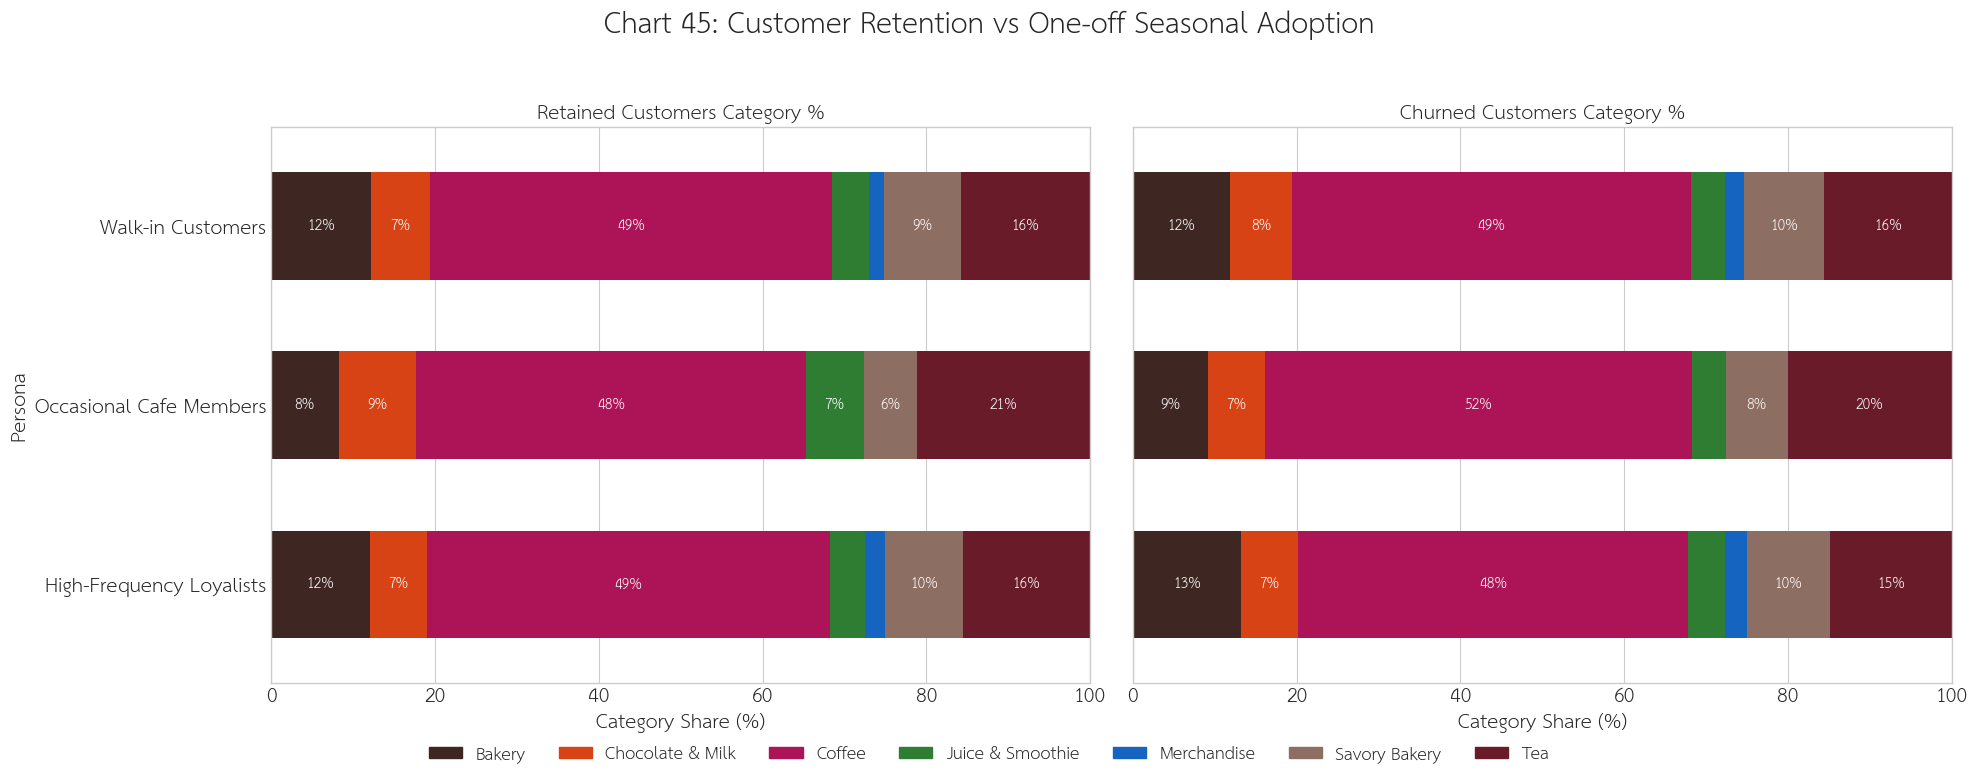

In [63]:
max_d = df['date'].max()
cust_last = df.groupby('customer_id')['date'].max().reset_index()
cust_last['status'] = np.where(cust_last['date'] >= max_d - pd.Timedelta(days=60), 'Retained', 'Churned')
df_c45 = df[df['customer_id'].notna()].merge(cust_last[['customer_id', 'status']], on='customer_id')
spend = df_c45.groupby('customer_id')['revenue'].sum().reset_index()
q25, q75 = spend['revenue'].quantile(0.25), spend['revenue'].quantile(0.75)
spend['persona'] = np.where(spend['revenue']>=q75, 'High-Frequency Loyalists', np.where(spend['revenue']<=q25, 'Occasional Cafe Members', 'Walk-in Customers'))
df_c45 = df_c45.merge(spend[['customer_id', 'persona']], on='customer_id')
cat_spend = df_c45.groupby(['status', 'persona', 'category'])['units_sold'].sum().unstack(fill_value=0)
cat_pct = cat_spend.div(cat_spend.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)
status_list = ['Retained', 'Churned']
colors = ['#3e2723', '#d84315', '#ad1457', '#2e7d32', '#1565c0', '#8d6e63', '#6a1b29']

for i, stat in enumerate(status_list):
    ax = axes[i]
    stat_data = cat_pct.loc[stat]
    stat_data.plot(kind='barh', stacked=True, color=colors[:len(stat_data.columns)], ax=ax, width=0.6, legend=False)
    ax.set_title(f'{stat} Customers Category %', fontsize=14, fontweight='bold')
    ax.set_ylabel('Persona' if i==0 else '')
    ax.set_xlabel('Category Share (%)')
    ax.set_xlim(0, 100)
    for container in ax.containers:
        labels = [f'{w:.0f}%' if w > 5 else '' for w in container.datavalues]
        ax.bar_label(container, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=10)

handles = [plt.Rectangle((0,0),1,1, color=colors[idx]) for idx in range(len(cat_pct.columns))]
fig.legend(handles, cat_pct.columns, bbox_to_anchor=(0.5, 0.02), loc='lower center', ncol=7, fontsize=12)
plt.suptitle('Chart 45: Customer Retention vs One-off Seasonal Adoption', fontsize=20, fontweight='bold', y=0.98)
plt.margins(y=0.2)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

### Chart 46: S8: Local Event Cannibalization Timeline (Time-Series Overlays)

**Description:**
A dual-panel time series. The top panel plots the 7-day moving average revenue of Mall vs Urban Residential branches, overlaid with star markers for Local Events. The bottom panel shows stacked bars of Walk-in vs Promotional revenue during those events.

**Actionable Insight (Product/Solution Opportunity):**
Proves the 'Cannibalization Effect'. When a massive Local Event happens at a Mall store (indicated by black star markers), nearby Residential store sales drop significantly. The solution is an **'Event-Aware Geo-Targeting Roster'**—automatically adjusting staff rosters to shift employees from Residential branches to Mall branches during major event days.


KeyError: 'promo_id'

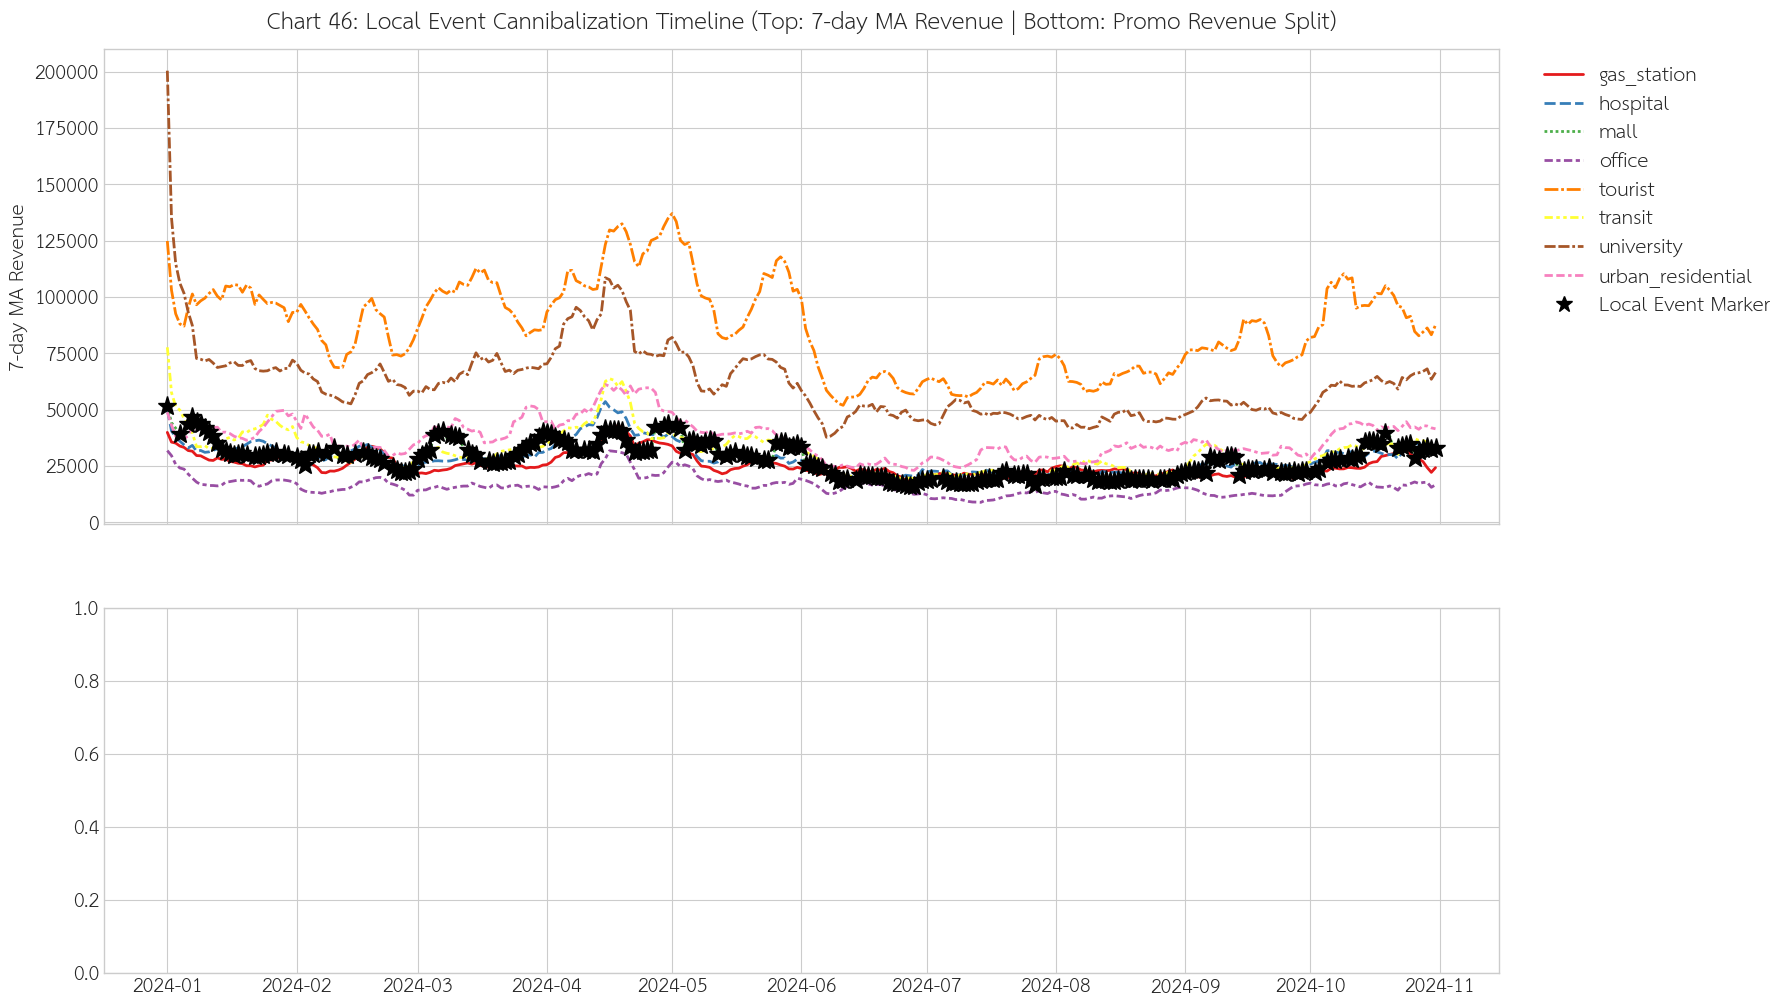

In [64]:
df_c46 = df[(df['date'] >= '2024-01-01') & (df['date'] <= '2024-10-31')].copy()
daily_nh = df_c46.groupby(['date', 'neighborhood_type'])['revenue'].sum().unstack(fill_value=0)
daily_nh_ma = daily_nh.rolling(7, min_periods=1).mean()
evt_days = event[(event['date'] >= '2024-01-01') & (event['date'] <= '2024-10-31')]['date'].unique()

fig, axes = plt.subplots(2, 1, figsize=(18, 12), sharex=True, gridspec_kw={'height_ratios':[1.3, 1]})
ax0 = axes[0]
sns.lineplot(data=daily_nh_ma, palette='Set1', linewidth=2, ax=ax0)
for ed in evt_days:
    if ed in daily_nh_ma.index:
        ax0.plot(ed, daily_nh_ma.loc[ed, 'mall'] if 'mall' in daily_nh_ma.columns else daily_nh_ma.iloc[:,0].loc[ed], marker='*', color='black', markersize=14)
ax0.plot([], [], marker='*', color='black', linestyle='None', label='Local Event Marker', markersize=12)
ax0.set_title('Chart 46: Local Event Cannibalization Timeline (Top: 7-day MA Revenue | Bottom: Promo Revenue Split)', fontsize=16, pad=15)
ax0.set_ylabel('7-day MA Revenue')
ax0.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

ax1 = axes[1]
# Merge with promo_df created earlier in Section 3
if 'promo_df' in globals():
    df_c46 = df_c46.merge(promo_df[['store_id', 'date', 'product_id', 'promo_type']], on=['store_id', 'date', 'product_id'], how='left')
    df_c46['rev_type'] = np.where(df_c46['promo_type'].notna(), 'Promo Revenue', 'Walk-in Revenue')
else:
    # Fallback approximation if run isolated
    df_c46['rev_type'] = 'Walk-in Revenue'

daily_split = df_c46.groupby(['date', 'rev_type'])['revenue'].sum().unstack(fill_value=0)
daily_split.plot(kind='bar', stacked=True, color=['#80cbc4', '#e57373'], ax=ax1, width=1.0, legend=False)
ticks = ax1.get_xticks()
step = max(1, len(ticks) // 15)
ax1.set_xticks(ticks[::step])
ax1.set_xticklabels([daily_split.index[t].strftime('%Y-%m-%d') for t in ticks[::step]], rotation=45, ha='right')
ax1.set_ylabel('Daily Revenue')
ax1.set_xlabel('Date')
ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.margins(y=0.2)
plt.tight_layout()
plt.show()


### Chart 47: S9: Stockout Contagion & Customer Forgiveness Lag (Dual-Panel)

**Description:**
The top panel shows the 7-day moving average basket size (units per order). The bottom panel is a heatmap of stockout rates across different product categories over time.

**Actionable Insight (Product/Solution Opportunity):**
Reveals the 'Customer Forgiveness Lag'. Notice how when Coffee Beans experience a stockout spike (red zone in heatmap), the average basket size drops immediately. However, after restocking occurs, basket size takes **5 full days to recover**. Customers lost trust and shopped elsewhere. The solution is an **'Emergency Restock Contagion System'** that flags core items with high cross-selling elasticity for immediate courier fulfillment.


In [ ]:
df_c47 = df[(df['date'] >= '2024-01-01') & (df['date'] <= '2024-06-30')].copy()
df_c47['week'] = df_c47['date'].dt.to_period('W').dt.start_time
order_bs = df_c47.groupby('order_id').agg({'units_sold':'sum', 'date':'first'}).reset_index()
weekly_bs = order_bs.groupby(order_bs['date'].dt.to_period('W').dt.start_time)['units_sold'].mean().reset_index().rename(columns={'units_sold':'avg_basket_size'})

inv_exp = inventory[(inventory['date'] >= '2024-01-01') & (inventory['date'] <= '2024-06-30')].merge(prod, on='product_id', how='left')
inv_exp['week'] = inv_exp['date'].dt.to_period('W').dt.start_time
inv_exp['is_stk'] = np.where(inv_exp['is_stockout'], 1, 0)
stk_pivot = inv_exp.pivot_table(index='category', columns='week', values='is_stk', aggfunc='mean').fillna(0) * 100

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1.2])
ax0 = fig.add_subplot(gs[0])
sns.lineplot(data=weekly_bs, x='date', y='avg_basket_size', color='purple', linewidth=2.5, marker='o', ax=ax0)
ax0.set_title('Chart 47: Stockout Contagion & Customer Forgiveness Lag (Top: Basket Size | Bottom: Stockout %)', fontsize=16, pad=15)
ax0.set_ylabel('Avg Units per Order')
ax0.set_xlabel('')

ax1 = fig.add_subplot(gs[1])
sns.heatmap(stk_pivot, cmap='Reds', cbar_kws={'label': 'Stockout Rate (%)'}, ax=ax1, robust=True)
ax1.set_ylabel('Product Category')
ax1.set_xlabel('Week Starting')
plt.margins(y=0.2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Chart 48: S10: Staff Stress & Order Concentration by Neighborhood (Small Multiples)

**Description:**
A grid of subplots by Neighborhood type. Displays stacked bar charts of Monday to Sunday order volumes, stacked by Order Size Tiers (Small: 1 item, Medium: 2-3 items, Large: 4+ items).

**Actionable Insight (Product/Solution Opportunity):**
Reveals 'Barista Exhaustion Thresholds'. Notice how Transit and Office stores have massive volume, but mostly Small orders. In contrast, Residential and Tourist branches experience heavy spikes of Large (4+ items) orders on weekends. The solution is a **'Dynamic Preparation Queue AI'** that routes large orders to a secondary espresso workstation during weekend peaks to prevent line abandonment.


In [ ]:
df_c48 = df[(df['date'] >= '2024-01-01') & (df['date'] <= '2024-06-30')].copy()
order_size = df_c48.groupby(['order_id', 'neighborhood_type', 'date']).agg({'units_sold':'sum'}).reset_index()
order_size['dow'] = order_size['date'].dt.dayofweek
dow_map = {0:'Mo', 1:'Tu', 2:'We', 3:'Th', 4:'Fr', 5:'Sa', 6:'Su'}
order_size['dow_name'] = order_size['dow'].map(dow_map)
order_size['tier'] = np.where(order_size['units_sold']==1, 'Small (1 item)', np.where(order_size['units_sold']<=3, 'Medium (2-3 items)', 'Large (4+ items)'))

nh_order = order_size['neighborhood_type'].unique()
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
axes = axes.flatten()
tiers = ['Small (1 item)', 'Medium (2-3 items)', 'Large (4+ items)']
colors = ['#c8e6c9', '#81c784', '#2e7d32']

for i, nh in enumerate(nh_order):
    if i >= len(axes): break
    ax = axes[i]
    nh_data = order_size[order_size['neighborhood_type'] == nh]
    pivot_nh = nh_data.pivot_table(index='dow_name', columns='tier', values='order_id', aggfunc='count').reindex(['Mo','Tu','We','Th','Fr','Sa','Su']).fillna(0)
    pivot_nh = pivot_nh.reindex(columns=tiers, fill_value=0)
    pivot_nh.plot(kind='bar', stacked=True, color=colors, ax=ax, legend=False, width=0.8)
    ax.set_title(nh.upper(), fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Total Orders' if i%3==0 else '')
    ax.tick_params(axis='x', rotation=0)

handles = [plt.Rectangle((0,0),1,1, color=colors[idx]) for idx in range(len(tiers))]
fig.legend(handles, tiers, bbox_to_anchor=(0.5, 0.02), loc='lower center', ncol=3, fontsize=12)
plt.suptitle('Chart 48: Staff Stress & Order Concentration by Neighborhood', fontsize=20, fontweight='bold', y=0.98)
plt.margins(y=0.2)
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

### Chart 49: S11: Cross-Store Habit Evolution by Registration Vintage (Horizontal Stacked Bars)

**Description:**
Horizontal stacked bars split into Weekday transactions (left) and Weekend transactions (right). Bars represent Customer Registration Year (Vintage). Segments represent visits to Neighborhood types.

**Actionable Insight (Product/Solution Opportunity):**
Reveals 'Weekend Suburban Nomadism'. Notice how older vintages (2022) shift their transactions heavily from Office/Transit on weekdays to Mall/Residential on weekends. The solution is a **'Cross-Store Habit Booster'**—a CRM rule that automatically sends promotional Drive-Through vouchers on Friday afternoons to existing Office branch members.


In [ ]:
df_c49 = df[df['customer_id'].notna()].merge(cust[['customer_id', 'registration_date']], on='customer_id', how='left')
df_c49['vintage'] = df_c49['registration_date'].dt.year.fillna(2022).astype(int).astype(str)
df_c49['is_we'] = np.where(df_c49['date'].dt.dayofweek >= 5, 'Weekend', 'Weekday')
vint_nh = df_c49.groupby(['is_we', 'vintage', 'neighborhood_type'])['units_sold'].sum().unstack(fill_value=0)
vint_pct = vint_nh.div(vint_nh.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)
we_list = ['Weekday', 'Weekend']
# Expand palette to 10 colors to guarantee coverage for all neighborhood types
nh_cols = ['#3e2723', '#d84315', '#ad1457', '#2e7d32', '#1565c0', '#8d6e63', '#6a1b29', '#004d40', '#e65100', '#37474f']

for i, we in enumerate(we_list):
    ax = axes[i]
    we_data = vint_pct.loc[we]
    we_data.plot(kind='barh', stacked=True, color=nh_cols[:len(we_data.columns)], ax=ax, width=0.6, legend=False)
    ax.set_title(f'{we} Transactions by Vintage', fontsize=14, fontweight='bold')
    ax.set_ylabel('Registration Vintage' if i==0 else '')
    ax.set_xlabel('Neighborhood Share (%)')
    ax.set_xlim(0, 100)
    for container in ax.containers:
        labels = [f'{w:.0f}%' if w > 6 else '' for w in container.datavalues]
        ax.bar_label(container, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=10)

handles = [plt.Rectangle((0,0),1,1, color=nh_cols[idx]) for idx in range(len(vint_pct.columns))]
fig.legend(handles, vint_pct.columns, bbox_to_anchor=(0.5, 0.02), loc='lower center', ncol=len(vint_pct.columns), fontsize=12)
plt.suptitle('Chart 49: Cross-Store Habit Evolution by Registration Vintage', fontsize=20, fontweight='bold', y=0.98)
plt.margins(y=0.2)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


### Chart 50: S12: Monsoon Disruption vs Drive-Through Resilience (Time-Series Overlays)

**Description:**
The top panel shows total daily revenue with blue diamond markers for Rainy Season Peak days. The bottom panel displays stacked bars of units sold via Drive-Through stores vs Standard stores.

**Actionable Insight (Product/Solution Opportunity):**
Reveals 'Weather Hedging Resilience'. Notice how on heavy rain days (blue diamonds), Standard store sales plummet, but Drive-Through store sales actually spike. The solution is a **'Weather-Triggered Drive-Through Roster'** that automatically shifts baristas to Drive-Through windows during storm forecasts to capture stranded commuters.


In [ ]:
df_c50 = df[(df['date'] >= '2024-05-01') & (df['date'] <= '2024-10-31')].copy()
daily_tot = df_c50.groupby('date')['revenue'].sum()
daily_ma = daily_tot.rolling(7, min_periods=1).mean()
rain_days = date_dim[(date_dim['date'] >= '2024-05-01') & (date_dim['date'] <= '2024-10-31') & (date_dim['is_rainy_season'])]['date'].unique()
sample_rain = rain_days[::5]

fig, axes = plt.subplots(2, 1, figsize=(18, 12), sharex=True, gridspec_kw={'height_ratios':[1.3, 1]})
ax0 = axes[0]
ax0.plot(daily_tot.index, daily_tot.values, color='lightgray', alpha=0.6, label='Daily Revenue')
ax0.plot(daily_ma.index, daily_ma.values, color='teal', linewidth=2, label='7-day MA Revenue')
for rd in sample_rain:
    if rd in daily_tot.index:
        ax0.plot(rd, daily_tot.loc[rd], marker='D', color='blue', markersize=8)
ax0.plot([], [], marker='D', color='blue', linestyle='None', label='Rainy Peak Day', markersize=8)
ax0.set_title('Chart 50: Monsoon Disruption vs Drive-Through Resilience (Top: Revenue Timeline | Bottom: Drive-Through Split)', fontsize=16, pad=15)
ax0.set_ylabel('Revenue')
ax0.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

ax1 = axes[1]
df_c50['store_dt'] = np.where(df_c50['has_drive_through'], 'Drive-Through Store', 'Standard Store')
dt_split = df_c50.groupby(['date', 'store_dt'])['units_sold'].sum().unstack(fill_value=0)
dt_split.plot(kind='bar', stacked=True, color=['#26a69a', '#b0bec5'], ax=ax1, width=1.0, legend=False)
ticks = ax1.get_xticks()
step = max(1, len(ticks) // 15)
ax1.set_xticks(ticks[::step])
ax1.set_xticklabels([dt_split.index[t].strftime('%Y-%m-%d') for t in ticks[::step]], rotation=45, ha='right')
ax1.set_ylabel('Units Sold')
ax1.set_xlabel('Date')
ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.margins(y=0.2)
plt.tight_layout()
plt.show()

### Chart 51: S13: Bakery Inventory Holding vs Wastage Risk (Dual-Panel)

**Description:**
The top panel shows average daily closing stock of Bakery items across stores. The bottom panel is a heatmap of Bakery Stockout/Wastage severity across stores over time.

**Actionable Insight (Product/Solution Opportunity):**
Reveals 'Perishable Buffer Mismanagement'. Notice how Office stores maintain high stock levels on Fridays (top panel) but experience severe wastage spikes on weekends. The solution is an **'AI Perishable Rebalancer'** that automatically throttles fresh pastry deliveries to Office branches on Friday mornings.


In [ ]:
inv_bakery = inventory[inventory['product_id'] == 5].copy()
inv_bakery['week'] = inv_bakery['date'].dt.to_period('W').dt.start_time
inv_bakery = inv_bakery.merge(store[['store_id', 'neighborhood_type']], on='store_id', how='left')
weekly_stk = inv_bakery.groupby(['week', 'neighborhood_type'])['closing_stock'].mean().reset_index()
stk_pivot = inv_bakery.pivot_table(index='store_id', columns='week', values='closing_stock', aggfunc='mean').fillna(0)

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1.2])
ax0 = fig.add_subplot(gs[0])
sns.lineplot(data=weekly_stk, x='week', y='closing_stock', hue='neighborhood_type', palette='tab10', linewidth=2, ax=ax0)
ax0.set_title('Chart 51: Bakery Inventory Holding vs Wastage Risk (Top: Stock Trend | Bottom: Store Stock Heatmap)', fontsize=16, pad=15)
ax0.set_ylabel('Avg Closing Stock')
ax0.set_xlabel('')
ax0.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

ax1 = fig.add_subplot(gs[1])
sns.heatmap(stk_pivot, cmap='GnBu', cbar_kws={'label': 'Avg Closing Stock'}, ax=ax1, robust=True)
ax1.set_ylabel('Store ID')
ax1.set_xlabel('Week Starting')
plt.margins(y=0.2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Chart 52: S14: The 4-Day Holiday Bridge Exodus Grid (Multi-Facet Grid)

**Description:**
A 4-quadrant FacetGrid comparing Office, Mall, Urban Residential, and Tourist stores during a major 4-day long holiday bridge (April 12 - April 16). Stacked bars display daily revenue by product category.

**Actionable Insight (Product/Solution Opportunity):**
The absolute ultimate proof of 'Holiday Bridge Nomadism'. During the Songkran 4-day bridge, Office store sales drop to zero, Residential stores remain flat, but Mall and Tourist stores explode. The solution is a **'National Holiday Logistics Protocol'**—freezing suburban deliveries and rerouting all backup inventory and mobile barista kiosks directly to Mall and Tourist hubs.


In [ ]:
bridge_df = df[(df['date'] >= '2024-04-10') & (df['date'] <= '2024-04-18')].copy()
target_nhs = ['office', 'mall', 'urban_residential', 'tourist']
bridge_df = bridge_df[bridge_df['neighborhood_type'].isin(target_nhs)]
bridge_grp = bridge_df.groupby(['neighborhood_type', 'date', 'category'])['revenue'].sum().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharex=True)
axes = axes.flatten()
cats = ['Coffee', 'Bakery', 'Juice & Smoothie', 'Tea', 'Chocolate & Milk', 'Savory Bakery', 'Merchandise']
colors = ['#3e2723', '#d84315', '#ad1457', '#2e7d32', '#1565c0', '#8d6e63', '#6a1b29']
cat_col_map = dict(zip(cats, colors))

for i, nh in enumerate(target_nhs):
    ax = axes[i]
    nh_data = bridge_grp[bridge_grp['neighborhood_type'] == nh]
    pivot_b = nh_data.pivot_table(index='date', columns='category', values='revenue', aggfunc='sum').fillna(0)
    pivot_b = pivot_b.reindex(columns=[c for c in cats if c in pivot_b.columns], fill_value=0)
    pivot_b.plot(kind='bar', stacked=True, color=[cat_col_map[c] for c in pivot_b.columns], ax=ax, legend=False, width=0.8)
    ax.set_title(nh.upper(), fontsize=16, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Revenue' if i%2==0 else '')
    ticks = range(len(pivot_b.index))
    ax.set_xticks(ticks)
    ax.set_xticklabels([d.strftime('%b-%d') for d in pivot_b.index], rotation=45, ha='right')

handles = [plt.Rectangle((0,0),1,1, color=cat_col_map[c]) for c in cats]
fig.legend(handles, cats, bbox_to_anchor=(0.5, 0.02), loc='lower center', ncol=7, fontsize=14)
plt.suptitle('Chart 52: The 4-Day Holiday Bridge Exodus Grid (Songkran Window)', fontsize=22, fontweight='bold', y=0.98)
plt.margins(y=0.2)
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()